# 08. Bookmaker Comparison and Betting Backtest

## 1. Notebook Objective and Market-Evaluation Framework

The previous notebooks developed and evaluated several Premier League probability models.

Expanding-window walk-forward backtesting identified Independent Poisson as the leading model across five unseen seasons, with a mean log loss of:

$$
\operatorname{LogLoss}_{\text{Poisson}}
=
0.985002.
$$

Probability-calibration analysis then showed that neither sigmoid nor isotonic calibration improved later unseen-season performance.

The selected forecasting specification is therefore:

> **Independent Poisson with its original, uncalibrated probability distribution.**

This notebook introduces a more demanding benchmark: the betting market.

Bookmaker odds aggregate information from:

- statistical models;
- professional traders;
- team news;
- injuries and suspensions;
- market participants;
- liquidity and betting demand.

A model that beats naive statistical benchmarks may still fail to outperform bookmaker-implied probabilities.

### Main Research Questions

This notebook will investigate:

1. How accurate are bookmaker-implied probabilities?
2. Does Independent Poisson outperform the bookmaker market on log loss and Brier score?
3. Where do the model and market disagree most strongly?
4. Do apparent model edges produce profitable betting opportunities?
5. How sensitive are results to edge thresholds and staking rules?
6. Are any profits stable across seasons, outcomes and probability ranges?

### Decimal Odds and Implied Probabilities

For decimal odds $O_k$, the raw implied probability is:

$$
q_k
=
\frac{1}{O_k}.
$$

For a three-outcome market:

$$
q_H+q_D+q_A>1
$$

because bookmaker odds include a margin.

The market overround is:

$$
\operatorname{Overround}
=
q_H+q_D+q_A-1.
$$

A simple margin-removal method normalises the raw probabilities:

$$
p_k^{\text{market}}
=
\frac{q_k}
{q_H+q_D+q_A}.
$$

The resulting home, draw and away probabilities sum to one.

### Model Edge

For outcome $k$, the model-market probability difference is:

$$
\operatorname{Edge}_k
=
p_k^{\text{model}}
-
p_k^{\text{market}}.
$$

A positive edge means that the model assigns a higher probability to the outcome than the margin-adjusted bookmaker market.

The corresponding model-implied expected return from a one-unit stake is:

$$
\operatorname{ExpectedReturn}_k
=
p_k^{\text{model}}O_k-1.
$$

A positive estimated edge does not guarantee a profitable bet. The model probabilities may be wrong, the bookmaker margin may be removed imperfectly, and repeated strategy testing can create retrospective bias.

### Backtesting Principles

The betting analysis will preserve the chronological and out-of-sample structure established previously.

The backtest will use:

- pre-match bookmaker odds only;
- original walk-forward Poisson probabilities;
- no retrospective model refitting;
- clearly defined betting rules;
- fixed stakes before considering fractional Kelly staking;
- realistic settlement using observed outcomes;
- return on investment;
- cumulative profit;
- maximum drawdown;
- bet count and hit rate;
- performance by season and outcome.

The objective is not to force a profitable result.

A credible finding may be that the model predicts better than simple benchmarks but does not contain sufficient information to overcome bookmaker pricing and margin.

## 2. Inspect and Cache Historical Bookmaker Data

The earlier modelling notebooks deliberately excluded bookmaker odds from the predictor dataset.

For the market-comparison stage, the original Football-Data season files must therefore be inspected separately.

This section will:

1. load or download the complete Premier League source file for each season;
2. cache each source file locally;
3. validate fixture counts and essential identifiers;
4. identify available home, draw and away bookmaker-odds triplets;
5. measure the number of complete odds observations in each season;
6. distinguish standard odds columns from explicitly labelled closing-odds columns.

No bookmaker series will be selected yet.

The purpose of this section is to establish which market data is consistently available across the full historical period before constructing implied probabilities.

In [1]:
# ============================================================
# 2. Inspect and Cache Historical Bookmaker Data
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Locate the project root
# ------------------------------------------------------------

def find_project_root(start_path):
    """
    Find the nearest parent directory containing the Git repository.
    """

    start_path = Path(start_path).resolve()

    for directory in [
        start_path,
        *start_path.parents,
    ]:
        if (directory / ".git").exists():
            return directory

    raise FileNotFoundError(
        "Could not locate the project root containing .git."
    )


project_root = find_project_root(
    Path.cwd()
)


# ------------------------------------------------------------
# Define season sources
# ------------------------------------------------------------

SEASON_CODES = {
    "2015-16": "1516",
    "2016-17": "1617",
    "2017-18": "1718",
    "2018-19": "1819",
    "2019-20": "1920",
    "2020-21": "2021",
    "2021-22": "2122",
    "2022-23": "2223",
    "2023-24": "2324",
    "2024-25": "2425",
}


FOOTBALL_DATA_URL_TEMPLATE = (
    "https://www.football-data.co.uk/"
    "mmz4281/{season_code}/E0.csv"
)


bookmaker_raw_directory = (
    project_root
    / "data"
    / "raw"
    / "football_data"
)

bookmaker_raw_directory.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Define known three-outcome odds families
# ------------------------------------------------------------

ODDS_FAMILIES = {
    # Individual bookmakers
    "Bet365": (
        "B365H",
        "B365D",
        "B365A",
    ),
    "Betway": (
        "BWH",
        "BWD",
        "BWA",
    ),
    "Interwetten": (
        "IWH",
        "IWD",
        "IWA",
    ),
    "Pinnacle": (
        "PSH",
        "PSD",
        "PSA",
    ),
    "WilliamHill": (
        "WHH",
        "WHD",
        "WHA",
    ),
    "VCBet": (
        "VCH",
        "VCD",
        "VCA",
    ),
    "Ladbrokes": (
        "LBH",
        "LBD",
        "LBA",
    ),

    # Market summaries
    "MarketMaximum": (
        "MaxH",
        "MaxD",
        "MaxA",
    ),
    "MarketAverage": (
        "AvgH",
        "AvgD",
        "AvgA",
    ),

    # Explicitly labelled closing prices
    "Bet365Closing": (
        "B365CH",
        "B365CD",
        "B365CA",
    ),
    "BetwayClosing": (
        "BWCH",
        "BWCD",
        "BWCA",
    ),
    "InterwettenClosing": (
        "IWCH",
        "IWCD",
        "IWCA",
    ),
    "PinnacleClosing": (
        "PSCH",
        "PSCD",
        "PSCA",
    ),
    "WilliamHillClosing": (
        "WHCH",
        "WHCD",
        "WHCA",
    ),
    "VCBetClosing": (
        "VCCH",
        "VCCD",
        "VCCA",
    ),
    "MarketMaximumClosing": (
        "MaxCH",
        "MaxCD",
        "MaxCA",
    ),
    "MarketAverageClosing": (
        "AvgCH",
        "AvgCD",
        "AvgCA",
    ),
}


# ------------------------------------------------------------
# Load or download each complete season file
# ------------------------------------------------------------

season_dataframes = {}
season_file_records = []
odds_availability_records = []


for season, season_code in SEASON_CODES.items():

    local_file_path = (
        bookmaker_raw_directory
        / f"premier_league_{season}.csv"
    )

    source_url = FOOTBALL_DATA_URL_TEMPLATE.format(
        season_code=season_code
    )

    if local_file_path.exists():

        season_data = pd.read_csv(
            local_file_path
        )

        source_type = "Local cache"

    else:

        try:

            season_data = pd.read_csv(
                source_url
            )

        except Exception as error:

            raise RuntimeError(
                f"Could not download {season} data from "
                f"{source_url}. Original error: {error}"
            ) from error

        season_data.to_csv(
            local_file_path,
            index=False,
        )

        source_type = "Downloaded and cached"

    season_data = season_data.copy()

    # Remove entirely empty rows and columns occasionally
    # present in source CSV files.
    season_data = (
        season_data
        .dropna(
            axis=0,
            how="all",
        )
        .dropna(
            axis=1,
            how="all",
        )
        .reset_index(drop=True)
    )

    required_fixture_columns = [
        "Date",
        "HomeTeam",
        "AwayTeam",
        "FTR",
    ]

    missing_fixture_columns = [
        column
        for column in required_fixture_columns
        if column not in season_data.columns
    ]

    assert not missing_fixture_columns, (
        f"{season}: missing essential fixture columns "
        f"{missing_fixture_columns}."
    )

    assert len(season_data) == 380, (
        f"{season}: expected 380 Premier League fixtures, "
        f"but found {len(season_data):,}."
    )

    assert not season_data.duplicated(
        subset=[
            "Date",
            "HomeTeam",
            "AwayTeam",
        ]
    ).any(), (
        f"{season}: duplicate fixtures were detected."
    )

    season_data.insert(
        0,
        "Season",
        season,
    )

    season_dataframes[season] = (
        season_data
    )

    odds_columns_present = sorted(
        {
            column
            for triplet in ODDS_FAMILIES.values()
            for column in triplet
            if column in season_data.columns
        }
    )

    season_file_records.append(
        {
            "Season": season,
            "Source": source_type,
            "Rows": len(season_data),
            "Columns": len(season_data.columns),
            "OddsColumnsPresent": len(
                odds_columns_present
            ),
            "CachedFile": str(
                local_file_path.relative_to(
                    project_root
                )
            ),
        }
    )

    # --------------------------------------------------------
    # Inspect every recognised H/D/A odds triplet
    # --------------------------------------------------------

    for market_name, odds_columns in (
        ODDS_FAMILIES.items()
    ):

        home_odds_column, draw_odds_column, away_odds_column = (
            odds_columns
        )

        complete_triplet_present = all(
            column in season_data.columns
            for column in odds_columns
        )

        if complete_triplet_present:

            numeric_odds = (
                season_data[
                    list(odds_columns)
                ]
                .apply(
                    pd.to_numeric,
                    errors="coerce",
                )
            )

            complete_rows = int(
                numeric_odds.notna().all(
                    axis=1
                ).sum()
            )

            valid_positive_rows = int(
                (
                    numeric_odds.notna().all(
                        axis=1
                    )
                    &
                    (
                        numeric_odds
                        >
                        1.0
                    ).all(
                        axis=1
                    )
                ).sum()
            )

        else:

            complete_rows = 0
            valid_positive_rows = 0

        odds_availability_records.append(
            {
                "Season": season,
                "Market": market_name,
                "HomeOddsColumn": (
                    home_odds_column
                ),
                "DrawOddsColumn": (
                    draw_odds_column
                ),
                "AwayOddsColumn": (
                    away_odds_column
                ),
                "TripletPresent": (
                    complete_triplet_present
                ),
                "CompleteRows": complete_rows,
                "ValidOddsRows": (
                    valid_positive_rows
                ),
                "ExplicitClosingOdds": (
                    "Closing"
                    in market_name
                ),
            }
        )


# ------------------------------------------------------------
# Combine inspection outputs
# ------------------------------------------------------------

season_file_summary = pd.DataFrame(
    season_file_records
)

odds_availability = pd.DataFrame(
    odds_availability_records
)


# ------------------------------------------------------------
# Summarise market coverage across all ten seasons
# ------------------------------------------------------------

market_coverage_summary = (
    odds_availability
    .groupby(
        [
            "Market",
            "HomeOddsColumn",
            "DrawOddsColumn",
            "AwayOddsColumn",
            "ExplicitClosingOdds",
        ],
        as_index=False,
    )
    .agg(
        SeasonsPresent=(
            "TripletPresent",
            "sum",
        ),
        TotalCompleteRows=(
            "CompleteRows",
            "sum",
        ),
        TotalValidOddsRows=(
            "ValidOddsRows",
            "sum",
        ),
        MinimumSeasonCoverage=(
            "ValidOddsRows",
            "min",
        ),
        MaximumSeasonCoverage=(
            "ValidOddsRows",
            "max",
        ),
    )
)


market_coverage_summary[
    "CompleteAcrossAllSeasons"
] = (
    market_coverage_summary[
        "SeasonsPresent"
    ]
    ==
    len(SEASON_CODES)
)


market_coverage_summary[
    "CompleteForAllFixtures"
] = (
    market_coverage_summary[
        "TotalValidOddsRows"
    ]
    ==
    3800
)


market_coverage_summary = (
    market_coverage_summary
    .sort_values(
        by=[
            "CompleteForAllFixtures",
            "SeasonsPresent",
            "TotalValidOddsRows",
        ],
        ascending=[
            False,
            False,
            False,
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Create a season-by-market coverage table
# ------------------------------------------------------------

odds_coverage_pivot = (
    odds_availability
    .pivot(
        index="Season",
        columns="Market",
        values="ValidOddsRows",
    )
    .reindex(
        list(
            SEASON_CODES.keys()
        )
    )
)


# ------------------------------------------------------------
# Combine all source fixtures for later sections
# ------------------------------------------------------------

historical_market_data = pd.concat(
    [
        season_dataframes[season]
        for season in SEASON_CODES
    ],
    ignore_index=True,
    sort=False,
)


assert len(
    historical_market_data
) == 3800, (
    "Expected 3,800 combined historical fixtures."
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print(
    "Historical bookmaker source inspection "
    "completed successfully."
)

print(
    "Seasons loaded:",
    len(
        season_dataframes
    ),
)

print(
    "Combined fixtures:",
    f"{len(historical_market_data):,}",
)

print(
    "Recognised odds families:",
    len(
        ODDS_FAMILIES
    ),
)

print(
    "Markets present in every season:",
    int(
        market_coverage_summary[
            "CompleteAcrossAllSeasons"
        ].sum()
    ),
)

print(
    "Markets complete for all 3,800 fixtures:",
    int(
        market_coverage_summary[
            "CompleteForAllFixtures"
        ].sum()
    ),
)

display(
    season_file_summary
)

display(
    market_coverage_summary
)

display(
    odds_coverage_pivot
)

Historical bookmaker source inspection completed successfully.
Seasons loaded: 10
Combined fixtures: 3,800
Recognised odds families: 17
Markets present in every season: 5
Markets complete for all 3,800 fixtures: 3


,Season,Source,Rows,Columns,OddsColumnsPresent,CachedFile
0,2015-16,Local cache,380,66,24,data\raw\football_data\premier_league_2015-16.csv
1,2016-17,Local cache,380,66,24,data\raw\football_data\premier_league_2016-17.csv
2,2017-18,Local cache,380,66,24,data\raw\football_data\premier_league_2017-18.csv
3,2018-19,Local cache,380,63,21,data\raw\football_data\premier_league_2018-19.csv
4,2019-20,Local cache,380,107,48,data\raw\football_data\premier_league_2019-20.csv
5,2020-21,Local cache,380,107,48,data\raw\football_data\premier_league_2020-21.csv
6,2021-22,Local cache,380,107,48,data\raw\football_data\premier_league_2021-22.csv
7,2022-23,Local cache,380,107,48,data\raw\football_data\premier_league_2022-23.csv
8,2023-24,Local cache,380,107,48,data\raw\football_data\premier_league_2023-24.csv
9,2024-25,Local cache,380,121,36,data\raw\football_data\premier_league_2024-25.csv


,Market,HomeOddsColumn,DrawOddsColumn,AwayOddsColumn,ExplicitClosingOdds,SeasonsPresent,TotalCompleteRows,TotalValidOddsRows,MinimumSeasonCoverage,MaximumSeasonCoverage,CompleteAcrossAllSeasons,CompleteForAllFixtures
0,Bet365,B365H,B365D,B365A,False,10,3800,3800,380,380,True,True
1,Pinnacle,PSH,PSD,PSA,False,10,3800,3800,380,380,True,True
2,PinnacleClosing,PSCH,PSCD,PSCA,True,10,3800,3800,380,380,True,True
3,WilliamHill,WHH,WHD,WHA,False,10,3709,3709,289,380,True,False
4,Betway,BWH,BWD,BWA,False,10,3656,3656,239,380,True,False
5,VCBet,VCH,VCD,VCA,False,9,3420,3420,0,380,False,False
6,Interwetten,IWH,IWD,IWA,False,9,3238,3238,0,380,False,False
7,Bet365Closing,B365CH,B365CD,B365CA,True,6,2280,2280,0,380,False,False
8,MarketAverage,AvgH,AvgD,AvgA,False,6,2280,2280,0,380,False,False
9,MarketAverageClosing,AvgCH,AvgCD,AvgCA,True,6,2280,2280,0,380,False,False


Market,Bet365,Bet365Closing,Betway,BetwayClosing,Interwetten,InterwettenClosing,Ladbrokes,MarketAverage,MarketAverageClosing,MarketMaximum,MarketMaximumClosing,Pinnacle,PinnacleClosing,VCBet,VCBetClosing,WilliamHill,WilliamHillClosing
Season,,,,,,,,,,,,,,,,,
2015-16,380,0,379,0,380,0,380,0,0,0,0,380,380,380,0,380,0
2016-17,380,0,380,0,380,0,380,0,0,0,0,380,380,380,0,380,0
2017-18,380,0,380,0,380,0,380,0,0,0,0,380,380,380,0,380,0
2018-19,380,0,380,0,380,0,0,0,0,0,0,380,380,380,0,380,0
2019-20,380,380,380,380,380,380,0,380,380,380,380,380,380,380,380,380,380
2020-21,380,380,380,380,380,380,0,380,380,380,380,380,380,380,380,380,380
2021-22,380,380,380,380,380,377,0,380,380,380,380,380,380,380,380,380,380
2022-23,380,380,380,380,380,380,0,380,380,380,380,380,380,380,380,380,380
2023-24,380,380,378,368,198,198,0,380,380,380,380,380,380,380,380,380,380


## 3. Construct the Pinnacle Closing Market Benchmark

The source inspection identified three odds families with valid observations for all 3,800 historical fixtures.

The primary benchmark will use Pinnacle’s explicitly labelled closing odds:

- `PSCH`: closing home-win odds;
- `PSCD`: closing draw odds;
- `PSCA`: closing away-win odds.

The closing market is selected because it incorporates information available near the start of the fixture and represents a demanding benchmark for the statistical model.

Bet365 and standard Pinnacle prices will be retained for later robustness analysis, but they will not determine the principal market comparison.

### Margin Removal

For outcome $k$, the raw implied probability is:

$$
q_k=\frac{1}{O_k}.
$$

The total raw implied probability is:

$$
Q=q_H+q_D+q_A.
$$

The bookmaker overround is:

$$
\operatorname{Overround}=Q-1.
$$

The margin-adjusted market probability is then:

$$
p_k^{\text{market}}
=
\frac{q_k}{Q}.
$$

This proportional normalisation ensures:

$$
p_H^{\text{market}}
+
p_D^{\text{market}}
+
p_A^{\text{market}}
=
1.
$$

The resulting market probabilities will be merged with the 1,900 original Independent Poisson walk-forward forecasts using season, date, home team and away team.

In [2]:
# ============================================================
# 3. Construct the Pinnacle Closing Market Benchmark
# ============================================================


# ------------------------------------------------------------
# Select the primary bookmaker benchmark
# ------------------------------------------------------------

PRIMARY_MARKET_NAME = "PinnacleClosing"

PRIMARY_MARKET_ODDS_COLUMNS = {
    "H": "PSCH",
    "D": "PSCD",
    "A": "PSCA",
}


primary_market_coverage = (
    market_coverage_summary.loc[
        market_coverage_summary[
            "Market"
        ].eq(
            PRIMARY_MARKET_NAME
        )
    ]
    .copy()
)


assert len(
    primary_market_coverage
) == 1, (
    "The Pinnacle Closing market could not be identified "
    "uniquely in the coverage summary."
)


assert bool(
    primary_market_coverage.iloc[0][
        "CompleteForAllFixtures"
    ]
), (
    "Pinnacle Closing odds are not complete for all "
    "3,800 historical fixtures."
)


# ------------------------------------------------------------
# Parse mixed Football-Data date formats safely
# ------------------------------------------------------------

def parse_football_data_dates(date_series):
    """
    Parse Football-Data dates containing either two-digit
    or four-digit years.
    """

    raw_dates = (
        date_series
        .astype(str)
        .str.strip()
    )

    parsed_dates = pd.to_datetime(
        raw_dates,
        format="%d/%m/%Y",
        errors="coerce",
    )

    two_digit_year_mask = (
        parsed_dates.isna()
    )

    parsed_dates.loc[
        two_digit_year_mask
    ] = pd.to_datetime(
        raw_dates.loc[
            two_digit_year_mask
        ],
        format="%d/%m/%y",
        errors="coerce",
    )

    remaining_missing_mask = (
        parsed_dates.isna()
    )

    if remaining_missing_mask.any():

        parsed_dates.loc[
            remaining_missing_mask
        ] = pd.to_datetime(
            raw_dates.loc[
                remaining_missing_mask
            ],
            errors="coerce",
            dayfirst=True,
        )

    assert parsed_dates.notna().all(), (
        "At least one Football-Data fixture date "
        "could not be parsed."
    )

    return parsed_dates.dt.normalize()


# ------------------------------------------------------------
# Prepare the historical closing-market dataset
# ------------------------------------------------------------

market_benchmark_data = (
    historical_market_data[
        [
            "Season",
            "Date",
            "HomeTeam",
            "AwayTeam",
            "FTR",
            PRIMARY_MARKET_ODDS_COLUMNS["H"],
            PRIMARY_MARKET_ODDS_COLUMNS["D"],
            PRIMARY_MARKET_ODDS_COLUMNS["A"],
        ]
    ]
    .copy()
)


market_benchmark_data[
    "Date"
] = parse_football_data_dates(
    market_benchmark_data[
        "Date"
    ]
)


for team_column in [
    "HomeTeam",
    "AwayTeam",
]:

    market_benchmark_data[
        team_column
    ] = (
        market_benchmark_data[
            team_column
        ]
        .astype(str)
        .str.strip()
    )


market_benchmark_data[
    "Season"
] = (
    market_benchmark_data[
        "Season"
    ]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# Convert the selected odds into numeric values
# ------------------------------------------------------------

market_benchmark_data = (
    market_benchmark_data
    .rename(
        columns={
            PRIMARY_MARKET_ODDS_COLUMNS["H"]: (
                "MarketOdds_H"
            ),
            PRIMARY_MARKET_ODDS_COLUMNS["D"]: (
                "MarketOdds_D"
            ),
            PRIMARY_MARKET_ODDS_COLUMNS["A"]: (
                "MarketOdds_A"
            ),
            "FTR": "MarketRecordedOutcome",
        }
    )
)


MARKET_ODDS_COLUMNS = [
    "MarketOdds_H",
    "MarketOdds_D",
    "MarketOdds_A",
]


market_benchmark_data[
    MARKET_ODDS_COLUMNS
] = (
    market_benchmark_data[
        MARKET_ODDS_COLUMNS
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)


assert market_benchmark_data[
    MARKET_ODDS_COLUMNS
].notna().all().all(), (
    "At least one Pinnacle Closing price is missing."
)


assert (
    market_benchmark_data[
        MARKET_ODDS_COLUMNS
    ]
    >
    1.0
).all().all(), (
    "All decimal odds must be greater than one."
)


# ------------------------------------------------------------
# Convert odds into raw implied probabilities
# ------------------------------------------------------------

for outcome in [
    "H",
    "D",
    "A",
]:

    market_benchmark_data[
        f"RawImpliedProbability_{outcome}"
    ] = (
        1.0
        /
        market_benchmark_data[
            f"MarketOdds_{outcome}"
        ]
    )


RAW_IMPLIED_PROBABILITY_COLUMNS = [
    "RawImpliedProbability_H",
    "RawImpliedProbability_D",
    "RawImpliedProbability_A",
]


market_benchmark_data[
    "RawImpliedProbabilityTotal"
] = (
    market_benchmark_data[
        RAW_IMPLIED_PROBABILITY_COLUMNS
    ].sum(
        axis=1
    )
)


market_benchmark_data[
    "MarketOverround"
] = (
    market_benchmark_data[
        "RawImpliedProbabilityTotal"
    ]
    -
    1.0
)


assert (
    market_benchmark_data[
        "RawImpliedProbabilityTotal"
    ]
    >
    0
).all(), (
    "Raw implied probability totals must be positive."
)


# ------------------------------------------------------------
# Remove the bookmaker margin proportionally
# ------------------------------------------------------------

for outcome in [
    "H",
    "D",
    "A",
]:

    market_benchmark_data[
        f"MarketProbability_{outcome}"
    ] = (
        market_benchmark_data[
            f"RawImpliedProbability_{outcome}"
        ]
        /
        market_benchmark_data[
            "RawImpliedProbabilityTotal"
        ]
    )


MARKET_PROBABILITY_COLUMNS = [
    "MarketProbability_H",
    "MarketProbability_D",
    "MarketProbability_A",
]


assert np.isfinite(
    market_benchmark_data[
        MARKET_PROBABILITY_COLUMNS
    ].to_numpy()
).all(), (
    "Non-finite market probabilities were detected."
)


assert (
    market_benchmark_data[
        MARKET_PROBABILITY_COLUMNS
    ].to_numpy()
    >= 0
).all(), (
    "Negative market probabilities were detected."
)


assert np.allclose(
    market_benchmark_data[
        MARKET_PROBABILITY_COLUMNS
    ].sum(
        axis=1
    ),
    1.0,
    atol=1e-10,
), (
    "Margin-adjusted market probabilities do not "
    "sum to one."
)


market_benchmark_data[
    "MarketPredictedOutcome"
] = (
    market_benchmark_data[
        MARKET_PROBABILITY_COLUMNS
    ]
    .rename(
        columns={
            "MarketProbability_H": "H",
            "MarketProbability_D": "D",
            "MarketProbability_A": "A",
        }
    )
    .idxmax(
        axis=1
    )
)


# ------------------------------------------------------------
# Load the walk-forward fixture probabilities
# ------------------------------------------------------------

walk_forward_probability_path = (
    project_root
    / "outputs"
    / "walk_forward"
    / "walk_forward_fixture_probabilities.csv"
)


assert walk_forward_probability_path.exists(), (
    "The walk-forward probability export could not be found."
)


walk_forward_probabilities = pd.read_csv(
    walk_forward_probability_path
)


# ------------------------------------------------------------
# Extract original Independent Poisson forecasts
# ------------------------------------------------------------

selected_model_forecasts = (
    walk_forward_probabilities.loc[
        walk_forward_probabilities[
            "Model"
        ].eq(
            "Independent Poisson"
        )
    ]
    .copy()
)


assert len(
    selected_model_forecasts
) == 1900, (
    "Expected 1,900 Independent Poisson "
    "walk-forward forecasts."
)


if "Season" not in selected_model_forecasts.columns:

    selected_model_forecasts[
        "Season"
    ] = selected_model_forecasts[
        "EvaluationSeason"
    ]


selected_model_forecasts[
    "Date"
] = pd.to_datetime(
    selected_model_forecasts[
        "Date"
    ],
    errors="raise",
).dt.normalize()


for team_column in [
    "HomeTeam",
    "AwayTeam",
]:

    selected_model_forecasts[
        team_column
    ] = (
        selected_model_forecasts[
            team_column
        ]
        .astype(str)
        .str.strip()
    )


selected_model_forecasts[
    "Season"
] = (
    selected_model_forecasts[
        "Season"
    ]
    .astype(str)
    .str.strip()
)


selected_model_forecasts = (
    selected_model_forecasts
    .rename(
        columns={
            "Probability_H": "ModelProbability_H",
            "Probability_D": "ModelProbability_D",
            "Probability_A": "ModelProbability_A",
            "PredictedOutcome": (
                "ModelPredictedOutcome"
            ),
        }
    )
)


MODEL_PROBABILITY_COLUMNS = [
    "ModelProbability_H",
    "ModelProbability_D",
    "ModelProbability_A",
]


# ------------------------------------------------------------
# Merge model and market forecasts
# ------------------------------------------------------------

comparison_fixture_keys = [
    "Season",
    "Date",
    "HomeTeam",
    "AwayTeam",
]


assert not market_benchmark_data.duplicated(
    subset=comparison_fixture_keys
).any(), (
    "Duplicate fixtures exist in the market dataset."
)


assert not selected_model_forecasts.duplicated(
    subset=comparison_fixture_keys
).any(), (
    "Duplicate fixtures exist in the model forecast dataset."
)


bookmaker_comparison_data = (
    selected_model_forecasts
    .merge(
        market_benchmark_data,
        on=comparison_fixture_keys,
        how="left",
        validate="one_to_one",
        indicator=True,
    )
)


unmatched_market_fixtures = (
    bookmaker_comparison_data.loc[
        bookmaker_comparison_data[
            "_merge"
        ].ne(
            "both"
        ),
        comparison_fixture_keys,
    ]
    .copy()
)


assert unmatched_market_fixtures.empty, (
    "At least one Poisson walk-forward fixture failed "
    "to match its bookmaker odds."
)


bookmaker_comparison_data = (
    bookmaker_comparison_data
    .drop(
        columns="_merge"
    )
    .sort_values(
        by=comparison_fixture_keys,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


assert len(
    bookmaker_comparison_data
) == 1900, (
    "Expected 1,900 merged model-market fixtures."
)


assert (
    bookmaker_comparison_data[
        "ActualOutcome"
    ]
    ==
    bookmaker_comparison_data[
        "MarketRecordedOutcome"
    ]
).all(), (
    "The model and bookmaker datasets disagree "
    "on at least one observed result."
)


# ------------------------------------------------------------
# Summarise the selected market
# ------------------------------------------------------------

market_season_summary = (
    bookmaker_comparison_data
    .groupby(
        "Season",
        as_index=False,
        sort=False,
    )
    .agg(
        Fixtures=(
            "ActualOutcome",
            "size",
        ),
        MeanOverround=(
            "MarketOverround",
            "mean",
        ),
        MedianOverround=(
            "MarketOverround",
            "median",
        ),
        MinimumOverround=(
            "MarketOverround",
            "min",
        ),
        MaximumOverround=(
            "MarketOverround",
            "max",
        ),
        MeanHomeOdds=(
            "MarketOdds_H",
            "mean",
        ),
        MeanDrawOdds=(
            "MarketOdds_D",
            "mean",
        ),
        MeanAwayOdds=(
            "MarketOdds_A",
            "mean",
        ),
    )
)


assert (
    market_season_summary[
        "Fixtures"
    ]
    ==
    380
).all(), (
    "Every comparison season should contain "
    "380 fixtures."
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print(
    "Pinnacle Closing market benchmark "
    "constructed successfully."
)

print(
    "Primary market:",
    PRIMARY_MARKET_NAME,
)

print(
    "Merged model-market fixtures:",
    f"{len(bookmaker_comparison_data):,}",
)

print(
    "Evaluation seasons:",
    bookmaker_comparison_data[
        "Season"
    ].nunique(),
)

print(
    "Mean market overround:",
    f"{bookmaker_comparison_data['MarketOverround'].mean():.4%}",
)

print(
    "Maximum probability-sum error:",
    f"{np.max(np.abs(bookmaker_comparison_data[MARKET_PROBABILITY_COLUMNS].sum(axis=1) - 1.0)):.12f}",
)

display(
    market_season_summary.round(4)
)

display(
    bookmaker_comparison_data[
        comparison_fixture_keys
        + [
            "ActualOutcome",
            "ModelProbability_H",
            "ModelProbability_D",
            "ModelProbability_A",
            "MarketOdds_H",
            "MarketOdds_D",
            "MarketOdds_A",
            "MarketProbability_H",
            "MarketProbability_D",
            "MarketProbability_A",
            "MarketOverround",
        ]
    ].head(10).round(4)
)

Pinnacle Closing market benchmark constructed successfully.
Primary market: PinnacleClosing
Merged model-market fixtures: 1,900
Evaluation seasons: 5
Mean market overround: 2.6445%
Maximum probability-sum error: 0.000000000000


,Season,Fixtures,MeanOverround,MedianOverround,MinimumOverround,MaximumOverround,MeanHomeOdds,MeanDrawOdds,MeanAwayOdds
0,2020-21,380,0.0239,0.0233,0.0172,0.0388,3.1751,4.1754,4.2692
1,2021-22,380,0.0245,0.0238,0.0005,0.0442,3.1920,4.3358,4.9820
2,2022-23,380,0.0246,0.0236,0.0067,0.0428,2.9299,4.2694,4.5853
3,2023-24,380,0.0293,0.0290,0.0189,0.0403,3.0041,4.7321,4.9688
4,2024-25,380,0.0299,0.0294,0.0063,0.0423,2.8535,4.4388,4.6869


C:\Users\kiera\AppData\Local\Temp\ipykernel_1972\1992251034.py:691: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].head(10).round(4)


,Season,Date,HomeTeam,AwayTeam,ActualOutcome,ModelProbability_H,ModelProbability_D,ModelProbability_A,MarketOdds_H,MarketOdds_D,MarketOdds_A,MarketProbability_H,MarketProbability_D,MarketProbability_A,MarketOverround
0,2020-21,2020-09-12,Crystal Palace,Southampton,H,0.3538,0.2461,0.4001,3.09,3.27,2.54,0.3163,0.2989,0.3848,0.0231
1,2020-21,2020-09-12,Fulham,Arsenal,A,0.2030,0.2127,0.5843,5.48,3.98,1.69,0.1780,0.2450,0.5770,0.0255
2,2020-21,2020-09-12,Liverpool,Leeds,H,0.8300,0.1099,0.0601,1.28,6.34,11.38,0.7608,0.1536,0.0856,0.0269
3,2020-21,2020-09-12,West Ham,Newcastle,A,0.3840,0.2489,0.3671,2.04,3.59,3.92,0.4788,0.2721,0.2492,0.0238
4,2020-21,2020-09-13,Tottenham,Everton,A,0.5307,0.2355,0.2338,2.09,3.50,3.88,0.4682,0.2796,0.2522,0.0219
5,2020-21,2020-09-13,West Brom,Leicester,A,0.2653,0.2508,0.4839,3.38,3.38,2.32,0.2893,0.2893,0.4214,0.0228
6,2020-21,2020-09-14,Brighton,Chelsea,A,0.2832,0.2605,0.4563,6.07,4.46,1.57,0.1606,0.2186,0.6209,0.0259
7,2020-21,2020-09-14,Sheffield United,Wolves,A,0.3717,0.2507,0.3776,3.28,2.90,2.68,0.2981,0.3371,0.3648,0.0228
8,2020-21,2020-09-19,Arsenal,West Ham,H,0.6831,0.2027,0.1142,1.53,4.53,6.81,0.6400,0.2162,0.1438,0.0212
9,2020-21,2020-09-19,Everton,West Brom,H,0.5557,0.2647,0.1796,1.61,4.12,6.41,0.6090,0.2380,0.1530,0.0198


## 4. Compare Model and Market Probability Performance

The selected Independent Poisson probabilities and margin-adjusted Pinnacle Closing probabilities are available for the same 1,900 unseen fixtures.

This section compares the two forecasting systems using:

- multiclass log loss;
- multiclass Brier score;
- classification accuracy;
- mean probability assigned to the observed outcome;
- mean maximum predicted probability;
- season-by-season performance.

For fixture $i$, the model and market losses are:

$$
L_i^{\text{model}}
=
-\log\left(
p_{i,y_i}^{\text{model}}
\right),
$$

and

$$
L_i^{\text{market}}
=
-\log\left(
p_{i,y_i}^{\text{market}}
\right).
$$

The paired loss difference is defined as:

$$
d_i
=
L_i^{\text{model}}
-
L_i^{\text{market}}.
$$

Therefore:

- $d_i>0$ means the market assigned more probability to the observed outcome;
- $d_i<0$ means Independent Poisson assigned more probability to the observed outcome.

The bookmaker market represents a substantially stronger benchmark than uniform probabilities, historical outcome frequencies or the direct statistical classifiers.

The objective is to measure the model honestly against that benchmark rather than assume that strong standalone performance implies market superiority.

In [3]:
# ============================================================
# 4. Compare Independent Poisson with Pinnacle Closing
# ============================================================

from sklearn.metrics import accuracy_score


# ------------------------------------------------------------
# Define project probability order
# ------------------------------------------------------------

CLASS_ORDER = [
    "H",
    "D",
    "A",
]


# ------------------------------------------------------------
# Validate a three-outcome probability matrix
# ------------------------------------------------------------

def validate_probability_matrix(
    probability_matrix,
    label,
):
    """
    Validate an H/D/A probability matrix.
    """

    probability_matrix = np.asarray(
        probability_matrix,
        dtype=float,
    )

    assert probability_matrix.ndim == 2, (
        f"{label}: probability matrix must be two-dimensional."
    )

    assert probability_matrix.shape[1] == 3, (
        f"{label}: expected three probability columns."
    )

    assert np.isfinite(
        probability_matrix
    ).all(), (
        f"{label}: non-finite probabilities were detected."
    )

    assert (
        probability_matrix >= 0
    ).all(), (
        f"{label}: negative probabilities were detected."
    )

    assert (
        probability_matrix <= 1
    ).all(), (
        f"{label}: probabilities above one were detected."
    )

    assert np.allclose(
        probability_matrix.sum(
            axis=1
        ),
        1.0,
        atol=1e-8,
    ), (
        f"{label}: probability rows do not sum to one."
    )


# ------------------------------------------------------------
# Extract the probability assigned to the observed outcome
# ------------------------------------------------------------

def extract_observed_probabilities(
    actual_outcomes,
    probability_matrix,
):
    """
    Return the probability assigned to the observed H/D/A
    result for every fixture.
    """

    actual_outcomes = pd.Series(
        actual_outcomes
    ).reset_index(drop=True)

    probability_matrix = np.asarray(
        probability_matrix,
        dtype=float,
    )

    validate_probability_matrix(
        probability_matrix,
        "Observed-probability extraction",
    )

    outcome_positions = {
        outcome: position
        for position, outcome in enumerate(
            CLASS_ORDER
        )
    }

    actual_positions = np.array(
        [
            outcome_positions[outcome]
            for outcome in actual_outcomes
        ],
        dtype=int,
    )

    observed_probabilities = (
        probability_matrix[
            np.arange(
                len(actual_positions)
            ),
            actual_positions,
        ]
    )

    return observed_probabilities


# ------------------------------------------------------------
# Calculate multiclass probability metrics
# ------------------------------------------------------------

def calculate_probability_metrics(
    actual_outcomes,
    probability_matrix,
    forecast_name,
):
    """
    Calculate log loss, Brier score and descriptive metrics.
    """

    actual_outcomes = pd.Series(
        actual_outcomes
    ).reset_index(drop=True)

    probability_matrix = np.asarray(
        probability_matrix,
        dtype=float,
    )

    validate_probability_matrix(
        probability_matrix,
        forecast_name,
    )

    observed_probabilities = (
        extract_observed_probabilities(
            actual_outcomes,
            probability_matrix,
        )
    )

    clipped_observed_probabilities = np.clip(
        observed_probabilities,
        1e-15,
        1.0,
    )

    indicator_matrix = np.column_stack(
        [
            actual_outcomes
            .eq(outcome)
            .astype(float)
            .to_numpy()
            for outcome in CLASS_ORDER
        ]
    )

    predicted_outcomes = (
        np.array(
            CLASS_ORDER
        )[
            probability_matrix.argmax(
                axis=1
            )
        ]
    )

    return {
        "Forecast": forecast_name,
        "Fixtures": len(
            actual_outcomes
        ),
        "LogLoss": float(
            -np.mean(
                np.log(
                    clipped_observed_probabilities
                )
            )
        ),
        "BrierScore": float(
            np.mean(
                np.sum(
                    (
                        probability_matrix
                        -
                        indicator_matrix
                    )
                    ** 2,
                    axis=1,
                )
            )
        ),
        "Accuracy": accuracy_score(
            actual_outcomes,
            predicted_outcomes,
        ),
        "MeanObservedOutcomeProbability": float(
            observed_probabilities.mean()
        ),
        "MeanMaximumProbability": float(
            probability_matrix.max(
                axis=1
            ).mean()
        ),
    }


# ------------------------------------------------------------
# Extract model and market probability matrices
# ------------------------------------------------------------

model_probability_matrix = (
    bookmaker_comparison_data[
        MODEL_PROBABILITY_COLUMNS
    ]
    .to_numpy(
        dtype=float
    )
)

market_probability_matrix = (
    bookmaker_comparison_data[
        MARKET_PROBABILITY_COLUMNS
    ]
    .to_numpy(
        dtype=float
    )
)

actual_outcomes = (
    bookmaker_comparison_data[
        "ActualOutcome"
    ]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Calculate overall metrics
# ------------------------------------------------------------

overall_model_market_comparison = pd.DataFrame(
    [
        calculate_probability_metrics(
            actual_outcomes=actual_outcomes,
            probability_matrix=(
                model_probability_matrix
            ),
            forecast_name=(
                "Independent Poisson"
            ),
        ),
        calculate_probability_metrics(
            actual_outcomes=actual_outcomes,
            probability_matrix=(
                market_probability_matrix
            ),
            forecast_name=(
                "Pinnacle Closing"
            ),
        ),
    ]
).sort_values(
    by=[
        "LogLoss",
        "BrierScore",
    ],
    ascending=[
        True,
        True,
    ],
    kind="mergesort",
).reset_index(drop=True)


overall_model_market_comparison.insert(
    0,
    "OverallRank",
    np.arange(
        1,
        len(
            overall_model_market_comparison
        )
        + 1,
    ),
)


# ------------------------------------------------------------
# Store fixture-level observed probabilities and losses
# ------------------------------------------------------------

bookmaker_comparison_data[
    "ModelObservedOutcomeProbability"
] = extract_observed_probabilities(
    actual_outcomes,
    model_probability_matrix,
)

bookmaker_comparison_data[
    "MarketObservedOutcomeProbability"
] = extract_observed_probabilities(
    actual_outcomes,
    market_probability_matrix,
)


bookmaker_comparison_data[
    "ModelFixtureLogLoss"
] = -np.log(
    np.clip(
        bookmaker_comparison_data[
            "ModelObservedOutcomeProbability"
        ],
        1e-15,
        1.0,
    )
)

bookmaker_comparison_data[
    "MarketFixtureLogLoss"
] = -np.log(
    np.clip(
        bookmaker_comparison_data[
            "MarketObservedOutcomeProbability"
        ],
        1e-15,
        1.0,
    )
)


bookmaker_comparison_data[
    "ModelMinusMarketFixtureLoss"
] = (
    bookmaker_comparison_data[
        "ModelFixtureLogLoss"
    ]
    -
    bookmaker_comparison_data[
        "MarketFixtureLogLoss"
    ]
)


# ------------------------------------------------------------
# Create headline difference statistics
# ------------------------------------------------------------

model_overall_metrics = (
    overall_model_market_comparison.loc[
        overall_model_market_comparison[
            "Forecast"
        ].eq(
            "Independent Poisson"
        )
    ]
    .iloc[0]
)

market_overall_metrics = (
    overall_model_market_comparison.loc[
        overall_model_market_comparison[
            "Forecast"
        ].eq(
            "Pinnacle Closing"
        )
    ]
    .iloc[0]
)


overall_difference_summary = pd.DataFrame(
    [
        {
            "ModelLogLoss": float(
                model_overall_metrics[
                    "LogLoss"
                ]
            ),
            "MarketLogLoss": float(
                market_overall_metrics[
                    "LogLoss"
                ]
            ),
            "ModelMinusMarketLogLoss": float(
                model_overall_metrics[
                    "LogLoss"
                ]
                -
                market_overall_metrics[
                    "LogLoss"
                ]
            ),
            "ModelRelativeLogLossDifferencePercent": (
                100
                *
                (
                    model_overall_metrics[
                        "LogLoss"
                    ]
                    -
                    market_overall_metrics[
                        "LogLoss"
                    ]
                )
                /
                market_overall_metrics[
                    "LogLoss"
                ]
            ),
            "ModelBrierScore": float(
                model_overall_metrics[
                    "BrierScore"
                ]
            ),
            "MarketBrierScore": float(
                market_overall_metrics[
                    "BrierScore"
                ]
            ),
            "ModelMinusMarketBrierScore": float(
                model_overall_metrics[
                    "BrierScore"
                ]
                -
                market_overall_metrics[
                    "BrierScore"
                ]
            ),
            "FixturesModelLowerLoss": int(
                (
                    bookmaker_comparison_data[
                        "ModelMinusMarketFixtureLoss"
                    ]
                    <
                    0
                ).sum()
            ),
            "FixturesMarketLowerLoss": int(
                (
                    bookmaker_comparison_data[
                        "ModelMinusMarketFixtureLoss"
                    ]
                    >
                    0
                ).sum()
            ),
            "MeanPairedLossDifference": float(
                bookmaker_comparison_data[
                    "ModelMinusMarketFixtureLoss"
                ].mean()
            ),
        }
    ]
)


# ------------------------------------------------------------
# Calculate season-by-season performance
# ------------------------------------------------------------

seasonal_comparison_records = []


for season, season_data in (
    bookmaker_comparison_data.groupby(
        "Season",
        sort=False,
    )
):

    season_actual_outcomes = (
        season_data[
            "ActualOutcome"
        ]
        .reset_index(drop=True)
    )

    season_model_probabilities = (
        season_data[
            MODEL_PROBABILITY_COLUMNS
        ]
        .to_numpy(
            dtype=float
        )
    )

    season_market_probabilities = (
        season_data[
            MARKET_PROBABILITY_COLUMNS
        ]
        .to_numpy(
            dtype=float
        )
    )

    for metrics in [
        calculate_probability_metrics(
            actual_outcomes=(
                season_actual_outcomes
            ),
            probability_matrix=(
                season_model_probabilities
            ),
            forecast_name=(
                "Independent Poisson"
            ),
        ),
        calculate_probability_metrics(
            actual_outcomes=(
                season_actual_outcomes
            ),
            probability_matrix=(
                season_market_probabilities
            ),
            forecast_name=(
                "Pinnacle Closing"
            ),
        ),
    ]:

        metrics[
            "Season"
        ] = season

        seasonal_comparison_records.append(
            metrics
        )


seasonal_model_market_comparison = (
    pd.DataFrame(
        seasonal_comparison_records
    )
    [
        [
            "Season",
            "Forecast",
            "Fixtures",
            "LogLoss",
            "BrierScore",
            "Accuracy",
            "MeanObservedOutcomeProbability",
            "MeanMaximumProbability",
        ]
    ]
)


seasonal_log_loss_pivot = (
    seasonal_model_market_comparison
    .pivot(
        index="Season",
        columns="Forecast",
        values="LogLoss",
    )
    .reset_index()
)


seasonal_log_loss_pivot[
    "ModelMinusMarketLogLoss"
] = (
    seasonal_log_loss_pivot[
        "Independent Poisson"
    ]
    -
    seasonal_log_loss_pivot[
        "Pinnacle Closing"
    ]
)


seasonal_log_loss_pivot[
    "LowerLogLossForecast"
] = np.where(
    seasonal_log_loss_pivot[
        "ModelMinusMarketLogLoss"
    ]
    <
    0,
    "Independent Poisson",
    "Pinnacle Closing",
)


# ------------------------------------------------------------
# Validate comparison results
# ------------------------------------------------------------

assert len(
    overall_model_market_comparison
) == 2, (
    "Expected one overall row for the model "
    "and one for the market."
)


assert len(
    seasonal_model_market_comparison
) == 10, (
    "Expected two forecasts across five seasons."
)


assert len(
    seasonal_log_loss_pivot
) == 5, (
    "Expected five seasonal comparison rows."
)


assert np.isclose(
    bookmaker_comparison_data[
        "ModelMinusMarketFixtureLoss"
    ].mean(),
    (
        model_overall_metrics[
            "LogLoss"
        ]
        -
        market_overall_metrics[
            "LogLoss"
        ]
    ),
    atol=1e-12,
), (
    "Fixture-level and aggregate loss differences "
    "do not reconcile."
)


# ------------------------------------------------------------
# Display the results
# ------------------------------------------------------------

leading_forecast = (
    overall_model_market_comparison.iloc[0]
)


print(
    "Model and market probability comparison "
    "completed successfully."
)

print(
    "Leading forecast by log loss:",
    leading_forecast[
        "Forecast"
    ],
)

print(
    "Leading log loss:",
    round(
        float(
            leading_forecast[
                "LogLoss"
            ]
        ),
        6,
    ),
)

display(
    overall_model_market_comparison.round(6)
)

display(
    overall_difference_summary.round(6)
)

display(
    seasonal_log_loss_pivot.round(6)
)

display(
    seasonal_model_market_comparison
    .sort_values(
        by=[
            "Season",
            "LogLoss",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
    .round(6)
)

Model and market probability comparison completed successfully.
Leading forecast by log loss: Pinnacle Closing
Leading log loss: 0.952379


,OverallRank,Forecast,Fixtures,LogLoss,BrierScore,Accuracy,MeanObservedOutcomeProbability,MeanMaximumProbability
0,1,Pinnacle Closing,1900,0.952379,0.563717,0.559474,0.432788,0.545904
1,2,Independent Poisson,1900,0.985002,0.585181,0.535789,0.426411,0.555670


,ModelLogLoss,MarketLogLoss,ModelMinusMarketLogLoss,ModelRelativeLogLossDifferencePercent,ModelBrierScore,MarketBrierScore,ModelMinusMarketBrierScore,FixturesModelLowerLoss,FixturesMarketLowerLoss,MeanPairedLossDifference
0,0.985002,0.952379,0.032622,3.42534,0.585181,0.563717,0.021463,816,1084,0.032622


Forecast,Season,Independent Poisson,Pinnacle Closing,ModelMinusMarketLogLoss,LowerLogLossForecast
0,2020-21,1.065491,0.997052,0.068439,Pinnacle Closing
1,2021-22,0.965925,0.936732,0.029194,Pinnacle Closing
2,2022-23,0.979675,0.962152,0.017524,Pinnacle Closing
3,2023-24,0.924724,0.899550,0.025174,Pinnacle Closing
4,2024-25,0.989193,0.966412,0.022781,Pinnacle Closing


,Season,Forecast,Fixtures,LogLoss,BrierScore,Accuracy,MeanObservedOutcomeProbability,MeanMaximumProbability
0,2020-21,Pinnacle Closing,380,0.997052,0.592143,0.515789,0.413125,0.533865
1,2020-21,Independent Poisson,380,1.065491,0.630305,0.494737,0.402426,0.552070
2,2021-22,Pinnacle Closing,380,0.936732,0.554334,0.584211,0.439382,0.546486
3,2021-22,Independent Poisson,380,0.965925,0.574944,0.550000,0.432974,0.555788
4,2022-23,Pinnacle Closing,380,0.962152,0.571183,0.547368,0.425719,0.538452
5,2022-23,Independent Poisson,380,0.979675,0.582740,0.547368,0.424401,0.547504
6,2023-24,Pinnacle Closing,380,0.899550,0.525848,0.597368,0.458415,0.562260
7,2023-24,Independent Poisson,380,0.924724,0.545239,0.584211,0.449076,0.563086
8,2024-25,Pinnacle Closing,380,0.966412,0.575079,0.552632,0.427299,0.548459
9,2024-25,Independent Poisson,380,0.989193,0.592676,0.502632,0.423179,0.559902


### Results and Interpretation

Pinnacle Closing produced stronger probability forecasts than Independent Poisson across the complete five-season walk-forward period.

The overall results were:

| Forecast | Log loss | Brier score | Accuracy |
|---|---:|---:|---:|
| Pinnacle Closing | 0.952379 | 0.563717 | 0.559474 |
| Independent Poisson | 0.985002 | 0.585181 | 0.535789 |

The difference in log loss was:

$$
0.985002-0.952379
=
0.032622.
$$

Independent Poisson therefore produced approximately 3.43% higher log loss than the margin-adjusted Pinnacle Closing market.

Pinnacle also achieved a lower Brier score and higher classification accuracy, showing that its advantage was not limited to one performance metric.

The closing market achieved lower log loss in every evaluation season:

| Season | Independent Poisson | Pinnacle Closing | Difference |
|---|---:|---:|---:|
| 2020–21 | 1.065491 | 0.997052 | 0.068439 |
| 2021–22 | 0.965925 | 0.936732 | 0.029194 |
| 2022–23 | 0.979675 | 0.962152 | 0.017524 |
| 2023–24 | 0.924724 | 0.899550 | 0.025174 |
| 2024–25 | 0.989193 | 0.966412 | 0.022781 |

The largest market advantage occurred in 2020–21, which was also the most difficult season for the statistical models.

These results show that strong performance against naive and machine-learning benchmarks does not imply that the model beats an efficient betting market.

Independent Poisson still provides useful probability estimates and interpretable expected-goal outputs. However, Pinnacle Closing incorporates additional information not represented within the historical match features, potentially including team news, injuries, line-ups and information revealed through betting activity.

The appropriate conclusion is therefore that Independent Poisson is a competitive standalone statistical model, but it does not outperform the closing market on probability quality.

## 5. Statistical Comparison with the Closing Market

Pinnacle Closing achieved lower average log loss than Independent Poisson, but the magnitude and uncertainty of this difference should be assessed formally.

For fixture $i$, define:

$$
d_i
=
L_i^{\text{model}}
-
L_i^{\text{market}}.
$$

A positive difference indicates lower Pinnacle Closing loss.

Fixtures played on the same date may be affected by common information and league conditions. The statistical tests will therefore use average daily loss differences rather than treating all 1,900 fixtures as completely independent.

The analysis will report:

1. a paired daily-loss t-test;
2. a Wilcoxon signed-rank test;
3. a season-stratified date-cluster bootstrap confidence interval;
4. the proportion of bootstrap samples in which the market has lower average loss.

The bootstrap will resample match dates independently within each season, preserving the broad chronological composition of the evaluation period.

In [4]:
# ============================================================
# 5. Statistical Comparison with the Closing Market
# ============================================================

from scipy.stats import (
    ttest_1samp,
    wilcoxon,
)


# ------------------------------------------------------------
# Statistical settings
# ------------------------------------------------------------

BOOTSTRAP_REPETITIONS = 10_000
STATISTICAL_RANDOM_STATE = 42

MARKET_EVALUATION_SEASONS = [
    "2020-21",
    "2021-22",
    "2022-23",
    "2023-24",
    "2024-25",
]


# ------------------------------------------------------------
# Aggregate paired losses by match date
# ------------------------------------------------------------

daily_model_market_losses = (
    bookmaker_comparison_data
    .groupby(
        [
            "Season",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        FixturesOnDate=(
            "ModelMinusMarketFixtureLoss",
            "size",
        ),
        ModelMeanLogLoss=(
            "ModelFixtureLogLoss",
            "mean",
        ),
        MarketMeanLogLoss=(
            "MarketFixtureLogLoss",
            "mean",
        ),
        MeanLossDifference=(
            "ModelMinusMarketFixtureLoss",
            "mean",
        ),
    )
)


assert np.allclose(
    daily_model_market_losses[
        "MeanLossDifference"
    ],
    (
        daily_model_market_losses[
            "ModelMeanLogLoss"
        ]
        -
        daily_model_market_losses[
            "MarketMeanLogLoss"
        ]
    ),
    atol=1e-12,
), (
    "The daily loss differences do not reconcile."
)


# ------------------------------------------------------------
# Paired daily-loss tests
# ------------------------------------------------------------

paired_t_result = ttest_1samp(
    daily_model_market_losses[
        "MeanLossDifference"
    ],
    popmean=0.0,
)


wilcoxon_result = wilcoxon(
    daily_model_market_losses[
        "MeanLossDifference"
    ],
    zero_method="wilcox",
    correction=False,
    alternative="two-sided",
)


# ------------------------------------------------------------
# Prepare season-specific date groups
# ------------------------------------------------------------

seasonal_daily_groups = {
    season: (
        group.reset_index(
            drop=True
        )
    )
    for season, group
    in daily_model_market_losses.groupby(
        "Season",
        sort=False,
    )
}


assert set(
    seasonal_daily_groups
) == set(
    MARKET_EVALUATION_SEASONS
), (
    "Unexpected seasons in the daily loss data."
)


# ------------------------------------------------------------
# Stratified date-cluster bootstrap
# ------------------------------------------------------------

random_generator = np.random.default_rng(
    STATISTICAL_RANDOM_STATE
)


bootstrap_mean_differences = np.empty(
    BOOTSTRAP_REPETITIONS,
    dtype=float,
)


for bootstrap_iteration in range(
    BOOTSTRAP_REPETITIONS
):

    weighted_difference_total = 0.0
    sampled_fixture_total = 0

    for season in MARKET_EVALUATION_SEASONS:

        season_daily_data = (
            seasonal_daily_groups[
                season
            ]
        )

        number_of_dates = len(
            season_daily_data
        )

        sampled_positions = (
            random_generator.integers(
                low=0,
                high=number_of_dates,
                size=number_of_dates,
            )
        )

        sampled_dates = (
            season_daily_data.iloc[
                sampled_positions
            ]
        )

        weighted_difference_total += (
            sampled_dates[
                "MeanLossDifference"
            ]
            *
            sampled_dates[
                "FixturesOnDate"
            ]
        ).sum()

        sampled_fixture_total += int(
            sampled_dates[
                "FixturesOnDate"
            ].sum()
        )

    bootstrap_mean_differences[
        bootstrap_iteration
    ] = (
        weighted_difference_total
        /
        sampled_fixture_total
    )


bootstrap_lower_bound = float(
    np.quantile(
        bootstrap_mean_differences,
        0.025,
    )
)


bootstrap_upper_bound = float(
    np.quantile(
        bootstrap_mean_differences,
        0.975,
    )
)


bootstrap_probability_market_better = float(
    np.mean(
        bootstrap_mean_differences
        >
        0
    )
)


# ------------------------------------------------------------
# Calculate season-level consistency
# ------------------------------------------------------------

seasonal_loss_difference_summary = (
    bookmaker_comparison_data
    .groupby(
        "Season",
        as_index=False,
        sort=False,
    )
    .agg(
        Fixtures=(
            "ActualOutcome",
            "size",
        ),
        ModelLogLoss=(
            "ModelFixtureLogLoss",
            "mean",
        ),
        MarketLogLoss=(
            "MarketFixtureLogLoss",
            "mean",
        ),
        MeanLossDifference=(
            "ModelMinusMarketFixtureLoss",
            "mean",
        ),
        FixturesModelLowerLoss=(
            "ModelMinusMarketFixtureLoss",
            lambda values: int(
                (
                    values
                    <
                    0
                ).sum()
            ),
        ),
        FixturesMarketLowerLoss=(
            "ModelMinusMarketFixtureLoss",
            lambda values: int(
                (
                    values
                    >
                    0
                ).sum()
            ),
        ),
    )
)


seasonal_loss_difference_summary[
    "LowerMeanLossForecast"
] = np.where(
    seasonal_loss_difference_summary[
        "MeanLossDifference"
    ]
    >
    0,
    "Pinnacle Closing",
    "Independent Poisson",
)


# ------------------------------------------------------------
# Construct the statistical summary
# ------------------------------------------------------------

mean_loss_difference = float(
    bookmaker_comparison_data[
        "ModelMinusMarketFixtureLoss"
    ].mean()
)


market_statistical_comparison = pd.DataFrame(
    [
        {
            "Fixtures": len(
                bookmaker_comparison_data
            ),
            "MatchDatesCompared": len(
                daily_model_market_losses
            ),
            "SeasonsCompared": (
                bookmaker_comparison_data[
                    "Season"
                ].nunique()
            ),
            "ModelLogLoss": float(
                model_overall_metrics[
                    "LogLoss"
                ]
            ),
            "MarketLogLoss": float(
                market_overall_metrics[
                    "LogLoss"
                ]
            ),
            "MeanModelMinusMarketLoss": (
                mean_loss_difference
            ),
            "MarketRelativeImprovementPercent": (
                100
                *
                mean_loss_difference
                /
                float(
                    model_overall_metrics[
                        "LogLoss"
                    ]
                )
            ),
            "SeasonsMarketLowerLoss": int(
                (
                    seasonal_loss_difference_summary[
                        "MeanLossDifference"
                    ]
                    >
                    0
                ).sum()
            ),
            "PairedTStatistic": float(
                paired_t_result.statistic
            ),
            "PairedTPValue": float(
                paired_t_result.pvalue
            ),
            "WilcoxonStatistic": float(
                wilcoxon_result.statistic
            ),
            "WilcoxonPValue": float(
                wilcoxon_result.pvalue
            ),
            "Bootstrap95Lower": (
                bootstrap_lower_bound
            ),
            "Bootstrap95Upper": (
                bootstrap_upper_bound
            ),
            "BootstrapProbabilityMarketBetter": (
                bootstrap_probability_market_better
            ),
            "BootstrapCIExcludesZero": bool(
                (
                    bootstrap_lower_bound
                    >
                    0
                )
                or
                (
                    bootstrap_upper_bound
                    <
                    0
                )
            ),
        }
    ]
)


# ------------------------------------------------------------
# Validate the results
# ------------------------------------------------------------

assert len(
    bookmaker_comparison_data
) == 1900, (
    "Expected 1,900 paired model-market fixtures."
)


assert (
    seasonal_loss_difference_summary[
        "Fixtures"
    ]
    ==
    380
).all(), (
    "Each season should contain 380 fixtures."
)


assert np.isclose(
    mean_loss_difference,
    (
        float(
            model_overall_metrics[
                "LogLoss"
            ]
        )
        -
        float(
            market_overall_metrics[
                "LogLoss"
            ]
        )
    ),
    atol=1e-12,
), (
    "The paired mean difference does not match "
    "the aggregate log-loss difference."
)


# ------------------------------------------------------------
# Display the results
# ------------------------------------------------------------

print(
    "Statistical model-market comparison "
    "completed successfully."
)

print(
    "Bootstrap repetitions:",
    f"{BOOTSTRAP_REPETITIONS:,}",
)

print(
    "Positive differences indicate lower "
    "Pinnacle Closing loss."
)

display(
    market_statistical_comparison.round(6)
)

display(
    seasonal_loss_difference_summary.round(6)
)

Statistical model-market comparison completed successfully.
Bootstrap repetitions: 10,000
Positive differences indicate lower Pinnacle Closing loss.


,Fixtures,MatchDatesCompared,SeasonsCompared,ModelLogLoss,MarketLogLoss,MeanModelMinusMarketLoss,MarketRelativeImprovementPercent,SeasonsMarketLowerLoss,PairedTStatistic,PairedTPValue,WilcoxonStatistic,WilcoxonPValue,Bootstrap95Lower,Bootstrap95Upper,BootstrapProbabilityMarketBetter,BootstrapCIExcludesZero
0,1900,604,5,0.985002,0.952379,0.032622,3.311896,5,5.370345,0.0,71393.0,0.000003,0.022344,0.043163,1.0,True


,Season,Fixtures,ModelLogLoss,MarketLogLoss,MeanLossDifference,FixturesModelLowerLoss,FixturesMarketLowerLoss,LowerMeanLossForecast
0,2020-21,380,1.065491,0.997052,0.068439,159,221,Pinnacle Closing
1,2021-22,380,0.965925,0.936732,0.029194,155,225,Pinnacle Closing
2,2022-23,380,0.979675,0.962152,0.017524,171,209,Pinnacle Closing
3,2023-24,380,0.924724,0.899550,0.025174,166,214,Pinnacle Closing
4,2024-25,380,0.989193,0.966412,0.022781,165,215,Pinnacle Closing


### Results and Interpretation

The statistical comparison provides strong evidence that Pinnacle Closing produced lower out-of-sample probability loss than Independent Poisson.

Across 1,900 fixtures, the mean paired loss difference was:

$$
\overline{L}_{\text{model}}
-
\overline{L}_{\text{market}}
=
0.032622.
$$

Positive differences indicate lower Pinnacle Closing loss.

The season-stratified date-cluster bootstrap produced a 95% confidence interval of:

$$
[0.022344,\ 0.043163].
$$

Because the complete interval lies above zero, the bootstrap supports a genuine closing-market advantage rather than a difference attributable solely to sampling variation.

Pinnacle Closing achieved lower loss in 100% of the 10,000 bootstrap samples.

The Wilcoxon signed-rank test also rejected equality of the paired daily losses:

$$
p=0.000003.
$$

The result was consistent across time. Pinnacle Closing achieved lower mean log loss in all five evaluation seasons.

At fixture level, Pinnacle produced the lower loss for 1,084 fixtures, compared with 816 fixtures for Independent Poisson.

The evidence therefore supports a clear conclusion:

> Pinnacle Closing is statistically and practically stronger than Independent Poisson as a standalone probability forecast.

This does not imply that every model-market disagreement is incorrect. A model can underperform the market overall while still identifying particular fixtures or outcomes where its estimated probability exceeds the market price.

The next stage therefore examines the distribution of model-market disagreement and identifies candidate positive-expected-return bets. Any betting results must be interpreted cautiously because closing prices provide a retrospective market benchmark and may not represent prices that could always have been obtained operationally.

## 6. Measure Model–Market Probability Edges

Although Independent Poisson underperformed Pinnacle Closing overall, it may still disagree with the market on particular outcomes.

For outcome $k$, the probability edge is:

$$
\operatorname{ProbabilityEdge}_{i,k}
=
p_{i,k}^{\text{model}}
-
p_{i,k}^{\text{market}}.
$$

A positive probability edge means the model assigns a higher probability than the margin-adjusted market.

However, a positive probability edge is not identical to a positive betting expectation because the offered decimal price still contains the bookmaker margin.

The break-even probability at decimal odds $O_{i,k}$ is:

$$
p_{i,k}^{\text{break-even}}
=
\frac{1}{O_{i,k}}.
$$

The model-implied expected return from staking one unit is:

$$
\operatorname{ExpectedReturn}_{i,k}
=
p_{i,k}^{\text{model}}O_{i,k}-1.
$$

A candidate has positive model-implied expected return when:

$$
p_{i,k}^{\text{model}}
>
\frac{1}{O_{i,k}}.
$$

This section will create one row for every fixture-outcome combination and identify the single outcome with the highest model-implied expected return in each fixture.

No betting threshold will be selected yet. The purpose is first to inspect the size, direction and frequency of model-market disagreements without retrospectively choosing a profitable rule.

In [5]:
# ============================================================
# 6. Measure Model-Market Probability Edges
# ============================================================


# ------------------------------------------------------------
# Convert each fixture into three fixture-outcome observations
# ------------------------------------------------------------

edge_analysis_frames = []


for outcome in CLASS_ORDER:

    outcome_frame = (
        bookmaker_comparison_data[
            comparison_fixture_keys
            + [
                "ActualOutcome",
                f"ModelProbability_{outcome}",
                f"MarketProbability_{outcome}",
                f"MarketOdds_{outcome}",
            ]
        ]
        .copy()
        .rename(
            columns={
                f"ModelProbability_{outcome}": (
                    "ModelProbability"
                ),
                f"MarketProbability_{outcome}": (
                    "MarketProbability"
                ),
                f"MarketOdds_{outcome}": (
                    "DecimalOdds"
                ),
            }
        )
    )

    outcome_frame[
        "Outcome"
    ] = outcome

    outcome_frame[
        "OutcomeOccurred"
    ] = (
        outcome_frame[
            "ActualOutcome"
        ]
        .eq(outcome)
        .astype(int)
    )

    edge_analysis_frames.append(
        outcome_frame
    )


model_market_edges = pd.concat(
    edge_analysis_frames,
    ignore_index=True,
)


# ------------------------------------------------------------
# Calculate probability and price-based edges
# ------------------------------------------------------------

model_market_edges[
    "ProbabilityEdge"
] = (
    model_market_edges[
        "ModelProbability"
    ]
    -
    model_market_edges[
        "MarketProbability"
    ]
)


model_market_edges[
    "AbsoluteProbabilityEdge"
] = (
    model_market_edges[
        "ProbabilityEdge"
    ].abs()
)


model_market_edges[
    "BreakEvenProbability"
] = (
    1.0
    /
    model_market_edges[
        "DecimalOdds"
    ]
)


model_market_edges[
    "ModelMinusBreakEvenProbability"
] = (
    model_market_edges[
        "ModelProbability"
    ]
    -
    model_market_edges[
        "BreakEvenProbability"
    ]
)


model_market_edges[
    "ModelExpectedReturn"
] = (
    model_market_edges[
        "ModelProbability"
    ]
    *
    model_market_edges[
        "DecimalOdds"
    ]
    -
    1.0
)


model_market_edges[
    "PositiveModelExpectedReturn"
] = (
    model_market_edges[
        "ModelExpectedReturn"
    ]
    >
    0
)


# ------------------------------------------------------------
# Calculate the realised one-unit return for each possible bet
# ------------------------------------------------------------

model_market_edges[
    "RealisedUnitReturn"
] = np.where(
    model_market_edges[
        "OutcomeOccurred"
    ].eq(1),
    model_market_edges[
        "DecimalOdds"
    ]
    -
    1.0,
    -1.0,
)


# ------------------------------------------------------------
# Select the highest expected-return outcome per fixture
# ------------------------------------------------------------

highest_expected_return_positions = (
    model_market_edges
    .groupby(
        comparison_fixture_keys,
        sort=False,
    )
    [
        "ModelExpectedReturn"
    ]
    .idxmax()
)


fixture_best_bet_candidates = (
    model_market_edges.loc[
        highest_expected_return_positions
    ]
    .sort_values(
        by=comparison_fixture_keys,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


fixture_best_bet_candidates[
    "CandidatePositiveExpectedReturn"
] = (
    fixture_best_bet_candidates[
        "ModelExpectedReturn"
    ]
    >
    0
)


# ------------------------------------------------------------
# Summarise disagreement by outcome
# ------------------------------------------------------------

edge_summary_by_outcome = (
    model_market_edges
    .groupby(
        "Outcome",
        as_index=False,
        sort=False,
    )
    .agg(
        FixtureOutcomeObservations=(
            "ActualOutcome",
            "size",
        ),
        MeanModelProbability=(
            "ModelProbability",
            "mean",
        ),
        MeanMarketProbability=(
            "MarketProbability",
            "mean",
        ),
        MeanProbabilityEdge=(
            "ProbabilityEdge",
            "mean",
        ),
        MedianProbabilityEdge=(
            "ProbabilityEdge",
            "median",
        ),
        MeanAbsoluteProbabilityEdge=(
            "AbsoluteProbabilityEdge",
            "mean",
        ),
        MeanModelExpectedReturn=(
            "ModelExpectedReturn",
            "mean",
        ),
        PositiveExpectedReturnCandidates=(
            "PositiveModelExpectedReturn",
            "sum",
        ),
        MeanRealisedUnitReturn=(
            "RealisedUnitReturn",
            "mean",
        ),
    )
)


edge_summary_by_outcome[
    "PositiveExpectedReturnPercentage"
] = (
    100
    *
    edge_summary_by_outcome[
        "PositiveExpectedReturnCandidates"
    ]
    /
    edge_summary_by_outcome[
        "FixtureOutcomeObservations"
    ]
)


# ------------------------------------------------------------
# Summarise each fixture's strongest candidate
# ------------------------------------------------------------

best_candidate_summary = pd.DataFrame(
    [
        {
            "Fixtures": len(
                fixture_best_bet_candidates
            ),
            "PositiveExpectedReturnFixtures": int(
                fixture_best_bet_candidates[
                    "CandidatePositiveExpectedReturn"
                ].sum()
            ),
            "PositiveExpectedReturnPercentage": float(
                100
                *
                fixture_best_bet_candidates[
                    "CandidatePositiveExpectedReturn"
                ].mean()
            ),
            "MeanHighestExpectedReturn": float(
                fixture_best_bet_candidates[
                    "ModelExpectedReturn"
                ].mean()
            ),
            "MedianHighestExpectedReturn": float(
                fixture_best_bet_candidates[
                    "ModelExpectedReturn"
                ].median()
            ),
            "MaximumHighestExpectedReturn": float(
                fixture_best_bet_candidates[
                    "ModelExpectedReturn"
                ].max()
            ),
            "MeanAbsoluteProbabilityEdge": float(
                fixture_best_bet_candidates[
                    "AbsoluteProbabilityEdge"
                ].mean()
            ),
        }
    ]
)


# ------------------------------------------------------------
# Calculate edge-distribution quantiles
# ------------------------------------------------------------

edge_distribution_quantiles = (
    model_market_edges[
        [
            "ProbabilityEdge",
            "AbsoluteProbabilityEdge",
            "ModelExpectedReturn",
        ]
    ]
    .quantile(
        [
            0.00,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            1.00,
        ]
    )
    .rename_axis(
        "Quantile"
    )
    .reset_index()
)


# ------------------------------------------------------------
# Identify the largest model-market disagreements
# ------------------------------------------------------------

largest_probability_disagreements = (
    model_market_edges
    .sort_values(
        by="AbsoluteProbabilityEdge",
        ascending=False,
        kind="mergesort",
    )
    .head(20)
    .reset_index(drop=True)
)


largest_expected_return_candidates = (
    fixture_best_bet_candidates
    .sort_values(
        by="ModelExpectedReturn",
        ascending=False,
        kind="mergesort",
    )
    .head(20)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Validate the edge dataset
# ------------------------------------------------------------

assert len(
    model_market_edges
) == (
    1900
    *
    3
), (
    "Expected 5,700 fixture-outcome observations."
)


assert len(
    fixture_best_bet_candidates
) == 1900, (
    "Expected one highest-return candidate "
    "for each fixture."
)


assert not fixture_best_bet_candidates.duplicated(
    subset=comparison_fixture_keys
).any(), (
    "More than one best candidate was retained "
    "for a fixture."
)


assert np.allclose(
    model_market_edges
    .groupby(
        comparison_fixture_keys
    )
    [
        "ProbabilityEdge"
    ]
    .sum()
    .to_numpy(),
    0.0,
    atol=1e-10,
), (
    "Model-market probability edges should sum "
    "to zero within every fixture."
)


assert np.allclose(
    model_market_edges[
        "ModelExpectedReturn"
    ],
    (
        model_market_edges[
            "ModelProbability"
        ]
        *
        model_market_edges[
            "DecimalOdds"
        ]
        -
        1.0
    ),
    atol=1e-12,
), (
    "The expected-return calculation does not reconcile."
)


# ------------------------------------------------------------
# Display the results
# ------------------------------------------------------------

print(
    "Model-market edge analysis completed successfully."
)

print(
    "Fixture-outcome observations:",
    f"{len(model_market_edges):,}",
)

print(
    "Highest-return fixture candidates:",
    f"{len(fixture_best_bet_candidates):,}",
)

print(
    "Positive expected-return fixture candidates:",
    f"{fixture_best_bet_candidates['CandidatePositiveExpectedReturn'].sum():,}",
)

display(
    edge_summary_by_outcome.round(6)
)

display(
    best_candidate_summary.round(6)
)

display(
    edge_distribution_quantiles.round(6)
)

print(
    "Largest absolute probability disagreements:"
)

display(
    largest_probability_disagreements[
        comparison_fixture_keys
        + [
            "ActualOutcome",
            "Outcome",
            "ModelProbability",
            "MarketProbability",
            "ProbabilityEdge",
            "DecimalOdds",
            "ModelExpectedReturn",
            "OutcomeOccurred",
        ]
    ].round(6)
)

print(
    "Largest model-implied expected-return candidates:"
)

display(
    largest_expected_return_candidates[
        comparison_fixture_keys
        + [
            "ActualOutcome",
            "Outcome",
            "ModelProbability",
            "MarketProbability",
            "BreakEvenProbability",
            "ProbabilityEdge",
            "DecimalOdds",
            "ModelExpectedReturn",
            "OutcomeOccurred",
            "RealisedUnitReturn",
        ]
    ].round(6)
)

Model-market edge analysis completed successfully.
Fixture-outcome observations: 5,700
Highest-return fixture candidates: 1,900
Positive expected-return fixture candidates: 1,833


,Outcome,FixtureOutcomeObservations,MeanModelProbability,MeanMarketProbability,MeanProbabilityEdge,MedianProbabilityEdge,MeanAbsoluteProbabilityEdge,MeanModelExpectedReturn,PositiveExpectedReturnCandidates,MeanRealisedUnitReturn,PositiveExpectedReturnPercentage
0,H,1900,0.456283,0.436807,0.019476,0.016523,0.069812,0.058993,1005,-0.064837,52.894737
1,D,1900,0.222237,0.238081,-0.015843,-0.016454,0.028616,-0.079408,443,-0.063774,23.315789
2,A,1900,0.321480,0.325113,-0.003633,-0.003914,0.063157,-0.007680,832,0.016237,43.789474


,Fixtures,PositiveExpectedReturnFixtures,PositiveExpectedReturnPercentage,MeanHighestExpectedReturn,MedianHighestExpectedReturn,MaximumHighestExpectedReturn,MeanAbsoluteProbabilityEdge
0,1900,1833,96.473684,0.245655,0.153011,2.885221,0.074303


,Quantile,ProbabilityEdge,AbsoluteProbabilityEdge,ModelExpectedReturn
0,0.00,-0.401822,0.000003,-0.862174
1,0.05,-0.117593,0.003538,-0.384094
2,0.10,-0.080096,0.006953,-0.285862
3,0.25,-0.038896,0.017073,-0.157099
4,0.50,-0.006621,0.038129,-0.048366
5,0.75,0.036996,0.074133,0.090085
6,0.90,0.093155,0.126450,0.308855
7,0.95,0.132710,0.159164,0.496523
8,0.99,0.210140,0.230838,0.917124
9,1.00,0.432089,0.432089,2.885221


Largest absolute probability disagreements:


C:\Users\kiera\AppData\Local\Temp\ipykernel_1972\2407420295.py:498: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(6)


,Season,Date,HomeTeam,AwayTeam,ActualOutcome,Outcome,ModelProbability,MarketProbability,ProbabilityEdge,DecimalOdds,ModelExpectedReturn,OutcomeOccurred
0,2020-21,2021-05-11,Man United,Leicester,A,H,0.680087,0.247997,0.432089,3.94,1.679541,0
1,2022-23,2022-10-18,Brighton,Nott'm Forest,D,H,0.291247,0.693069,-0.401822,1.41,-0.589342,0
2,2020-21,2021-05-11,Man United,Leicester,A,A,0.120073,0.481335,-0.361262,2.03,-0.756251,1
3,2022-23,2022-10-18,Brighton,Nott'm Forest,D,A,0.455477,0.114564,0.340914,8.53,2.885221,0
4,2020-21,2021-02-04,Tottenham,Chelsea,A,H,0.570646,0.237520,0.333126,4.11,1.345355,0
5,2020-21,2021-05-13,Man United,Liverpool,A,H,0.672659,0.343665,0.328994,2.85,0.917077,0
6,2020-21,2020-11-21,Tottenham,Man City,H,H,0.549993,0.227424,0.322569,4.30,1.364969,1
7,2020-21,2021-03-04,Liverpool,Chelsea,A,H,0.750147,0.432401,0.317746,2.26,0.695332,0
8,2020-21,2021-02-17,Everton,Man City,A,A,0.445499,0.758743,-0.313245,1.28,-0.429762,1
9,2020-21,2021-02-04,Tottenham,Chelsea,A,A,0.177426,0.490556,-0.313130,1.99,-0.646922,1


Largest model-implied expected-return candidates:


C:\Users\kiera\AppData\Local\Temp\ipykernel_1972\2407420295.py:520: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(6)


,Season,Date,HomeTeam,AwayTeam,ActualOutcome,Outcome,ModelProbability,MarketProbability,BreakEvenProbability,ProbabilityEdge,DecimalOdds,ModelExpectedReturn,OutcomeOccurred,RealisedUnitReturn
0,2022-23,2022-10-18,Brighton,Nott'm Forest,D,A,0.455477,0.114564,0.117233,0.340914,8.53,2.885221,0,-1.00
1,2020-21,2021-02-17,Everton,Man City,A,H,0.275126,0.080463,0.082850,0.194662,12.07,2.320766,0,-1.00
2,2023-24,2023-08-25,Chelsea,Luton,H,A,0.264464,0.077866,0.080000,0.186598,12.50,2.305801,0,-1.00
3,2020-21,2020-12-26,Man City,Newcastle,H,A,0.134818,0.043836,0.045372,0.090982,22.04,1.971385,0,-1.00
4,2021-22,2021-12-26,Man City,Leicester,H,A,0.135443,0.046330,0.047619,0.089113,21.00,1.844306,0,-1.00
5,2022-23,2022-08-13,Man City,Bournemouth,H,A,0.077278,0.027027,0.027778,0.050251,36.00,1.782017,0,-1.00
6,2020-21,2021-05-11,Man United,Leicester,A,H,0.680087,0.247997,0.253807,0.432089,3.94,1.679541,0,-1.00
7,2021-22,2021-12-28,Leicester,Liverpool,H,H,0.319081,0.117021,0.120919,0.202060,8.27,1.638800,1,7.27
8,2020-21,2021-03-06,Burnley,Arsenal,D,H,0.492732,0.188320,0.193050,0.304412,5.18,1.552350,0,-1.00
9,2020-21,2020-10-31,Sheffield United,Man City,A,H,0.234818,0.091931,0.094073,0.142887,10.63,1.496120,0,-1.00


### Results and Interpretation

Independent Poisson disagreed materially with Pinnacle Closing across the five-season evaluation period.

On average, the model assigned:

- 1.95 percentage points more probability to home wins;
- 1.58 percentage points less probability to draws;
- 0.36 percentage points less probability to away wins.

The model identified at least one outcome with positive model-implied expected return in 1,833 of the 1,900 fixtures:

$$
\frac{1833}{1900}
=
96.47\%.
$$

The mean highest model-implied expected return was approximately 24.57%, while the median was approximately 15.30%.

These values are implausibly large for a competitive closing market and should not be interpreted as evidence of widespread genuine betting value.

Expected return in this section is calculated using the model’s own probability estimate:

$$
\widehat{\operatorname{ER}}_{i,k}
=
p_{i,k}^{\text{model}}O_{i,k}-1.
$$

When the model probability is inaccurate, the estimated expected return is also inaccurate. A model can therefore report a very large positive expected return on a bet that is actually badly priced.

The largest estimated opportunities were concentrated among substantial model-market disagreements and high-odds outcomes. Most of the most extreme examples lost, illustrating the risk of treating model confidence as evidence of genuine market mispricing.

Across all possible outcome bets, the realised mean unit returns were approximately:

- home wins: −6.48%;
- draws: −6.38%;
- away wins: +1.62%.

The positive away-win result is descriptive and must not yet be treated as a stable strategy. It may reflect sampling variation or retrospective subgroup selection.

The results reinforce the earlier probability comparison. Independent Poisson is useful as a statistical forecasting model, but its estimated probabilities are not automatically reliable estimates of betting value when they disagree sharply with the stronger closing market.

## 7. Fixed-Stake Betting-Threshold Backtest

The betting backtest will use the single outcome with the highest model-implied expected return in each fixture.

A one-unit fixed stake will be placed only when the selected candidate exceeds a pre-specified expected-return threshold.

The thresholds are:

$$
0\%,\quad
5\%,\quad
10\%,\quad
20\%,\quad
30\%,\quad
50\%.
$$

An additional baseline will bet the highest-ranked outcome in every fixture without applying a threshold.

For a winning one-unit bet at decimal odds $O$, the realised profit is:

$$
O-1.
$$

For a losing bet, the realised profit is:

$$
-1.
$$

Return on investment is:

$$
\operatorname{ROI}
=
\frac{\text{Total profit}}
{\text{Total amount staked}}.
$$

Maximum drawdown will be calculated from date-level cumulative profit. Aggregating fixtures played on the same date avoids creating an arbitrary within-day ordering.

These thresholds are defined before inspecting their profitability. The objective is to test sensitivity, not to choose a threshold retrospectively because it happens to produce the highest historical return.

In [6]:
# ============================================================
# 7. Fixed-Stake Betting-Threshold Backtest
# ============================================================


# ------------------------------------------------------------
# Define pre-specified betting strategies
# ------------------------------------------------------------

strategy_specifications = [
    {
        "Strategy": "Highest-return candidate: all fixtures",
        "MinimumExpectedReturn": None,
    },
    {
        "Strategy": "Expected return >= 0%",
        "MinimumExpectedReturn": 0.00,
    },
    {
        "Strategy": "Expected return >= 5%",
        "MinimumExpectedReturn": 0.05,
    },
    {
        "Strategy": "Expected return >= 10%",
        "MinimumExpectedReturn": 0.10,
    },
    {
        "Strategy": "Expected return >= 20%",
        "MinimumExpectedReturn": 0.20,
    },
    {
        "Strategy": "Expected return >= 30%",
        "MinimumExpectedReturn": 0.30,
    },
    {
        "Strategy": "Expected return >= 50%",
        "MinimumExpectedReturn": 0.50,
    },
]


# ------------------------------------------------------------
# Calculate maximum date-level drawdown
# ------------------------------------------------------------

def calculate_maximum_drawdown(
    betting_data,
):
    """
    Calculate maximum drawdown in fixed-stake units after
    aggregating all bets placed on the same date.
    """

    if betting_data.empty:
        return np.nan

    daily_returns = (
        betting_data
        .groupby(
            "Date",
            as_index=False,
        )
        .agg(
            DailyProfit=(
                "RealisedUnitReturn",
                "sum",
            ),
        )
        .sort_values(
            by="Date",
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    cumulative_profit = (
        daily_returns[
            "DailyProfit"
        ]
        .cumsum()
        .to_numpy(
            dtype=float
        )
    )

    cumulative_with_initial_bank = np.concatenate(
        [
            np.array([0.0]),
            cumulative_profit,
        ]
    )

    running_peak = np.maximum.accumulate(
        cumulative_with_initial_bank
    )

    drawdowns = (
        running_peak
        -
        cumulative_with_initial_bank
    )

    return float(
        drawdowns.max()
    )


# ------------------------------------------------------------
# Storage for strategy outputs
# ------------------------------------------------------------

strategy_summary_records = []
strategy_season_records = []
strategy_bet_frames = []


# ------------------------------------------------------------
# Run every pre-specified strategy
# ------------------------------------------------------------

for strategy_number, strategy_specification in enumerate(
    strategy_specifications,
    start=1,
):

    strategy_name = (
        strategy_specification[
            "Strategy"
        ]
    )

    minimum_expected_return = (
        strategy_specification[
            "MinimumExpectedReturn"
        ]
    )

    if minimum_expected_return is None:

        strategy_bets = (
            fixture_best_bet_candidates
            .copy()
        )

    else:

        strategy_bets = (
            fixture_best_bet_candidates.loc[
                fixture_best_bet_candidates[
                    "ModelExpectedReturn"
                ]
                >=
                minimum_expected_return
            ]
            .copy()
        )

    strategy_bets = (
        strategy_bets
        .sort_values(
            by=[
                "Date",
                "HomeTeam",
                "AwayTeam",
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    strategy_bets[
        "StrategyNumber"
    ] = strategy_number

    strategy_bets[
        "Strategy"
    ] = strategy_name

    strategy_bets[
        "MinimumExpectedReturn"
    ] = minimum_expected_return

    strategy_bet_frames.append(
        strategy_bets
    )

    number_of_bets = len(
        strategy_bets
    )

    winning_bets = int(
        strategy_bets[
            "OutcomeOccurred"
        ].sum()
    )

    total_profit = float(
        strategy_bets[
            "RealisedUnitReturn"
        ].sum()
    )

    total_staked = float(
        number_of_bets
    )

    strategy_summary_records.append(
        {
            "StrategyNumber": strategy_number,
            "Strategy": strategy_name,
            "MinimumExpectedReturn": (
                minimum_expected_return
            ),
            "Bets": number_of_bets,
            "WinningBets": winning_bets,
            "HitRate": (
                winning_bets
                /
                number_of_bets
                if number_of_bets > 0
                else np.nan
            ),
            "AverageOdds": (
                strategy_bets[
                    "DecimalOdds"
                ].mean()
                if number_of_bets > 0
                else np.nan
            ),
            "MedianOdds": (
                strategy_bets[
                    "DecimalOdds"
                ].median()
                if number_of_bets > 0
                else np.nan
            ),
            "MeanModelExpectedReturn": (
                strategy_bets[
                    "ModelExpectedReturn"
                ].mean()
                if number_of_bets > 0
                else np.nan
            ),
            "MeanProbabilityEdge": (
                strategy_bets[
                    "ProbabilityEdge"
                ].mean()
                if number_of_bets > 0
                else np.nan
            ),
            "TotalStaked": total_staked,
            "TotalProfit": total_profit,
            "ROI": (
                total_profit
                /
                total_staked
                if total_staked > 0
                else np.nan
            ),
            "MaximumDrawdownUnits": (
                calculate_maximum_drawdown(
                    strategy_bets
                )
            ),
        }
    )

    # --------------------------------------------------------
    # Calculate season-level strategy performance
    # --------------------------------------------------------

    for season in MARKET_EVALUATION_SEASONS:

        season_bets = (
            strategy_bets.loc[
                strategy_bets[
                    "Season"
                ].eq(
                    season
                )
            ]
        )

        season_bet_count = len(
            season_bets
        )

        season_profit = float(
            season_bets[
                "RealisedUnitReturn"
            ].sum()
        )

        strategy_season_records.append(
            {
                "StrategyNumber": strategy_number,
                "Strategy": strategy_name,
                "MinimumExpectedReturn": (
                    minimum_expected_return
                ),
                "Season": season,
                "Bets": season_bet_count,
                "WinningBets": int(
                    season_bets[
                        "OutcomeOccurred"
                    ].sum()
                ),
                "TotalProfit": season_profit,
                "ROI": (
                    season_profit
                    /
                    season_bet_count
                    if season_bet_count > 0
                    else np.nan
                ),
                "AverageOdds": (
                    season_bets[
                        "DecimalOdds"
                    ].mean()
                    if season_bet_count > 0
                    else np.nan
                ),
            }
        )


# ------------------------------------------------------------
# Combine outputs
# ------------------------------------------------------------

fixed_stake_strategy_summary = (
    pd.DataFrame(
        strategy_summary_records
    )
    .sort_values(
        by="StrategyNumber",
        kind="mergesort",
    )
    .reset_index(drop=True)
)


fixed_stake_season_summary = pd.DataFrame(
    strategy_season_records
)


fixed_stake_bets = pd.concat(
    strategy_bet_frames,
    ignore_index=True,
)


# ------------------------------------------------------------
# Add season-level stability statistics
# ------------------------------------------------------------

season_stability_summary = (
    fixed_stake_season_summary
    .groupby(
        [
            "StrategyNumber",
            "Strategy",
        ],
        as_index=False,
        sort=False,
    )
    .agg(
        ProfitableSeasons=(
            "TotalProfit",
            lambda values: int(
                (
                    values
                    >
                    0
                ).sum()
            ),
        ),
        LosingSeasons=(
            "TotalProfit",
            lambda values: int(
                (
                    values
                    <
                    0
                ).sum()
            ),
        ),
        BestSeasonROI=(
            "ROI",
            "max",
        ),
        WorstSeasonROI=(
            "ROI",
            "min",
        ),
    )
)


fixed_stake_strategy_summary = (
    fixed_stake_strategy_summary
    .merge(
        season_stability_summary,
        on=[
            "StrategyNumber",
            "Strategy",
        ],
        how="left",
        validate="one_to_one",
    )
)


# ------------------------------------------------------------
# Create a seasonal ROI pivot table
# ------------------------------------------------------------

seasonal_roi_pivot = (
    fixed_stake_season_summary
    .pivot(
        index="Strategy",
        columns="Season",
        values="ROI",
    )
    .reindex(
        [
            specification[
                "Strategy"
            ]
            for specification
            in strategy_specifications
        ]
    )
)


# ------------------------------------------------------------
# Validate the backtest
# ------------------------------------------------------------

assert len(
    fixed_stake_strategy_summary
) == len(
    strategy_specifications
), (
    "Expected one summary row for each strategy."
)


assert len(
    fixed_stake_season_summary
) == (
    len(
        strategy_specifications
    )
    *
    len(
        MARKET_EVALUATION_SEASONS
    )
), (
    "Unexpected number of strategy-season rows."
)


all_fixture_strategy = (
    fixed_stake_strategy_summary.loc[
        fixed_stake_strategy_summary[
            "Strategy"
        ].eq(
            "Highest-return candidate: all fixtures"
        )
    ]
    .iloc[0]
)


assert int(
    all_fixture_strategy[
        "Bets"
    ]
) == 1900, (
    "The all-fixtures strategy should contain "
    "exactly 1,900 bets."
)


positive_return_strategy = (
    fixed_stake_strategy_summary.loc[
        fixed_stake_strategy_summary[
            "Strategy"
        ].eq(
            "Expected return >= 0%"
        )
    ]
    .iloc[0]
)


assert int(
    positive_return_strategy[
        "Bets"
    ]
) == 1833, (
    "The zero-threshold strategy should contain "
    "the 1,833 positive-expected-return candidates."
)


# ------------------------------------------------------------
# Display the results
# ------------------------------------------------------------

print(
    "Fixed-stake threshold backtest "
    "completed successfully."
)

print(
    "Strategies evaluated:",
    len(
        fixed_stake_strategy_summary
    ),
)

display(
    fixed_stake_strategy_summary[
        [
            "StrategyNumber",
            "Strategy",
            "Bets",
            "WinningBets",
            "HitRate",
            "AverageOdds",
            "MeanModelExpectedReturn",
            "TotalProfit",
            "ROI",
            "MaximumDrawdownUnits",
            "ProfitableSeasons",
            "LosingSeasons",
            "BestSeasonROI",
            "WorstSeasonROI",
        ]
    ].round(6)
)

print(
    "Season-by-season ROI:"
)

display(
    seasonal_roi_pivot.round(6)
)

Fixed-stake threshold backtest completed successfully.
Strategies evaluated: 7


,StrategyNumber,Strategy,Bets,WinningBets,HitRate,AverageOdds,MeanModelExpectedReturn,TotalProfit,ROI,MaximumDrawdownUnits,ProfitableSeasons,LosingSeasons,BestSeasonROI,WorstSeasonROI
0,1,Highest-return candidate: all fixtures,1900,666,0.350526,4.025484,0.245655,-76.84,-0.040442,107.57,1,4,0.014737,-0.078026
1,2,Expected return >= 0%,1833,636,0.346972,4.071233,0.255033,-67.35,-0.036743,99.47,1,4,0.007920,-0.080641
2,3,Expected return >= 5%,1520,484,0.318421,4.310559,0.302262,-66.57,-0.043796,93.67,0,5,-0.010893,-0.069522
3,4,Expected return >= 10%,1204,357,0.296512,4.666545,0.362329,-10.32,-0.008571,44.44,3,2,0.008304,-0.045714
4,5,Expected return >= 20%,798,193,0.241855,5.255213,0.473866,-50.77,-0.063622,79.65,2,3,0.020221,-0.221566
5,6,Expected return >= 30%,545,117,0.214679,5.850367,0.579143,-29.00,-0.053211,64.99,2,3,0.084444,-0.212874
6,7,Expected return >= 50%,264,55,0.208333,7.023636,0.786693,22.12,0.083788,26.38,4,1,0.334324,-0.334286


Season-by-season ROI:


Season,2020-21,2021-22,2022-23,2023-24,2024-25
Strategy,,,,,
Highest-return candidate: all fixtures,0.014737,-0.067342,-0.023026,-0.048553,-0.078026
Expected return >= 0%,0.007920,-0.064049,-0.010705,-0.038260,-0.080641
Expected return >= 5%,-0.010893,-0.069522,-0.031186,-0.053509,-0.057345
Expected return >= 10%,-0.009507,-0.045714,0.008304,0.000526,0.007143
Expected return >= 20%,0.014058,-0.221566,0.020221,-0.086536,-0.047132
Expected return >= 30%,0.084444,-0.081379,-0.212874,-0.191759,0.083333
Expected return >= 50%,0.125238,0.054590,-0.334286,0.161702,0.334324


### Results and Interpretation

Most fixed-stake strategies were unprofitable despite the model assigning positive expected returns to nearly every fixture.

Betting the highest-return candidate in all 1,900 fixtures produced:

$$
\operatorname{ROI}
=
-4.04\%.
$$

Restricting bets to candidates with model-implied expected returns above 0%, 5%, 20% or 30% did not produce positive aggregate returns.

The 10% threshold came closest to break-even:

$$
\operatorname{ROI}_{10\%}
=
-0.86\%.
$$

It was profitable in three of the five seasons but still produced an aggregate loss of 10.32 units.

The only profitable aggregate strategy was the most restrictive rule:

$$
\widehat{\operatorname{ER}}\geq50\%.
$$

This strategy placed 264 bets and produced:

- 55 winning bets;
- a hit rate of 20.83%;
- average decimal odds of 7.02;
- total profit of 22.12 units;
- ROI of 8.38%;
- maximum drawdown of 26.38 units;
- four profitable seasons out of five.

However, this result should not yet be treated as evidence of a reliable betting strategy.

First, seven thresholds were examined on the same historical period. Even though the thresholds were specified before viewing their returns, selecting the best-performing threshold afterwards still introduces selection risk.

Second, the 50% strategy was concentrated in high-odds selections. Its annual returns were volatile, including a loss of approximately 33.43% in 2022–23.

Third, the model estimated an average expected return of approximately 78.67% for these bets, but the realised ROI was only 8.38%. The estimated edges were therefore substantially overstated.

There was also no monotonic relationship between claimed model edge and realised return. Increasing the threshold from 10% to 20% and 30% made performance worse before the 50% subgroup became profitable.

The correct interim conclusion is:

> Most model-implied value bets lost money. A small, extreme-edge subgroup produced a positive historical return, but its profitability requires uncertainty analysis and chronological validation before it can be considered credible.

## 8. Fixed-Stake Strategy Uncertainty

Observed ROI alone does not reveal how much of a betting result may be attributable to sampling variation.

Football bets made on the same date may share information, team-news and market conditions. The bootstrap will therefore resample complete match dates independently within each season.

For each strategy, the analysis will estimate:

- mean bootstrap ROI;
- median bootstrap ROI;
- a 95% bootstrap confidence interval;
- the probability that ROI is positive;
- the probability that ROI exceeds the approximate mean Pinnacle overround;
- the distribution of total profit.

A profitable historical ROI will only be considered persuasive when its uncertainty interval and chronological stability also support it.

In [7]:
# ============================================================
# 8. Bootstrap Fixed-Stake Strategy Returns
# ============================================================

BETTING_BOOTSTRAP_REPETITIONS = 10_000
BETTING_BOOTSTRAP_RANDOM_STATE = 42

betting_random_generator = np.random.default_rng(
    BETTING_BOOTSTRAP_RANDOM_STATE
)

strategy_bootstrap_records = []
strategy_bootstrap_draws = []


for strategy_number, strategy_group in fixed_stake_bets.groupby(
    "StrategyNumber",
    sort=True,
):

    strategy_name = strategy_group[
        "Strategy"
    ].iloc[0]

    seasonal_date_groups = {}

    for season in MARKET_EVALUATION_SEASONS:

        season_bets = (
            strategy_group.loc[
                strategy_group[
                    "Season"
                ].eq(season)
            ]
            .copy()
        )

        daily_bets = (
            season_bets
            .groupby(
                "Date",
                as_index=False,
            )
            .agg(
                DailyBets=(
                    "RealisedUnitReturn",
                    "size",
                ),
                DailyProfit=(
                    "RealisedUnitReturn",
                    "sum",
                ),
            )
        )

        seasonal_date_groups[
            season
        ] = daily_bets

    bootstrap_rois = np.empty(
        BETTING_BOOTSTRAP_REPETITIONS,
        dtype=float,
    )

    bootstrap_profits = np.empty(
        BETTING_BOOTSTRAP_REPETITIONS,
        dtype=float,
    )

    for bootstrap_iteration in range(
        BETTING_BOOTSTRAP_REPETITIONS
    ):

        sampled_profit = 0.0
        sampled_bets = 0

        for season in MARKET_EVALUATION_SEASONS:

            season_daily_bets = (
                seasonal_date_groups[
                    season
                ]
            )

            number_of_dates = len(
                season_daily_bets
            )

            if number_of_dates == 0:
                continue

            sampled_positions = (
                betting_random_generator.integers(
                    low=0,
                    high=number_of_dates,
                    size=number_of_dates,
                )
            )

            sampled_dates = (
                season_daily_bets.iloc[
                    sampled_positions
                ]
            )

            sampled_profit += float(
                sampled_dates[
                    "DailyProfit"
                ].sum()
            )

            sampled_bets += int(
                sampled_dates[
                    "DailyBets"
                ].sum()
            )

        bootstrap_profits[
            bootstrap_iteration
        ] = sampled_profit

        bootstrap_rois[
            bootstrap_iteration
        ] = (
            sampled_profit
            /
            sampled_bets
            if sampled_bets > 0
            else np.nan
        )

    observed_strategy = (
        fixed_stake_strategy_summary.loc[
            fixed_stake_strategy_summary[
                "StrategyNumber"
            ].eq(
                strategy_number
            )
        ]
        .iloc[0]
    )

    strategy_bootstrap_records.append(
        {
            "StrategyNumber": strategy_number,
            "Strategy": strategy_name,
            "ObservedBets": int(
                observed_strategy[
                    "Bets"
                ]
            ),
            "ObservedProfit": float(
                observed_strategy[
                    "TotalProfit"
                ]
            ),
            "ObservedROI": float(
                observed_strategy[
                    "ROI"
                ]
            ),
            "BootstrapMeanROI": float(
                np.nanmean(
                    bootstrap_rois
                )
            ),
            "BootstrapMedianROI": float(
                np.nanmedian(
                    bootstrap_rois
                )
            ),
            "Bootstrap95LowerROI": float(
                np.nanquantile(
                    bootstrap_rois,
                    0.025,
                )
            ),
            "Bootstrap95UpperROI": float(
                np.nanquantile(
                    bootstrap_rois,
                    0.975,
                )
            ),
            "BootstrapProbabilityPositiveROI": float(
                np.nanmean(
                    bootstrap_rois
                    >
                    0
                )
            ),
            "BootstrapProbabilityROIAboveOverround": float(
                np.nanmean(
                    bootstrap_rois
                    >
                    bookmaker_comparison_data[
                        "MarketOverround"
                    ].mean()
                )
            ),
            "BootstrapMeanProfit": float(
                np.nanmean(
                    bootstrap_profits
                )
            ),
        }
    )

    strategy_bootstrap_draws.append(
        pd.DataFrame(
            {
                "StrategyNumber": strategy_number,
                "Strategy": strategy_name,
                "BootstrapIteration": np.arange(
                    1,
                    BETTING_BOOTSTRAP_REPETITIONS + 1,
                ),
                "BootstrapProfit": (
                    bootstrap_profits
                ),
                "BootstrapROI": (
                    bootstrap_rois
                ),
            }
        )
    )


fixed_stake_bootstrap_summary = (
    pd.DataFrame(
        strategy_bootstrap_records
    )
    .sort_values(
        by="StrategyNumber",
        kind="mergesort",
    )
    .reset_index(drop=True)
)


fixed_stake_bootstrap_draws = pd.concat(
    strategy_bootstrap_draws,
    ignore_index=True,
)


fixed_stake_bootstrap_summary[
    "BootstrapCIExcludesZero"
] = (
    (
        fixed_stake_bootstrap_summary[
            "Bootstrap95LowerROI"
        ]
        >
        0
    )
    |
    (
        fixed_stake_bootstrap_summary[
            "Bootstrap95UpperROI"
        ]
        <
        0
    )
)


assert len(
    fixed_stake_bootstrap_summary
) == len(
    strategy_specifications
), (
    "Expected one bootstrap summary row per strategy."
)


assert len(
    fixed_stake_bootstrap_draws
) == (
    len(
        strategy_specifications
    )
    *
    BETTING_BOOTSTRAP_REPETITIONS
), (
    "Unexpected number of bootstrap strategy draws."
)


print(
    "Fixed-stake strategy bootstrap "
    "completed successfully."
)

print(
    "Bootstrap repetitions per strategy:",
    f"{BETTING_BOOTSTRAP_REPETITIONS:,}",
)

display(
    fixed_stake_bootstrap_summary[
        [
            "StrategyNumber",
            "Strategy",
            "ObservedBets",
            "ObservedProfit",
            "ObservedROI",
            "Bootstrap95LowerROI",
            "Bootstrap95UpperROI",
            "BootstrapProbabilityPositiveROI",
            "BootstrapProbabilityROIAboveOverround",
            "BootstrapCIExcludesZero",
        ]
    ].round(6)
)

Fixed-stake strategy bootstrap completed successfully.
Bootstrap repetitions per strategy: 10,000


,StrategyNumber,Strategy,ObservedBets,ObservedProfit,ObservedROI,Bootstrap95LowerROI,Bootstrap95UpperROI,BootstrapProbabilityPositiveROI,BootstrapProbabilityROIAboveOverround,BootstrapCIExcludesZero
0,1,Highest-return candidate: all fixtures,1900,-76.84,-0.040442,-0.115943,0.033874,0.1407,0.0371,False
1,2,Expected return >= 0%,1833,-67.35,-0.036743,-0.111877,0.041457,0.1739,0.0538,False
2,3,Expected return >= 5%,1520,-66.57,-0.043796,-0.131659,0.044199,0.1578,0.0561,False
3,4,Expected return >= 10%,1204,-10.32,-0.008571,-0.113908,0.101231,0.4315,0.2554,False
4,5,Expected return >= 20%,798,-50.77,-0.063622,-0.196651,0.072831,0.1725,0.0964,False
5,6,Expected return >= 30%,545,-29.00,-0.053211,-0.222149,0.126263,0.2697,0.1859,False
6,7,Expected return >= 50%,264,22.12,0.083788,-0.188444,0.361803,0.7132,0.6443,False


### Results and Interpretation

The bootstrap analysis shows that none of the fixed-stake strategies produced statistically decisive evidence of profitability.

For the apparent best-performing strategy, which required model-implied expected return of at least 50%, the observed result was:

$$
\operatorname{ROI}_{50\%}
=
8.38\%.
$$

However, the season-stratified date-cluster bootstrap produced a 95% confidence interval of:

$$
[-18.84\%,\ 36.18\%].
$$

Because this interval crosses zero, the historical profit is consistent with both a genuinely profitable strategy and a substantially losing strategy.

The estimated bootstrap probability of positive ROI was:

$$
P(\operatorname{ROI}>0)
=
71.32\%.
$$

The probability that ROI exceeded the mean Pinnacle overround was approximately:

$$
64.43\%.
$$

These probabilities are suggestive but remain far below the level required for strong statistical evidence.

The uncertainty is large because the strategy contained only 264 bets, primarily at high decimal odds. A relatively small number of longshot results can therefore have a substantial effect on total profit.

None of the seven tested strategies produced a bootstrap confidence interval that excluded zero.

The correct conclusion is:

> The 50% threshold generated a positive historical return, but the available evidence is insufficient to distinguish persistent betting value from sampling variation.

The model should not be presented as a profitable betting system based on this result alone. A further chronological strategy-selection experiment is required to test whether thresholds chosen using earlier seasons perform on genuinely unseen later seasons.

## 9. Expanding-Window Betting-Strategy Selection

The previous analysis compared several fixed expected-return thresholds across the complete five-season sample.

Although the thresholds were specified in advance, identifying the 50% threshold as the best performer after observing all five seasons still creates retrospective selection risk.

A chronological strategy-selection experiment is therefore required.

For each fold:

1. all earlier seasons form the strategy-selection sample;
2. each pre-specified threshold is evaluated on those earlier seasons;
3. the strategy with the highest historical ROI is selected;
4. the selected threshold is frozen;
5. it is evaluated on the next unseen season.

The design is:

| Strategy-selection seasons | Unseen evaluation season |
|---|---|
| 2020–21 | 2021–22 |
| 2020–21 to 2021–22 | 2022–23 |
| 2020–21 to 2022–23 | 2023–24 |
| 2020–21 to 2023–24 | 2024–25 |

A candidate strategy must contain at least 50 historical bets before it can be selected. This prevents a threshold from winning the selection stage because of only a handful of high-odds outcomes.

The selection rule is:

1. highest historical ROI;
2. highest historical total profit as a tie-break;
3. largest historical bet count as a final tie-break.

The framework also permits a **no-bet decision**. When every eligible historical strategy has ROI less than or equal to zero, no bets will be placed in the following evaluation season.

This produces four genuinely unseen strategy-evaluation seasons. The 2020–21 season is used only to select the first strategy and is not included in the final strategy-performance calculation.

In [8]:
# ============================================================
# 9. Expanding-Window Betting-Strategy Selection
# ============================================================


# ------------------------------------------------------------
# Strategy-selection settings
# ------------------------------------------------------------

MINIMUM_HISTORICAL_SELECTION_BETS = 50

strategy_selection_evaluation_seasons = (
    MARKET_EVALUATION_SEASONS[1:]
)


assert strategy_selection_evaluation_seasons == [
    "2021-22",
    "2022-23",
    "2023-24",
    "2024-25",
], (
    "Unexpected chronological strategy-evaluation seasons."
)


# ------------------------------------------------------------
# Storage for fold-level outputs
# ------------------------------------------------------------

strategy_selection_ranking_records = []
selected_strategy_fold_records = []
selected_strategy_bet_frames = []


# ------------------------------------------------------------
# Run the expanding-window strategy-selection experiment
# ------------------------------------------------------------

for fold_number, evaluation_season in enumerate(
    strategy_selection_evaluation_seasons,
    start=1,
):

    evaluation_position = (
        MARKET_EVALUATION_SEASONS.index(
            evaluation_season
        )
    )

    selection_training_seasons = (
        MARKET_EVALUATION_SEASONS[
            :evaluation_position
        ]
    )

    assert evaluation_season not in (
        selection_training_seasons
    ), (
        "The evaluation season appeared in the "
        "strategy-selection sample."
    )

    print(
        f"Starting strategy-selection fold "
        f"{fold_number} of "
        f"{len(strategy_selection_evaluation_seasons)}: "
        f"evaluating {evaluation_season}"
    )

    fold_candidate_records = []

    # --------------------------------------------------------
    # Evaluate every candidate strategy on earlier seasons
    # --------------------------------------------------------

    for strategy_specification in strategy_specifications:

        strategy_name = (
            strategy_specification[
                "Strategy"
            ]
        )

        strategy_number = int(
            fixed_stake_strategy_summary.loc[
                fixed_stake_strategy_summary[
                    "Strategy"
                ].eq(
                    strategy_name
                ),
                "StrategyNumber",
            ].iloc[0]
        )

        historical_strategy_bets = (
            fixed_stake_bets.loc[
                fixed_stake_bets[
                    "StrategyNumber"
                ].eq(
                    strategy_number
                )
                &
                fixed_stake_bets[
                    "Season"
                ].isin(
                    selection_training_seasons
                )
            ]
            .copy()
        )

        historical_bet_count = len(
            historical_strategy_bets
        )

        historical_wins = int(
            historical_strategy_bets[
                "OutcomeOccurred"
            ].sum()
        )

        historical_profit = float(
            historical_strategy_bets[
                "RealisedUnitReturn"
            ].sum()
        )

        historical_roi = (
            historical_profit
            /
            historical_bet_count
            if historical_bet_count > 0
            else np.nan
        )

        historical_seasons_with_bets = int(
            historical_strategy_bets[
                "Season"
            ].nunique()
        )

        eligible_for_selection = bool(
            historical_bet_count
            >=
            MINIMUM_HISTORICAL_SELECTION_BETS
        )

        fold_candidate_records.append(
            {
                "Fold": fold_number,
                "SelectionTrainingStart": (
                    selection_training_seasons[0]
                ),
                "SelectionTrainingEnd": (
                    selection_training_seasons[-1]
                ),
                "SelectionTrainingSeasons": len(
                    selection_training_seasons
                ),
                "EvaluationSeason": evaluation_season,
                "StrategyNumber": strategy_number,
                "Strategy": strategy_name,
                "HistoricalBets": (
                    historical_bet_count
                ),
                "HistoricalWinningBets": (
                    historical_wins
                ),
                "HistoricalHitRate": (
                    historical_wins
                    /
                    historical_bet_count
                    if historical_bet_count > 0
                    else np.nan
                ),
                "HistoricalProfit": (
                    historical_profit
                ),
                "HistoricalROI": historical_roi,
                "HistoricalAverageOdds": (
                    historical_strategy_bets[
                        "DecimalOdds"
                    ].mean()
                    if historical_bet_count > 0
                    else np.nan
                ),
                "HistoricalSeasonsWithBets": (
                    historical_seasons_with_bets
                ),
                "EligibleForSelection": (
                    eligible_for_selection
                ),
            }
        )

    fold_candidate_table = pd.DataFrame(
        fold_candidate_records
    )

    # --------------------------------------------------------
    # Rank eligible strategies using historical results only
    # --------------------------------------------------------

    eligible_candidate_table = (
        fold_candidate_table.loc[
            fold_candidate_table[
                "EligibleForSelection"
            ]
        ]
        .sort_values(
            by=[
                "HistoricalROI",
                "HistoricalProfit",
                "HistoricalBets",
                "StrategyNumber",
            ],
            ascending=[
                False,
                False,
                False,
                True,
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    assert not eligible_candidate_table.empty, (
        f"Fold {fold_number}: no strategy contained "
        f"at least "
        f"{MINIMUM_HISTORICAL_SELECTION_BETS} "
        "historical bets."
    )

    eligible_candidate_table[
        "HistoricalRank"
    ] = np.arange(
        1,
        len(
            eligible_candidate_table
        )
        + 1,
    )

    fold_candidate_table = (
        fold_candidate_table
        .merge(
            eligible_candidate_table[
                [
                    "StrategyNumber",
                    "HistoricalRank",
                ]
            ],
            on="StrategyNumber",
            how="left",
            validate="one_to_one",
        )
    )

    strategy_selection_ranking_records.extend(
        fold_candidate_table.to_dict(
            orient="records"
        )
    )

    best_historical_strategy = (
        eligible_candidate_table.iloc[0]
    )

    # --------------------------------------------------------
    # Permit a no-bet decision
    # --------------------------------------------------------

    if (
        pd.isna(
            best_historical_strategy[
                "HistoricalROI"
            ]
        )
        or
        best_historical_strategy[
            "HistoricalROI"
        ]
        <=
        0
    ):

        selected_strategy_number = 0
        selected_strategy_name = "No bet"
        selected_historical_roi = float(
            best_historical_strategy[
                "HistoricalROI"
            ]
        )

        evaluation_bets = (
            fixed_stake_bets.iloc[
                0:0
            ]
            .copy()
        )

    else:

        selected_strategy_number = int(
            best_historical_strategy[
                "StrategyNumber"
            ]
        )

        selected_strategy_name = str(
            best_historical_strategy[
                "Strategy"
            ]
        )

        selected_historical_roi = float(
            best_historical_strategy[
                "HistoricalROI"
            ]
        )

        evaluation_bets = (
            fixed_stake_bets.loc[
                fixed_stake_bets[
                    "StrategyNumber"
                ].eq(
                    selected_strategy_number
                )
                &
                fixed_stake_bets[
                    "Season"
                ].eq(
                    evaluation_season
                )
            ]
            .copy()
        )

    evaluation_bets = (
        evaluation_bets
        .sort_values(
            by=[
                "Date",
                "HomeTeam",
                "AwayTeam",
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Evaluate the frozen strategy on the unseen season
    # --------------------------------------------------------

    evaluation_bet_count = len(
        evaluation_bets
    )

    evaluation_wins = int(
        evaluation_bets[
            "OutcomeOccurred"
        ].sum()
    )

    evaluation_profit = float(
        evaluation_bets[
            "RealisedUnitReturn"
        ].sum()
    )

    evaluation_roi = (
        evaluation_profit
        /
        evaluation_bet_count
        if evaluation_bet_count > 0
        else 0.0
    )

    selected_strategy_fold_records.append(
        {
            "Fold": fold_number,
            "SelectionTrainingStart": (
                selection_training_seasons[0]
            ),
            "SelectionTrainingEnd": (
                selection_training_seasons[-1]
            ),
            "SelectionTrainingSeasons": len(
                selection_training_seasons
            ),
            "EvaluationSeason": evaluation_season,
            "SelectedStrategyNumber": (
                selected_strategy_number
            ),
            "SelectedStrategy": (
                selected_strategy_name
            ),
            "SelectedHistoricalROI": (
                selected_historical_roi
            ),
            "EvaluationBets": (
                evaluation_bet_count
            ),
            "EvaluationWinningBets": (
                evaluation_wins
            ),
            "EvaluationHitRate": (
                evaluation_wins
                /
                evaluation_bet_count
                if evaluation_bet_count > 0
                else np.nan
            ),
            "EvaluationAverageOdds": (
                evaluation_bets[
                    "DecimalOdds"
                ].mean()
                if evaluation_bet_count > 0
                else np.nan
            ),
            "EvaluationProfit": (
                evaluation_profit
            ),
            "EvaluationROI": (
                evaluation_roi
            ),
            "EvaluationMaximumDrawdown": (
                calculate_maximum_drawdown(
                    evaluation_bets
                )
                if evaluation_bet_count > 0
                else 0.0
            ),
            "NoBetDecision": (
                selected_strategy_number == 0
            ),
        }
    )

    if evaluation_bet_count > 0:

        evaluation_bets[
            "SelectionFold"
        ] = fold_number

        evaluation_bets[
            "SelectionTrainingStart"
        ] = selection_training_seasons[0]

        evaluation_bets[
            "SelectionTrainingEnd"
        ] = selection_training_seasons[-1]

        evaluation_bets[
            "SelectedHistoricalROI"
        ] = selected_historical_roi

        selected_strategy_bet_frames.append(
            evaluation_bets
        )

    print(
        f"Selected strategy: "
        f"{selected_strategy_name}"
    )

    print(
        f"Unseen {evaluation_season} result: "
        f"{evaluation_bet_count} bets, "
        f"{evaluation_profit:.2f} units, "
        f"ROI {evaluation_roi:.2%}"
    )


# ------------------------------------------------------------
# Combine fold outputs
# ------------------------------------------------------------

strategy_selection_rankings = pd.DataFrame(
    strategy_selection_ranking_records
)


selected_strategy_folds = pd.DataFrame(
    selected_strategy_fold_records
)


if selected_strategy_bet_frames:

    chronologically_selected_bets = pd.concat(
        selected_strategy_bet_frames,
        ignore_index=True,
    )

else:

    chronologically_selected_bets = (
        fixed_stake_bets.iloc[
            0:0
        ]
        .copy()
    )


# ------------------------------------------------------------
# Summarise final unseen strategy performance
# ------------------------------------------------------------

total_selected_bets = len(
    chronologically_selected_bets
)

total_selected_wins = int(
    chronologically_selected_bets[
        "OutcomeOccurred"
    ].sum()
)

total_selected_profit = float(
    chronologically_selected_bets[
        "RealisedUnitReturn"
    ].sum()
)

total_selected_roi = (
    total_selected_profit
    /
    total_selected_bets
    if total_selected_bets > 0
    else 0.0
)


chronological_strategy_summary = pd.DataFrame(
    [
        {
            "EvaluationSeasons": len(
                strategy_selection_evaluation_seasons
            ),
            "Bets": total_selected_bets,
            "WinningBets": total_selected_wins,
            "HitRate": (
                total_selected_wins
                /
                total_selected_bets
                if total_selected_bets > 0
                else np.nan
            ),
            "AverageOdds": (
                chronologically_selected_bets[
                    "DecimalOdds"
                ].mean()
                if total_selected_bets > 0
                else np.nan
            ),
            "TotalProfit": (
                total_selected_profit
            ),
            "ROI": total_selected_roi,
            "MaximumDrawdownUnits": (
                calculate_maximum_drawdown(
                    chronologically_selected_bets
                )
                if total_selected_bets > 0
                else 0.0
            ),
            "ProfitableEvaluationSeasons": int(
                (
                    selected_strategy_folds[
                        "EvaluationProfit"
                    ]
                    >
                    0
                ).sum()
            ),
            "LosingEvaluationSeasons": int(
                (
                    selected_strategy_folds[
                        "EvaluationProfit"
                    ]
                    <
                    0
                ).sum()
            ),
            "NoBetSeasons": int(
                selected_strategy_folds[
                    "NoBetDecision"
                ].sum()
            ),
        }
    ]
)


# ------------------------------------------------------------
# Compare with always using the retrospective 50% threshold
# over the same four evaluation seasons
# ------------------------------------------------------------

hindsight_threshold_name = (
    "Expected return >= 50%"
)

same_period_hindsight_bets = (
    fixed_stake_bets.loc[
        fixed_stake_bets[
            "Strategy"
        ].eq(
            hindsight_threshold_name
        )
        &
        fixed_stake_bets[
            "Season"
        ].isin(
            strategy_selection_evaluation_seasons
        )
    ]
    .copy()
)


same_period_hindsight_bet_count = len(
    same_period_hindsight_bets
)

same_period_hindsight_profit = float(
    same_period_hindsight_bets[
        "RealisedUnitReturn"
    ].sum()
)


chronological_vs_hindsight_comparison = pd.DataFrame(
    [
        {
            "Method": (
                "Chronologically selected strategy"
            ),
            "Bets": total_selected_bets,
            "TotalProfit": total_selected_profit,
            "ROI": total_selected_roi,
            "MaximumDrawdownUnits": (
                calculate_maximum_drawdown(
                    chronologically_selected_bets
                )
                if total_selected_bets > 0
                else 0.0
            ),
        },
        {
            "Method": (
                "Always use retrospective 50% threshold"
            ),
            "Bets": (
                same_period_hindsight_bet_count
            ),
            "TotalProfit": (
                same_period_hindsight_profit
            ),
            "ROI": (
                same_period_hindsight_profit
                /
                same_period_hindsight_bet_count
                if same_period_hindsight_bet_count > 0
                else np.nan
            ),
            "MaximumDrawdownUnits": (
                calculate_maximum_drawdown(
                    same_period_hindsight_bets
                )
                if same_period_hindsight_bet_count > 0
                else 0.0
            ),
        },
    ]
)


# ------------------------------------------------------------
# Validate the chronological experiment
# ------------------------------------------------------------

assert len(
    selected_strategy_folds
) == 4, (
    "Expected four unseen strategy-selection folds."
)


assert selected_strategy_folds[
    "EvaluationSeason"
].tolist() == (
    strategy_selection_evaluation_seasons
), (
    "Unexpected evaluation-season ordering."
)


assert len(
    strategy_selection_rankings
) == (
    len(
        strategy_selection_evaluation_seasons
    )
    *
    len(
        strategy_specifications
    )
), (
    "Unexpected strategy-ranking row count."
)


if not chronologically_selected_bets.empty:

    assert not chronologically_selected_bets.duplicated(
        subset=comparison_fixture_keys
    ).any(), (
        "The chronological strategy placed more than "
        "one bet on a fixture."
    )


for _, fold_row in selected_strategy_folds.iterrows():

    training_end_position = (
        MARKET_EVALUATION_SEASONS.index(
            fold_row[
                "SelectionTrainingEnd"
            ]
        )
    )

    evaluation_position = (
        MARKET_EVALUATION_SEASONS.index(
            fold_row[
                "EvaluationSeason"
            ]
        )
    )

    assert training_end_position < evaluation_position, (
        "A strategy was selected using information from "
        "its evaluation season."
    )


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print(
    "Expanding-window strategy selection "
    "completed successfully."
)

print(
    "Selection folds:",
    len(
        selected_strategy_folds
    ),
)

print(
    "Chronologically selected bets:",
    f"{total_selected_bets:,}",
)

print(
    "Chronological strategy ROI:",
    f"{total_selected_roi:.2%}",
)

display(
    selected_strategy_folds.round(6)
)

print(
    "Aggregate unseen strategy performance:"
)

display(
    chronological_strategy_summary.round(6)
)

print(
    "Chronological selection versus the "
    "retrospectively identified 50% threshold:"
)

display(
    chronological_vs_hindsight_comparison.round(6)
)

print(
    "Historical candidate rankings used in each fold:"
)

display(
    strategy_selection_rankings
    .sort_values(
        by=[
            "Fold",
            "HistoricalRank",
            "StrategyNumber",
        ],
        kind="mergesort",
        na_position="last",
    )
    .reset_index(drop=True)
    .round(6)
)

Starting strategy-selection fold 1 of 4: evaluating 2021-22
Selected strategy: Expected return >= 50%
Unseen 2021-22 result: 61 bets, 3.33 units, ROI 5.46%
Starting strategy-selection fold 2 of 4: evaluating 2022-23
Selected strategy: Expected return >= 50%
Unseen 2022-23 result: 35 bets, -11.70 units, ROI -33.43%
Starting strategy-selection fold 3 of 4: evaluating 2023-24
Selected strategy: Expected return >= 50%
Unseen 2023-24 result: 47 bets, 7.60 units, ROI 16.17%
Starting strategy-selection fold 4 of 4: evaluating 2024-25
Selected strategy: Expected return >= 50%
Unseen 2024-25 result: 37 bets, 12.37 units, ROI 33.43%
Expanding-window strategy selection completed successfully.
Selection folds: 4
Chronologically selected bets: 180
Chronological strategy ROI: 6.44%


,Fold,SelectionTrainingStart,SelectionTrainingEnd,SelectionTrainingSeasons,EvaluationSeason,SelectedStrategyNumber,SelectedStrategy,SelectedHistoricalROI,EvaluationBets,EvaluationWinningBets,EvaluationHitRate,EvaluationAverageOdds,EvaluationProfit,EvaluationROI,EvaluationMaximumDrawdown,NoBetDecision
0,1,2020-21,2020-21,1,2021-22,7,Expected return >= 50%,0.125238,61,12,0.196721,7.966066,3.33,0.054590,10.00,False
1,2,2020-21,2021-22,2,2022-23,7,Expected return >= 50%,0.095517,35,5,0.142857,7.590000,-11.70,-0.334286,14.93,False
2,3,2020-21,2022-23,3,2023-24,7,Expected return >= 50%,0.011944,47,10,0.212766,6.732553,7.60,0.161702,11.35,False
3,4,2020-21,2023-24,4,2024-25,7,Expected return >= 50%,0.042952,37,9,0.243243,6.791081,12.37,0.334324,8.68,False


Aggregate unseen strategy performance:


,EvaluationSeasons,Bets,WinningBets,HitRate,AverageOdds,TotalProfit,ROI,MaximumDrawdownUnits,ProfitableEvaluationSeasons,LosingEvaluationSeasons,NoBetSeasons
0,4,180,36,0.2,7.329333,11.6,0.064444,26.38,3,1,0


Chronological selection versus the retrospectively identified 50% threshold:


,Method,Bets,TotalProfit,ROI,MaximumDrawdownUnits
0,Chronologically selected strategy,180,11.6,0.064444,26.38
1,Always use retrospective 50% threshold,180,11.6,0.064444,26.38


Historical candidate rankings used in each fold:


,Fold,SelectionTrainingStart,SelectionTrainingEnd,SelectionTrainingSeasons,EvaluationSeason,StrategyNumber,Strategy,HistoricalBets,HistoricalWinningBets,HistoricalHitRate,HistoricalProfit,HistoricalROI,HistoricalAverageOdds,HistoricalSeasonsWithBets,EligibleForSelection,HistoricalRank
0,1,2020-21,2020-21,1,2021-22,7,Expected return >= 50%,84,19,0.226190,10.52,0.125238,6.368571,1,True,1
1,1,2020-21,2020-21,1,2021-22,6,Expected return >= 30%,153,40,0.261438,12.92,0.084444,5.264183,1,True,2
2,1,2020-21,2020-21,1,2021-22,1,Highest-return candidate: all fixtures,380,130,0.342105,5.60,0.014737,4.012737,1,True,3
3,1,2020-21,2020-21,1,2021-22,5,Expected return >= 20%,207,58,0.280193,2.91,0.014058,4.741159,1,True,4
4,1,2020-21,2020-21,1,2021-22,2,Expected return >= 0%,375,128,0.341333,2.97,0.007920,4.010453,1,True,5
5,1,2020-21,2020-21,1,2021-22,4,Expected return >= 10%,284,84,0.295775,-2.70,-0.009507,4.375352,1,True,6
6,1,2020-21,2020-21,1,2021-22,3,Expected return >= 5%,336,107,0.318452,-3.66,-0.010893,4.165089,1,True,7
7,2,2020-21,2021-22,2,2022-23,7,Expected return >= 50%,145,31,0.213793,13.85,0.095517,7.040621,2,True,1
8,2,2020-21,2021-22,2,2022-23,6,Expected return >= 30%,269,64,0.237918,3.48,0.012937,5.781673,2,True,2
9,2,2020-21,2021-22,2,2022-23,4,Expected return >= 10%,529,152,0.287335,-13.90,-0.026276,4.728904,2,True,3


### Results and Interpretation

The expanding-window strategy-selection experiment selected the 50% expected-return threshold in all four folds.

Importantly, each selection was made using earlier seasons only. The threshold was then frozen and evaluated on the next unseen season.

The unseen results were:

| Evaluation season | Bets | Profit | ROI |
|---|---:|---:|---:|
| 2021–22 | 61 | 3.33 units | 5.46% |
| 2022–23 | 35 | −11.70 units | −33.43% |
| 2023–24 | 47 | 7.60 units | 16.17% |
| 2024–25 | 37 | 12.37 units | 33.43% |

Across the four evaluation seasons, the chronologically selected strategy produced:

- 180 bets;
- 36 winning bets;
- a 20.00% hit rate;
- average decimal odds of 7.33;
- total profit of 11.60 units;
- ROI of 6.44%;
- maximum drawdown of 26.38 units;
- three profitable seasons and one losing season.

The chronological strategy produced the same result as always applying the retrospectively identified 50% threshold over the common four-season period.

This occurred because the 50% threshold already ranked first using 2020–21 alone and retained the highest historical ROI before every subsequent evaluation season. The four-season return is therefore not dependent on using future seasons to change the selected threshold.

This is stronger evidence than the original full-sample threshold comparison. Nevertheless, substantial uncertainty remains.

The strategy contained only 180 high-odds bets, and its performance varied sharply by season. In particular, the 2022–23 season produced a loss of 33.43%, while 2024–25 produced a gain of 33.43%.

The appropriate conclusion is:

> A 50% model-implied expected-return threshold survived chronological strategy selection and produced positive aggregate returns on later unseen seasons, but its small, volatile sample still requires formal uncertainty analysis.

The next section bootstraps the 180 chronologically selected bets rather than the larger retrospectively evaluated sample.

## 10. Uncertainty of the Chronologically Selected Strategy

The expanding-window experiment produced 180 bets that were selected without using results from their evaluation seasons.

The observed ROI was:

$$
\operatorname{ROI}
=
6.44\%.
$$

However, the strategy is concentrated in high-odds outcomes, making its return sensitive to a relatively small number of winning bets.

A season-stratified date-cluster bootstrap will therefore be applied to the chronologically selected bets.

Within each evaluation season:

1. complete betting dates are sampled with replacement;
2. all bets placed on a sampled date are retained together;
3. profit and amount staked are recalculated;
4. the process is repeated 10,000 times.

The analysis will estimate:

- the 95% bootstrap confidence interval for ROI;
- the probability that ROI is positive;
- the probability that ROI exceeds the average Pinnacle overround;
- the uncertainty surrounding total profit.

This is the principal uncertainty test for the genuinely unseen betting strategy.

In [9]:
# ============================================================
# 10. Bootstrap the Chronologically Selected Strategy
# ============================================================

CHRONOLOGICAL_BOOTSTRAP_REPETITIONS = 10_000
CHRONOLOGICAL_BOOTSTRAP_RANDOM_STATE = 42


assert len(
    chronologically_selected_bets
) == 180, (
    "Expected 180 chronologically selected bets."
)


assert set(
    chronologically_selected_bets[
        "Season"
    ].unique()
) == set(
    strategy_selection_evaluation_seasons
), (
    "The chronological bet sample contains "
    "unexpected seasons."
)


# ------------------------------------------------------------
# Aggregate bets by date within each evaluation season
# ------------------------------------------------------------

chronological_daily_groups = {}


for season in strategy_selection_evaluation_seasons:

    season_bets = (
        chronologically_selected_bets.loc[
            chronologically_selected_bets[
                "Season"
            ].eq(
                season
            )
        ]
        .copy()
    )

    season_daily_bets = (
        season_bets
        .groupby(
            "Date",
            as_index=False,
        )
        .agg(
            DailyBets=(
                "RealisedUnitReturn",
                "size",
            ),
            DailyWinningBets=(
                "OutcomeOccurred",
                "sum",
            ),
            DailyProfit=(
                "RealisedUnitReturn",
                "sum",
            ),
        )
        .sort_values(
            by="Date",
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    assert not season_daily_bets.empty, (
        f"{season}: no chronological betting dates found."
    )

    chronological_daily_groups[
        season
    ] = season_daily_bets


# ------------------------------------------------------------
# Run the season-stratified date-cluster bootstrap
# ------------------------------------------------------------

chronological_random_generator = (
    np.random.default_rng(
        CHRONOLOGICAL_BOOTSTRAP_RANDOM_STATE
    )
)


chronological_bootstrap_rois = np.empty(
    CHRONOLOGICAL_BOOTSTRAP_REPETITIONS,
    dtype=float,
)

chronological_bootstrap_profits = np.empty(
    CHRONOLOGICAL_BOOTSTRAP_REPETITIONS,
    dtype=float,
)

chronological_bootstrap_bets = np.empty(
    CHRONOLOGICAL_BOOTSTRAP_REPETITIONS,
    dtype=int,
)


for bootstrap_iteration in range(
    CHRONOLOGICAL_BOOTSTRAP_REPETITIONS
):

    sampled_total_profit = 0.0
    sampled_total_bets = 0

    for season in strategy_selection_evaluation_seasons:

        season_daily_bets = (
            chronological_daily_groups[
                season
            ]
        )

        number_of_dates = len(
            season_daily_bets
        )

        sampled_positions = (
            chronological_random_generator.integers(
                low=0,
                high=number_of_dates,
                size=number_of_dates,
            )
        )

        sampled_dates = (
            season_daily_bets.iloc[
                sampled_positions
            ]
        )

        sampled_total_profit += float(
            sampled_dates[
                "DailyProfit"
            ].sum()
        )

        sampled_total_bets += int(
            sampled_dates[
                "DailyBets"
            ].sum()
        )

    chronological_bootstrap_profits[
        bootstrap_iteration
    ] = sampled_total_profit

    chronological_bootstrap_bets[
        bootstrap_iteration
    ] = sampled_total_bets

    chronological_bootstrap_rois[
        bootstrap_iteration
    ] = (
        sampled_total_profit
        /
        sampled_total_bets
    )


# ------------------------------------------------------------
# Calculate observed results and uncertainty statistics
# ------------------------------------------------------------

observed_chronological_profit = float(
    chronologically_selected_bets[
        "RealisedUnitReturn"
    ].sum()
)

observed_chronological_bets = len(
    chronologically_selected_bets
)

observed_chronological_roi = (
    observed_chronological_profit
    /
    observed_chronological_bets
)


mean_market_overround = float(
    bookmaker_comparison_data[
        "MarketOverround"
    ].mean()
)


chronological_bootstrap_lower = float(
    np.quantile(
        chronological_bootstrap_rois,
        0.025,
    )
)

chronological_bootstrap_upper = float(
    np.quantile(
        chronological_bootstrap_rois,
        0.975,
    )
)


chronological_strategy_uncertainty = pd.DataFrame(
    [
        {
            "EvaluationSeasons": len(
                strategy_selection_evaluation_seasons
            ),
            "ObservedBets": (
                observed_chronological_bets
            ),
            "ObservedProfit": (
                observed_chronological_profit
            ),
            "ObservedROI": (
                observed_chronological_roi
            ),
            "BootstrapRepetitions": (
                CHRONOLOGICAL_BOOTSTRAP_REPETITIONS
            ),
            "BootstrapMeanProfit": float(
                chronological_bootstrap_profits.mean()
            ),
            "BootstrapMedianProfit": float(
                np.median(
                    chronological_bootstrap_profits
                )
            ),
            "BootstrapMeanROI": float(
                chronological_bootstrap_rois.mean()
            ),
            "BootstrapMedianROI": float(
                np.median(
                    chronological_bootstrap_rois
                )
            ),
            "Bootstrap95LowerROI": (
                chronological_bootstrap_lower
            ),
            "Bootstrap95UpperROI": (
                chronological_bootstrap_upper
            ),
            "BootstrapProbabilityPositiveROI": float(
                np.mean(
                    chronological_bootstrap_rois
                    >
                    0
                )
            ),
            "MeanMarketOverround": (
                mean_market_overround
            ),
            "BootstrapProbabilityROIAboveOverround": float(
                np.mean(
                    chronological_bootstrap_rois
                    >
                    mean_market_overround
                )
            ),
            "BootstrapCIExcludesZero": bool(
                (
                    chronological_bootstrap_lower
                    >
                    0
                )
                or
                (
                    chronological_bootstrap_upper
                    <
                    0
                )
            ),
        }
    ]
)


chronological_bootstrap_distribution = pd.DataFrame(
    {
        "BootstrapIteration": np.arange(
            1,
            CHRONOLOGICAL_BOOTSTRAP_REPETITIONS + 1,
        ),
        "SampledBets": (
            chronological_bootstrap_bets
        ),
        "BootstrapProfit": (
            chronological_bootstrap_profits
        ),
        "BootstrapROI": (
            chronological_bootstrap_rois
        ),
    }
)


# ------------------------------------------------------------
# Validate bootstrap outputs
# ------------------------------------------------------------

assert len(
    chronological_bootstrap_distribution
) == CHRONOLOGICAL_BOOTSTRAP_REPETITIONS, (
    "Unexpected number of chronological "
    "bootstrap draws."
)


assert np.isfinite(
    chronological_bootstrap_rois
).all(), (
    "Non-finite bootstrap ROI values were produced."
)


assert np.isclose(
    observed_chronological_roi,
    0.06444444444444444,
    atol=1e-10,
), (
    "The observed chronological ROI does not "
    "match the earlier strategy summary."
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print(
    "Chronological strategy bootstrap "
    "completed successfully."
)

print(
    "Bootstrap repetitions:",
    f"{CHRONOLOGICAL_BOOTSTRAP_REPETITIONS:,}",
)

print(
    "Observed chronological ROI:",
    f"{observed_chronological_roi:.2%}",
)

print(
    "Bootstrap 95% ROI interval:",
    (
        f"[{chronological_bootstrap_lower:.2%}, "
        f"{chronological_bootstrap_upper:.2%}]"
    ),
)

display(
    chronological_strategy_uncertainty.round(6)
)

Chronological strategy bootstrap completed successfully.
Bootstrap repetitions: 10,000
Observed chronological ROI: 6.44%
Bootstrap 95% ROI interval: [-25.27%, 40.25%]


,EvaluationSeasons,ObservedBets,ObservedProfit,ObservedROI,BootstrapRepetitions,BootstrapMeanProfit,BootstrapMedianProfit,BootstrapMeanROI,BootstrapMedianROI,Bootstrap95LowerROI,Bootstrap95UpperROI,BootstrapProbabilityPositiveROI,MeanMarketOverround,BootstrapProbabilityROIAboveOverround,BootstrapCIExcludesZero
0,4,180,11.6,0.064444,10000,11.581282,10.855,0.06353,0.060552,-0.252728,0.40249,0.6347,0.026445,0.5785,False


### Results and Interpretation

The chronological strategy produced an observed return on investment of:

$$
\operatorname{ROI}
=
6.44\%.
$$

This result was generated from 180 bets across four genuinely unseen evaluation seasons. The 50% threshold had been selected using earlier seasons only before each evaluation season began.

However, the season-stratified date-cluster bootstrap produced a 95% confidence interval of:

$$
[-25.27\%,\ 40.25\%].
$$

Because this interval contains zero, the observed historical profit is not statistically decisive.

The bootstrap estimated:

$$
P(\operatorname{ROI}>0)
=
63.17\%.
$$

The probability that the strategy's ROI exceeded the average Pinnacle overround was approximately:

$$
57.96\%.
$$

These probabilities provide only modest support for a positive underlying return. They remain far below the level required to conclude that the strategy possesses a dependable betting advantage.

The uncertainty remains large because:

- only 180 bets were available;
- the average decimal odds were above seven;
- the strategy won only 36 bets;
- returns varied substantially between seasons;
- a small number of long-odds winners can materially alter aggregate profit.

Chronological threshold selection therefore improved the credibility of the backtest, but it did not eliminate return uncertainty.

The appropriate conclusion is:

> The 50% threshold survived expanding-window strategy selection and produced a positive historical ROI, but the available sample does not establish statistically reliable profitability.

The next section examines whether the positive result depends disproportionately on a particular outcome, odds range, season or small number of winning bets.

## 11. Strategy Performance Visual Diagnostics

The chronologically selected betting strategy produced:

- 180 bets;
- total profit of 11.60 units;
- observed ROI of 6.44%;
- maximum drawdown of 26.38 units.

Summary statistics alone do not show how this performance developed through time or how volatile the result was.

This section therefore visualises:

1. cumulative fixed-stake profit;
2. drawdown from the previous profit peak;
3. the distribution of individual bet returns;
4. the bootstrap distribution of strategy ROI.

### Equity Curve

All bets placed on the same date are aggregated before cumulative profit is calculated.

For date $t$, cumulative profit is:

$$
C_t
=
\sum_{s\leq t}R_s,
$$

where $R_s$ is the total realised return from bets placed on date $s$.

### Drawdown

The running profit peak is:

$$
P_t
=
\max_{s\leq t}C_s.
$$

Drawdown is then:

$$
D_t
=
P_t-C_t.
$$

A larger drawdown represents a greater decline from the strategy's previous cumulative-profit peak.

### Return Distribution

A losing one-unit bet always returns:

$$
-1.
$$

Winning returns depend on the decimal odds:

$$
O-1.
$$

The individual-return histogram will therefore be highly asymmetric, with many observations at $-1$ and a smaller number of larger positive returns.

### Bootstrap ROI Distribution

The bootstrap distribution represents the range of strategy returns that could plausibly have occurred under alternative samples of match dates.

The chart will show:

- the observed ROI;
- the lower and upper limits of the 95% bootstrap interval;
- the zero-return boundary.

This provides a visual representation of both the positive historical point estimate and the substantial uncertainty surrounding it.

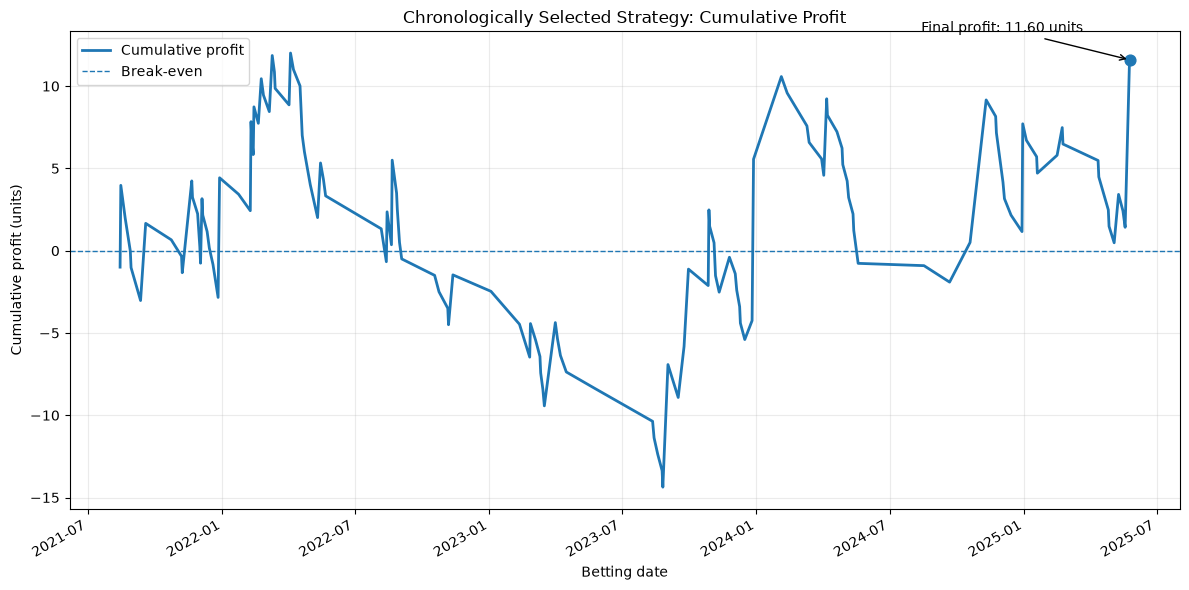

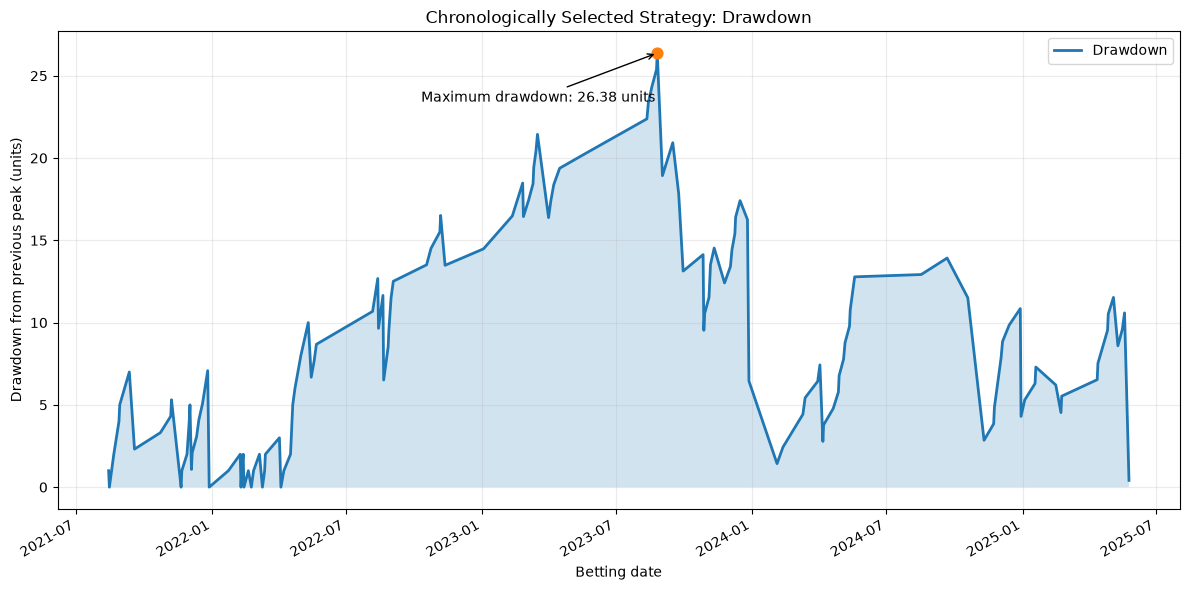

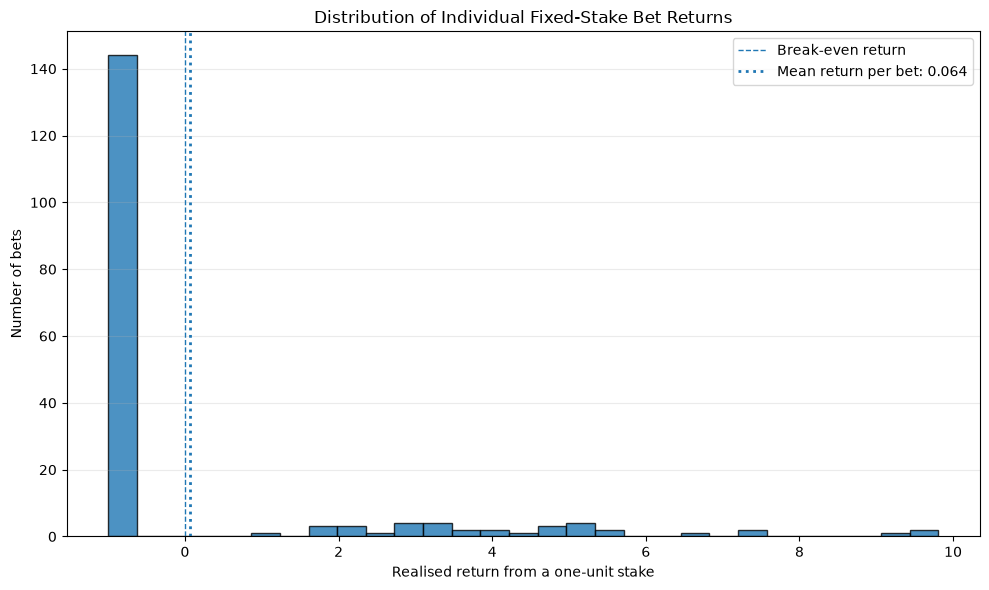

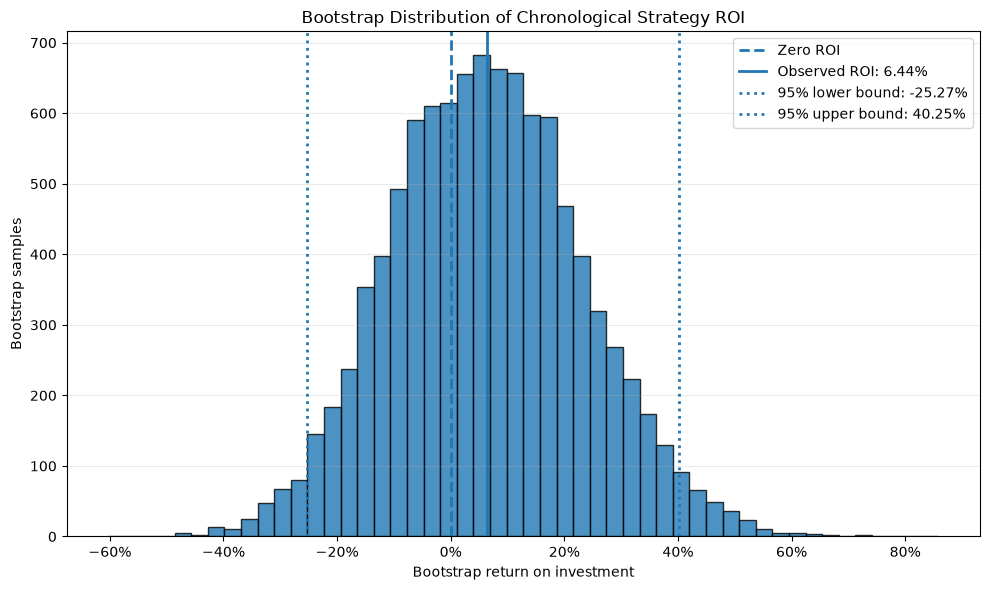

Strategy visual diagnostics completed successfully.
Charts produced: 4
Final cumulative profit: 11.60 units
Maximum drawdown: 26.38 units


C:\Users\kiera\AppData\Local\Temp\ipykernel_1972\2262077779.py:623: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  strategy_visual_diagnostics_summary.round(6)


,Bets,BettingDates,WinningBets,FinalProfitUnits,ObservedROI,MaximumDrawdownUnits,DrawdownPeakDate,MaximumDrawdownDate,Bootstrap95LowerROI,Bootstrap95UpperROI,BootstrapProbabilityPositiveROI
0,180,141,36,11.6,0.064444,26.38,2022-04-04,2023-08-26,-0.252728,0.40249,0.6347


In [10]:
# ============================================================
# 11. Strategy Performance Visual Diagnostics
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


# ------------------------------------------------------------
# Prepare the chronologically selected betting sample
# ------------------------------------------------------------

strategy_visual_data = (
    chronologically_selected_bets
    .copy()
)


strategy_visual_data[
    "Date"
] = pd.to_datetime(
    strategy_visual_data[
        "Date"
    ],
    errors="raise",
).dt.normalize()


strategy_visual_data = (
    strategy_visual_data
    .sort_values(
        by=[
            "Date",
            "HomeTeam",
            "AwayTeam",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


assert len(
    strategy_visual_data
) == 180, (
    "Expected 180 chronologically selected bets."
)


assert strategy_visual_data[
    "RealisedUnitReturn"
].notna().all(), (
    "Missing realised returns were detected."
)


# ------------------------------------------------------------
# Aggregate bets by date
# ------------------------------------------------------------

strategy_daily_performance = (
    strategy_visual_data
    .groupby(
        "Date",
        as_index=False,
    )
    .agg(
        Bets=(
            "RealisedUnitReturn",
            "size",
        ),
        WinningBets=(
            "OutcomeOccurred",
            "sum",
        ),
        DailyProfit=(
            "RealisedUnitReturn",
            "sum",
        ),
    )
    .sort_values(
        by="Date",
        kind="mergesort",
    )
    .reset_index(drop=True)
)


strategy_daily_performance[
    "CumulativeProfit"
] = (
    strategy_daily_performance[
        "DailyProfit"
    ].cumsum()
)


strategy_daily_performance[
    "RunningProfitPeak"
] = (
    strategy_daily_performance[
        "CumulativeProfit"
    ]
    .cummax()
    .clip(
        lower=0.0
    )
)


strategy_daily_performance[
    "Drawdown"
] = (
    strategy_daily_performance[
        "RunningProfitPeak"
    ]
    -
    strategy_daily_performance[
        "CumulativeProfit"
    ]
)


# ------------------------------------------------------------
# Calculate headline visual statistics
# ------------------------------------------------------------

visual_total_profit = float(
    strategy_daily_performance[
        "CumulativeProfit"
    ].iloc[-1]
)


visual_maximum_drawdown = float(
    strategy_daily_performance[
        "Drawdown"
    ].max()
)


maximum_drawdown_position = (
    strategy_daily_performance[
        "Drawdown"
    ].idxmax()
)


maximum_drawdown_date = (
    strategy_daily_performance.loc[
        maximum_drawdown_position,
        "Date",
    ]
)


maximum_drawdown_start_date = (
    strategy_daily_performance.loc[
        :maximum_drawdown_position,
        "CumulativeProfit",
    ]
    .idxmax()
)


maximum_drawdown_peak_date = (
    strategy_daily_performance.loc[
        maximum_drawdown_start_date,
        "Date",
    ]
)


assert np.isclose(
    visual_total_profit,
    11.60,
    atol=1e-8,
), (
    "The visual cumulative-profit calculation does not "
    "match the earlier 11.60-unit result."
)


assert np.isclose(
    visual_maximum_drawdown,
    26.38,
    atol=1e-8,
), (
    "The visual drawdown calculation does not match "
    "the earlier 26.38-unit result."
)


# ------------------------------------------------------------
# Figure 1: cumulative-profit equity curve
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)


ax.plot(
    strategy_daily_performance[
        "Date"
    ],
    strategy_daily_performance[
        "CumulativeProfit"
    ],
    linewidth=2,
    label="Cumulative profit",
)


ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    label="Break-even",
)


ax.scatter(
    strategy_daily_performance[
        "Date"
    ].iloc[-1],
    strategy_daily_performance[
        "CumulativeProfit"
    ].iloc[-1],
    s=60,
    zorder=3,
)


ax.annotate(
    (
        f"Final profit: "
        f"{visual_total_profit:.2f} units"
    ),
    xy=(
        strategy_daily_performance[
            "Date"
        ].iloc[-1],
        strategy_daily_performance[
            "CumulativeProfit"
        ].iloc[-1],
    ),
    xytext=(-150, 20),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
    },
)


ax.set_title(
    "Chronologically Selected Strategy: Cumulative Profit"
)

ax.set_xlabel(
    "Betting date"
)

ax.set_ylabel(
    "Cumulative profit (units)"
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.autofmt_xdate()

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Figure 2: drawdown through time
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)


ax.plot(
    strategy_daily_performance[
        "Date"
    ],
    strategy_daily_performance[
        "Drawdown"
    ],
    linewidth=2,
    label="Drawdown",
)


ax.fill_between(
    strategy_daily_performance[
        "Date"
    ],
    0,
    strategy_daily_performance[
        "Drawdown"
    ],
    alpha=0.2,
)


ax.scatter(
    maximum_drawdown_date,
    visual_maximum_drawdown,
    s=60,
    zorder=3,
)


ax.annotate(
    (
        f"Maximum drawdown: "
        f"{visual_maximum_drawdown:.2f} units"
    ),
    xy=(
        maximum_drawdown_date,
        visual_maximum_drawdown,
    ),
    xytext=(-170, -35),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
    },
)


ax.set_title(
    "Chronologically Selected Strategy: Drawdown"
)

ax.set_xlabel(
    "Betting date"
)

ax.set_ylabel(
    "Drawdown from previous peak (units)"
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.autofmt_xdate()

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Figure 3: distribution of individual bet returns
# ------------------------------------------------------------

individual_bet_returns = (
    strategy_visual_data[
        "RealisedUnitReturn"
    ]
    .to_numpy(
        dtype=float
    )
)


return_histogram_bins = np.linspace(
    individual_bet_returns.min(),
    individual_bet_returns.max(),
    30,
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.hist(
    individual_bet_returns,
    bins=return_histogram_bins,
    edgecolor="black",
    alpha=0.8,
)


ax.axvline(
    x=0,
    linestyle="--",
    linewidth=1,
    label="Break-even return",
)


ax.axvline(
    x=individual_bet_returns.mean(),
    linestyle=":",
    linewidth=2,
    label=(
        "Mean return per bet: "
        f"{individual_bet_returns.mean():.3f}"
    ),
)


ax.set_title(
    "Distribution of Individual Fixed-Stake Bet Returns"
)

ax.set_xlabel(
    "Realised return from a one-unit stake"
)

ax.set_ylabel(
    "Number of bets"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Figure 4: bootstrap ROI distribution and confidence interval
# ------------------------------------------------------------

bootstrap_roi_values = (
    chronological_bootstrap_distribution[
        "BootstrapROI"
    ]
    .to_numpy(
        dtype=float
    )
)


assert len(
    bootstrap_roi_values
) == 10_000, (
    "Expected 10,000 chronological bootstrap ROI values."
)


assert np.isfinite(
    bootstrap_roi_values
).all(), (
    "Non-finite bootstrap ROI values were detected."
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.hist(
    bootstrap_roi_values,
    bins=50,
    edgecolor="black",
    alpha=0.8,
)


ax.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    label="Zero ROI",
)


ax.axvline(
    x=observed_chronological_roi,
    linestyle="-",
    linewidth=2,
    label=(
        "Observed ROI: "
        f"{observed_chronological_roi:.2%}"
    ),
)


ax.axvline(
    x=chronological_bootstrap_lower,
    linestyle=":",
    linewidth=2,
    label=(
        "95% lower bound: "
        f"{chronological_bootstrap_lower:.2%}"
    ),
)


ax.axvline(
    x=chronological_bootstrap_upper,
    linestyle=":",
    linewidth=2,
    label=(
        "95% upper bound: "
        f"{chronological_bootstrap_upper:.2%}"
    ),
)


ax.set_title(
    "Bootstrap Distribution of Chronological Strategy ROI"
)

ax.set_xlabel(
    "Bootstrap return on investment"
)

ax.set_ylabel(
    "Bootstrap samples"
)

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(
        xmax=1.0
    )
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Create the visual-diagnostics summary
# ------------------------------------------------------------

strategy_visual_diagnostics_summary = pd.DataFrame(
    [
        {
            "Bets": len(
                strategy_visual_data
            ),
            "BettingDates": len(
                strategy_daily_performance
            ),
            "WinningBets": int(
                strategy_visual_data[
                    "OutcomeOccurred"
                ].sum()
            ),
            "FinalProfitUnits": (
                visual_total_profit
            ),
            "ObservedROI": (
                observed_chronological_roi
            ),
            "MaximumDrawdownUnits": (
                visual_maximum_drawdown
            ),
            "DrawdownPeakDate": (
                maximum_drawdown_peak_date
            ),
            "MaximumDrawdownDate": (
                maximum_drawdown_date
            ),
            "Bootstrap95LowerROI": (
                chronological_bootstrap_lower
            ),
            "Bootstrap95UpperROI": (
                chronological_bootstrap_upper
            ),
            "BootstrapProbabilityPositiveROI": float(
                np.mean(
                    bootstrap_roi_values
                    >
                    0
                )
            ),
        }
    ]
)


print(
    "Strategy visual diagnostics completed successfully."
)

print(
    "Charts produced: 4"
)

print(
    "Final cumulative profit:",
    f"{visual_total_profit:.2f} units",
)

print(
    "Maximum drawdown:",
    f"{visual_maximum_drawdown:.2f} units",
)

display(
    strategy_visual_diagnostics_summary.round(6)
)

### Results and Interpretation

The visual diagnostics show that the positive aggregate return was accompanied by substantial volatility.

The cumulative-profit curve finished at:

$$
11.60\text{ units},
$$

corresponding to an observed ROI of:

$$
6.44\%.
$$

However, the profit did not accumulate smoothly. The strategy experienced several extended losing periods, including a major decline during 2022–23 before recovering across the later evaluation seasons.

The maximum drawdown was:

$$
26.38\text{ units}.
$$

This was approximately:

$$
\frac{26.38}{11.60}
\approx
2.27
$$

times the final net profit. An investor following the strategy would therefore have needed to tolerate a drawdown substantially larger than the eventual gain.

The individual bet-return distribution was strongly right-skewed. Of the 180 selected bets:

- 144 lost one unit;
- 36 produced positive returns;
- the small number of high-odds winners generated the strategy's aggregate profit.

This is typical of a longshot-oriented betting strategy. Most bets lose, while occasional larger wins determine overall performance.

The bootstrap ROI distribution further illustrates the uncertainty surrounding the historical result. Although the observed ROI was positive, the 95% bootstrap interval was:

$$
[-25.27\%,\ 40.25\%].
$$

A substantial proportion of bootstrap samples produced negative returns, while some produced very large positive returns.

The visual evidence therefore supports the earlier statistical conclusion:

> The strategy generated a positive historical return, but its equity curve, drawdown and bootstrap distribution demonstrate that the result is volatile and not statistically reliable.

The next analysis examines whether the profit is distributed across outcomes, seasons and odds ranges, or depends disproportionately on a small number of successful longshot bets.

## 12. Strategy Composition and Profit Concentration

The chronologically selected strategy produced a positive aggregate return, but high-odds betting strategies can depend heavily on a small number of successful bets.

This section decomposes the 180 selected bets by:

- selected outcome;
- decimal-odds range;
- evaluation season;
- model-implied probability and expected return;
- contribution from the largest winning bets.

The analysis also calculates leave-one-season-out performance. Each evaluation season is removed in turn and ROI is recalculated using the remaining seasons.

A more credible strategy would ideally demonstrate:

1. profits across several outcomes or odds groups;
2. limited dependence on one evaluation season;
3. limited dependence on a small number of extreme winners;
4. some relationship between the size of the estimated edge and realised return.

The analysis does not alter the betting rule. It measures how concentrated and fragile the previously observed profit is.

In [11]:
# ============================================================
# 12. Strategy Composition and Profit Concentration
# ============================================================


# ------------------------------------------------------------
# Prepare the chronological strategy sample
# ------------------------------------------------------------

chronological_strategy_analysis = (
    chronologically_selected_bets
    .copy()
    .sort_values(
        by=[
            "Date",
            "HomeTeam",
            "AwayTeam",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


assert len(
    chronological_strategy_analysis
) == 180, (
    "Expected 180 chronologically selected bets."
)


assert chronological_strategy_analysis[
    "RealisedUnitReturn"
].notna().all(), (
    "Missing realised betting returns were detected."
)


# ------------------------------------------------------------
# Define decimal-odds ranges
# ------------------------------------------------------------

ODDS_BAND_EDGES = [
    1.0,
    3.0,
    5.0,
    8.0,
    12.0,
    20.0,
    np.inf,
]


ODDS_BAND_LABELS = [
    "1.00 to 2.99",
    "3.00 to 4.99",
    "5.00 to 7.99",
    "8.00 to 11.99",
    "12.00 to 19.99",
    "20.00 and above",
]


chronological_strategy_analysis[
    "OddsBand"
] = pd.cut(
    chronological_strategy_analysis[
        "DecimalOdds"
    ],
    bins=ODDS_BAND_EDGES,
    labels=ODDS_BAND_LABELS,
    right=False,
    include_lowest=True,
)


assert chronological_strategy_analysis[
    "OddsBand"
].notna().all(), (
    "At least one bet could not be assigned "
    "to an odds band."
)


# ------------------------------------------------------------
# Reusable grouped strategy-summary function
# ------------------------------------------------------------

def summarise_betting_group(
    betting_data,
    grouping_columns,
):
    """
    Summarise fixed-stake betting performance by one or
    more grouping columns.
    """

    summary = (
        betting_data
        .groupby(
            grouping_columns,
            as_index=False,
            observed=True,
            sort=False,
        )
        .agg(
            Bets=(
                "RealisedUnitReturn",
                "size",
            ),
            WinningBets=(
                "OutcomeOccurred",
                "sum",
            ),
            AverageOdds=(
                "DecimalOdds",
                "mean",
            ),
            MedianOdds=(
                "DecimalOdds",
                "median",
            ),
            MeanModelProbability=(
                "ModelProbability",
                "mean",
            ),
            MeanMarketProbability=(
                "MarketProbability",
                "mean",
            ),
            MeanProbabilityEdge=(
                "ProbabilityEdge",
                "mean",
            ),
            MeanModelExpectedReturn=(
                "ModelExpectedReturn",
                "mean",
            ),
            TotalProfit=(
                "RealisedUnitReturn",
                "sum",
            ),
        )
    )

    summary[
        "HitRate"
    ] = (
        summary[
            "WinningBets"
        ]
        /
        summary[
            "Bets"
        ]
    )

    summary[
        "ROI"
    ] = (
        summary[
            "TotalProfit"
        ]
        /
        summary[
            "Bets"
        ]
    )

    return summary


# ------------------------------------------------------------
# Performance by selected outcome
# ------------------------------------------------------------

chronological_outcome_summary = (
    summarise_betting_group(
        betting_data=(
            chronological_strategy_analysis
        ),
        grouping_columns=[
            "Outcome",
        ],
    )
    .sort_values(
        by="Outcome",
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Performance by decimal-odds range
# ------------------------------------------------------------

chronological_odds_band_summary = (
    summarise_betting_group(
        betting_data=(
            chronological_strategy_analysis
        ),
        grouping_columns=[
            "OddsBand",
        ],
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Performance by evaluation season
# ------------------------------------------------------------

chronological_season_summary = (
    summarise_betting_group(
        betting_data=(
            chronological_strategy_analysis
        ),
        grouping_columns=[
            "Season",
        ],
    )
    .sort_values(
        by="Season",
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Leave-one-season-out sensitivity
# ------------------------------------------------------------

leave_one_season_out_records = []


for omitted_season in (
    strategy_selection_evaluation_seasons
):

    remaining_bets = (
        chronological_strategy_analysis.loc[
            chronological_strategy_analysis[
                "Season"
            ].ne(
                omitted_season
            )
        ]
    )

    remaining_bet_count = len(
        remaining_bets
    )

    remaining_profit = float(
        remaining_bets[
            "RealisedUnitReturn"
        ].sum()
    )

    leave_one_season_out_records.append(
        {
            "OmittedSeason": omitted_season,
            "RemainingSeasons": int(
                remaining_bets[
                    "Season"
                ].nunique()
            ),
            "RemainingBets": (
                remaining_bet_count
            ),
            "RemainingWinningBets": int(
                remaining_bets[
                    "OutcomeOccurred"
                ].sum()
            ),
            "RemainingProfit": (
                remaining_profit
            ),
            "RemainingROI": (
                remaining_profit
                /
                remaining_bet_count
            ),
        }
    )


chronological_leave_one_season_out = (
    pd.DataFrame(
        leave_one_season_out_records
    )
)


# ------------------------------------------------------------
# Measure concentration among the largest winning bets
# ------------------------------------------------------------

chronological_winning_bets = (
    chronological_strategy_analysis.loc[
        chronological_strategy_analysis[
            "OutcomeOccurred"
        ].eq(1)
    ]
    .sort_values(
        by="RealisedUnitReturn",
        ascending=False,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


assert len(
    chronological_winning_bets
) == 36, (
    "Expected 36 winning chronological bets."
)


observed_total_profit = float(
    chronological_strategy_analysis[
        "RealisedUnitReturn"
    ].sum()
)


profit_concentration_records = []


for top_winner_count in [
    1,
    3,
    5,
    10,
]:

    top_winner_profit = float(
        chronological_winning_bets
        .head(
            top_winner_count
        )
        [
            "RealisedUnitReturn"
        ]
        .sum()
    )

    remaining_bet_count = (
        len(
            chronological_strategy_analysis
        )
        -
        top_winner_count
    )

    profit_without_top_winners = (
        observed_total_profit
        -
        top_winner_profit
    )

    profit_concentration_records.append(
        {
            "TopWinningBetsRemoved": (
                top_winner_count
            ),
            "ProfitFromTopWinningBets": (
                top_winner_profit
            ),
            "TopWinnerProfitAsPercentOfNetProfit": (
                100
                *
                top_winner_profit
                /
                observed_total_profit
            ),
            "RemainingBets": (
                remaining_bet_count
            ),
            "ProfitWithoutTopWinningBets": (
                profit_without_top_winners
            ),
            "ROIWithoutTopWinningBets": (
                profit_without_top_winners
                /
                remaining_bet_count
            ),
        }
    )


chronological_profit_concentration = (
    pd.DataFrame(
        profit_concentration_records
    )
)


# ------------------------------------------------------------
# Identify the largest winning bets
# ------------------------------------------------------------

largest_chronological_winners = (
    chronological_winning_bets[
        comparison_fixture_keys
        + [
            "ActualOutcome",
            "Outcome",
            "ModelProbability",
            "MarketProbability",
            "ProbabilityEdge",
            "DecimalOdds",
            "ModelExpectedReturn",
            "RealisedUnitReturn",
        ]
    ]
    .head(10)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Examine whether larger estimated returns performed better
# ------------------------------------------------------------

EXPECTED_RETURN_BAND_EDGES = [
    0.50,
    0.60,
    0.75,
    1.00,
    1.50,
    np.inf,
]


EXPECTED_RETURN_BAND_LABELS = [
    "50% to 59.99%",
    "60% to 74.99%",
    "75% to 99.99%",
    "100% to 149.99%",
    "150% and above",
]


chronological_strategy_analysis[
    "ExpectedReturnBand"
] = pd.cut(
    chronological_strategy_analysis[
        "ModelExpectedReturn"
    ],
    bins=EXPECTED_RETURN_BAND_EDGES,
    labels=EXPECTED_RETURN_BAND_LABELS,
    right=False,
    include_lowest=True,
)


assert chronological_strategy_analysis[
    "ExpectedReturnBand"
].notna().all(), (
    "At least one chronological bet could not be assigned "
    "to an expected-return band."
)


chronological_expected_return_band_summary = (
    summarise_betting_group(
        betting_data=(
            chronological_strategy_analysis
        ),
        grouping_columns=[
            "ExpectedReturnBand",
        ],
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Validate the decompositions
# ------------------------------------------------------------

assert chronological_outcome_summary[
    "Bets"
].sum() == 180, (
    "Outcome-level bet counts do not reconcile."
)


assert chronological_odds_band_summary[
    "Bets"
].sum() == 180, (
    "Odds-band bet counts do not reconcile."
)


assert chronological_season_summary[
    "Bets"
].sum() == 180, (
    "Season-level bet counts do not reconcile."
)


assert chronological_expected_return_band_summary[
    "Bets"
].sum() == 180, (
    "Expected-return-band bet counts do not reconcile."
)


assert np.isclose(
    chronological_outcome_summary[
        "TotalProfit"
    ].sum(),
    observed_total_profit,
    atol=1e-12,
), (
    "Outcome-level profit does not reconcile."
)


assert np.isclose(
    chronological_odds_band_summary[
        "TotalProfit"
    ].sum(),
    observed_total_profit,
    atol=1e-12,
), (
    "Odds-band profit does not reconcile."
)


assert np.isclose(
    chronological_season_summary[
        "TotalProfit"
    ].sum(),
    observed_total_profit,
    atol=1e-12,
), (
    "Season-level profit does not reconcile."
)


assert np.isclose(
    chronological_expected_return_band_summary[
        "TotalProfit"
    ].sum(),
    observed_total_profit,
    atol=1e-12,
), (
    "Expected-return-band profit does not reconcile."
)


# ------------------------------------------------------------
# Display the results
# ------------------------------------------------------------

print(
    "Chronological strategy composition "
    "analysis completed successfully."
)

print(
    "Chronological bets:",
    len(
        chronological_strategy_analysis
    ),
)

print(
    "Chronological net profit:",
    f"{observed_total_profit:.2f} units",
)

print(
    "Winning bets:",
    len(
        chronological_winning_bets
    ),
)

print(
    "Performance by selected outcome:"
)

display(
    chronological_outcome_summary.round(6)
)

print(
    "Performance by decimal-odds range:"
)

display(
    chronological_odds_band_summary.round(6)
)

print(
    "Performance by model-implied expected-return range:"
)

display(
    chronological_expected_return_band_summary.round(6)
)

print(
    "Performance by evaluation season:"
)

display(
    chronological_season_summary.round(6)
)

print(
    "Leave-one-season-out sensitivity:"
)

display(
    chronological_leave_one_season_out.round(6)
)

print(
    "Dependence on the largest winning bets:"
)

display(
    chronological_profit_concentration.round(6)
)

print(
    "Ten largest winning bets:"
)

display(
    largest_chronological_winners.round(6)
)

Chronological strategy composition analysis completed successfully.
Chronological bets: 180
Chronological net profit: 11.60 units
Winning bets: 36
Performance by selected outcome:


,Outcome,Bets,WinningBets,AverageOdds,MedianOdds,MeanModelProbability,MeanMarketProbability,MeanProbabilityEdge,MeanModelExpectedReturn,TotalProfit,HitRate,ROI
0,A,111,21,7.986577,5.90,0.299983,0.168308,0.131675,0.791619,7.71,0.189189,0.069459
1,H,69,15,6.272029,5.08,0.344871,0.201251,0.143619,0.719741,3.89,0.217391,0.056377


Performance by decimal-odds range:


,OddsBand,Bets,WinningBets,AverageOdds,MedianOdds,MeanModelProbability,MeanMarketProbability,MeanProbabilityEdge,MeanModelExpectedReturn,TotalProfit,HitRate,ROI
0,8.00 to 11.99,33,5,9.822424,9.88,0.199463,0.100236,0.099227,0.925833,15.55,0.151515,0.471212
1,5.00 to 7.99,52,11,6.065385,5.99,0.286956,0.163113,0.123843,0.711186,15.31,0.211538,0.294423
2,3.00 to 4.99,60,16,3.953000,3.90,0.433460,0.252633,0.180828,0.682936,5.28,0.266667,0.088000
3,12.00 to 19.99,18,0,14.794444,14.50,0.129397,0.066662,0.062735,0.864394,-18.00,0.000000,-1.000000
4,20.00 and above,6,0,24.583333,22.25,0.091522,0.041137,0.050385,1.201725,-6.00,0.000000,-1.000000
5,1.00 to 2.99,11,4,2.614545,2.73,0.609475,0.379464,0.230011,0.568369,-0.54,0.363636,-0.049091


Performance by model-implied expected-return range:


...

Dependence on the largest winning bets:


,TopWinningBetsRemoved,ProfitFromTopWinningBets,TopWinnerProfitAsPercentOfNetProfit,RemainingBets,ProfitWithoutTopWinningBets,ROIWithoutTopWinningBets
0,1,9.81,84.568966,179,1.79,0.010000
1,3,28.83,248.534483,177,-17.23,-0.097345
2,5,43.55,375.431034,175,-31.95,-0.182571
3,10,71.29,614.568966,170,-59.69,-0.351118


Ten largest winning bets:


C:\Users\kiera\AppData\Local\Temp\ipykernel_1972\4069623069.py:640: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  largest_chronological_winners.round(6)


,Season,Date,HomeTeam,AwayTeam,ActualOutcome,Outcome,ModelProbability,MarketProbability,ProbabilityEdge,DecimalOdds,ModelExpectedReturn,RealisedUnitReturn
0,2023-24,2023-12-28,Arsenal,West Ham,A,A,0.142450,0.089647,0.052803,10.81,0.539884,9.81
1,2024-25,2024-11-10,Tottenham,Ipswich,A,A,0.143268,0.090525,0.052743,10.66,0.527236,9.66
2,2024-25,2025-05-25,Newcastle,Everton,A,A,0.222423,0.092873,0.129550,10.36,1.304305,9.36
3,2023-24,2023-09-02,Chelsea,Nott'm Forest,A,A,0.229476,0.115214,0.114262,8.45,0.939071,7.45
4,2021-22,2021-12-28,Leicester,Liverpool,H,H,0.319081,0.117021,0.202060,8.27,1.638800,7.27
5,2024-25,2024-12-30,Ipswich,Chelsea,H,H,0.229607,0.127832,0.101776,7.55,0.733535,6.55
6,2021-22,2021-11-20,Watford,Man United,H,H,0.229789,0.147984,0.081806,6.58,0.512014,5.58
7,2021-22,2022-02-09,Tottenham,Southampton,A,A,0.253201,0.151884,0.101317,6.41,0.623017,5.41
8,2022-23,2022-08-21,Leeds,Chelsea,H,H,0.247672,0.159048,0.088624,6.14,0.520703,5.14
9,2022-23,2023-04-01,Chelsea,Aston Villa,A,A,0.253583,0.161305,0.092278,6.06,0.536710,5.06


### Results and Interpretation

The composition analysis shows that the positive aggregate return was highly concentrated.

The strategy selected only home and away wins:

| Selected outcome | Bets | Profit | ROI |
|---|---:|---:|---:|
| Away win | 111 | 7.71 units | 6.95% |
| Home win | 69 | 3.89 units | 5.64% |

No draw bets satisfied the chronologically selected 50% expected-return threshold.

Both selected outcomes produced positive aggregate returns, although neither subgroup contained enough independent evidence to establish a persistent advantage.

Performance differed substantially across decimal-odds ranges.

The strongest historical results were produced between decimal odds of 3.00 and 11.99. In particular, the 8.00–11.99 group produced:

$$
\operatorname{ROI}_{8.00\text{--}11.99}
=
47.12\%.
$$

However, all 24 bets priced at decimal odds of 12 or greater lost. The most extreme longshot selections therefore produced:

$$
-24\text{ units}.
$$

This demonstrates that larger odds did not automatically correspond to greater genuine value.

There was also no monotonic relationship between the model's estimated expected return and realised ROI.

For example:

- the 50%–59.99% group produced ROI of 30.97%;
- the 60%–74.99% group produced ROI of −24.28%;
- the 75%–99.99% group produced ROI of 16.19%;
- the 100%–149.99% group produced ROI of −13.79%.

The model's estimated expected-return ranking therefore did not consistently rank bets by their realised profitability.

Seasonal performance remained unstable:

| Evaluation season | Profit | ROI |
|---|---:|---:|
| 2021–22 | 3.33 units | 5.46% |
| 2022–23 | −11.70 units | −33.43% |
| 2023–24 | 7.60 units | 16.17% |
| 2024–25 | 12.37 units | 33.43% |

The leave-one-season-out analysis showed that removing 2024–25 reduced the remaining strategy result to approximately:

$$
-0.54\%.
$$

The positive aggregate result was therefore dependent partly on the strong final evaluation season.

Profit was even more concentrated among individual winning bets.

The largest winning bet produced 9.81 units, representing approximately:

$$
84.57\%
$$

of the strategy's final net profit.

After removing the three largest winners, the remaining strategy produced:

$$
-17.23\text{ units},
$$

with ROI of approximately:

$$
-9.73\%.
$$

Removing the five largest winners reduced profit to:

$$
-31.95\text{ units}.
$$

The appropriate conclusion is:

> The strategy's positive aggregate return was generated by a small number of successful bets within particular odds ranges and seasons. It was not broadly distributed across the betting sample, and larger model-implied expected returns did not consistently produce better realised results.

This concentration substantially weakens the evidence that the historical profit represents a persistent betting advantage. Any probability-based staking experiment must therefore use strict fractional sizing and stake caps.

## 13. Flat Staking versus Fractional Kelly Sizing

The previous sections evaluated every selected bet using a fixed one-unit stake.

This section investigates how probability-based position sizing would have changed the strategy's bankroll, profit and drawdown.

For a bet with decimal odds $O$ and model probability $p$, define:

$$
b = O-1,
\qquad
q = 1-p.
$$

The full Kelly fraction is:

$$
f^*
=
\frac{bp-q}{b}
=
\frac{pO-1}{O-1}.
$$

The experiment compares three staking methods:

1. **Flat staking:** one unit per bet;
2. **Quarter Kelly:** $0.25f^*$;
3. **Half Kelly:** $0.50f^*$.

Because the model substantially overstated expected returns, unrestricted Kelly sizing would be unsafe. The following risk controls are therefore specified before examining the results:

| Strategy | Maximum stake per bet | Maximum total exposure per date |
|---|---:|---:|
| Quarter Kelly | 2% of opening bankroll | 10% of opening bankroll |
| Half Kelly | 4% of opening bankroll | 20% of opening bankroll |

All bets played on the same date are sized using the bankroll available at the start of that date. This prevents an arbitrary ordering of matches played on the same day from affecting the results.

When the combined desired stakes exceed the daily exposure limit, all stakes on that date are reduced proportionally.

For a stake $s$, the realised profit is:

$$
\Pi =
\begin{cases}
s(O-1), & \text{if the bet wins},\\
-s, & \text{if the bet loses}.
\end{cases}
$$

The comparison reports:

- final bankroll;
- net profit;
- profit relative to total amount staked;
- return relative to the initial bankroll;
- maximum drawdown;
- average and maximum stake;
- frequency with which the risk caps were binding.

This is a risk-sizing experiment rather than evidence that Kelly staking should be used in practice. Kelly sizing is only optimal when the supplied probabilities are accurate, which has not been established for this model.

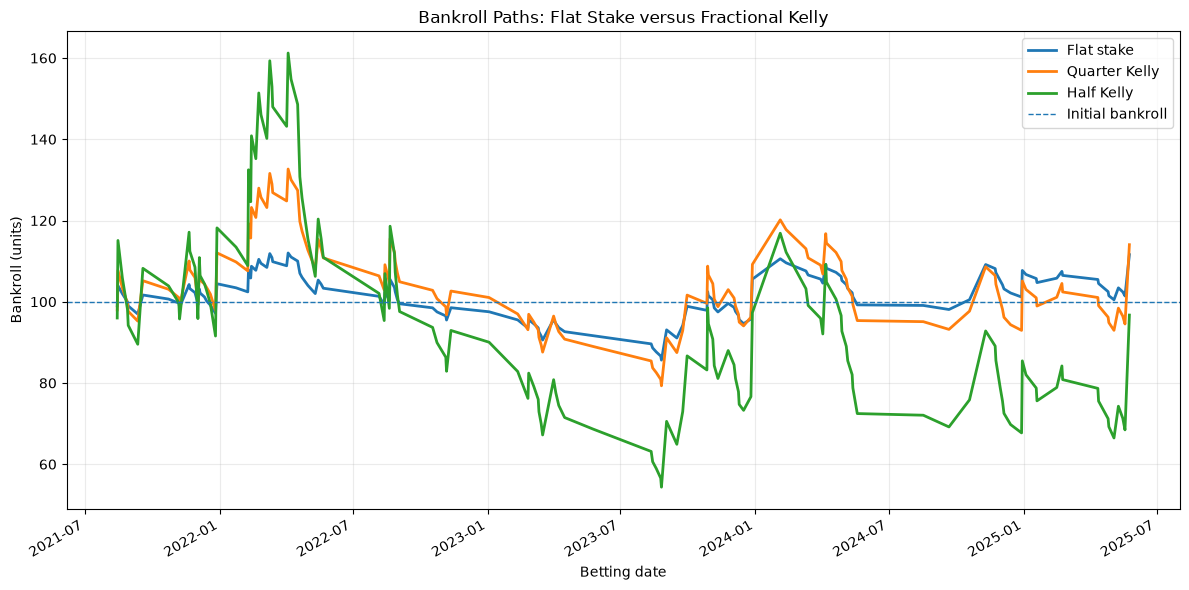

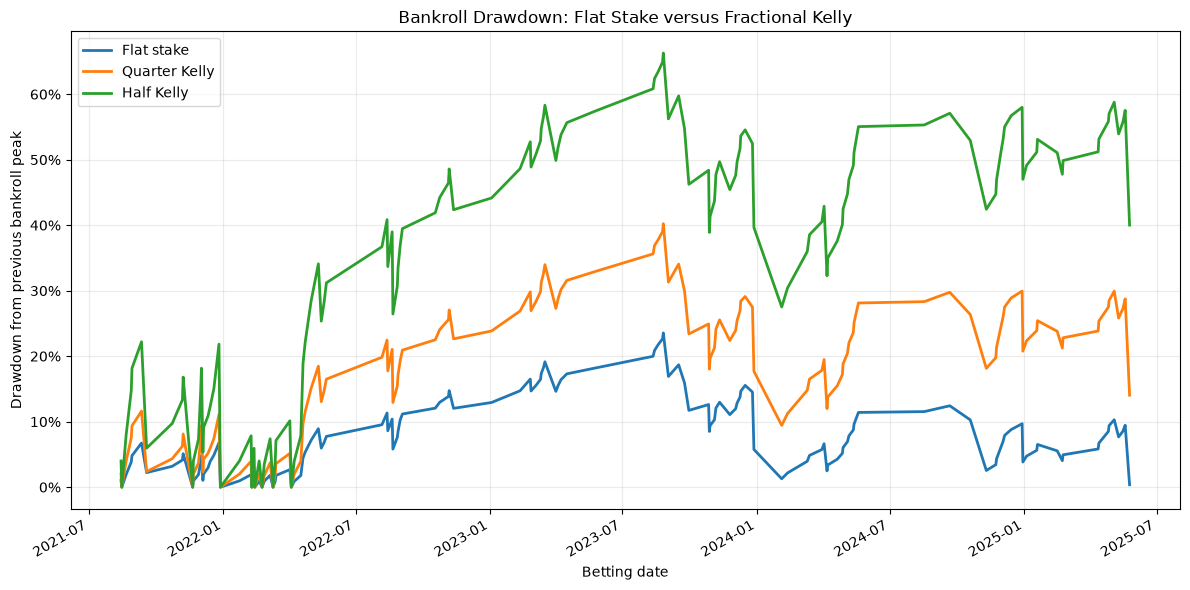

Fractional Kelly staking experiment completed successfully.
Initial bankroll: 100.00 units
Chronological bets per strategy: 180


,StrategyNumber,Strategy,KellyMultiplier,MaximumPerBetFraction,MaximumDailyExposureFraction
0,1,Flat stake,NaN,NaN,NaN
1,2,Quarter Kelly,0.25,0.02,0.1
2,3,Half Kelly,0.50,0.04,0.2


,StrategyNumber,Strategy,InitialBankroll,FinalBankroll,NetProfit,TotalStaked,BettingROI,BankrollReturn,AverageStake,MaximumStake,MaximumDailyExposureFraction,MinimumBankroll,MaximumDrawdownUnits,MaximumDrawdownPercentage,PerBetCapBindingPercentage,DailyCapBindingPercentage
0,1,Flat stake,100.0,111.600000,11.600000,180.000000,0.064444,0.116000,1.000000,1.000000,0.049300,85.630000,26.38000,0.235515,NaN,NaN
1,2,Quarter Kelly,100.0,114.044232,14.044232,353.393128,0.039741,0.140442,1.963295,2.653496,0.097144,79.307787,53.36702,0.402239,0.816667,0.0
2,3,Half Kelly,100.0,96.719852,-3.280148,647.128991,-0.005069,-0.032801,3.595161,6.449187,0.194287,54.353801,106.87587,0.662880,0.816667,0.0


In [12]:
# ============================================================
# 13. Flat Staking versus Fractional Kelly Sizing
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


# ------------------------------------------------------------
# Experiment settings
# ------------------------------------------------------------

INITIAL_BANKROLL = 100.0


staking_strategy_specifications = [
    {
        "StrategyNumber": 1,
        "Strategy": "Flat stake",
        "KellyMultiplier": np.nan,
        "MaximumPerBetFraction": np.nan,
        "MaximumDailyExposureFraction": np.nan,
    },
    {
        "StrategyNumber": 2,
        "Strategy": "Quarter Kelly",
        "KellyMultiplier": 0.25,
        "MaximumPerBetFraction": 0.02,
        "MaximumDailyExposureFraction": 0.10,
    },
    {
        "StrategyNumber": 3,
        "Strategy": "Half Kelly",
        "KellyMultiplier": 0.50,
        "MaximumPerBetFraction": 0.04,
        "MaximumDailyExposureFraction": 0.20,
    },
]


staking_strategy_configuration = pd.DataFrame(
    staking_strategy_specifications
)


# ------------------------------------------------------------
# Prepare the chronological betting sample
# ------------------------------------------------------------

kelly_analysis_data = (
    chronologically_selected_bets
    .copy()
)


kelly_analysis_data[
    "Date"
] = pd.to_datetime(
    kelly_analysis_data[
        "Date"
    ],
    errors="raise",
).dt.normalize()


kelly_analysis_data = (
    kelly_analysis_data
    .sort_values(
        by=[
            "Date",
            "HomeTeam",
            "AwayTeam",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


assert len(
    kelly_analysis_data
) == 180, (
    "Expected 180 chronologically selected bets."
)


assert (
    kelly_analysis_data[
        "DecimalOdds"
    ]
    >
    1
).all(), (
    "Kelly sizing requires decimal odds greater than one."
)


assert (
    kelly_analysis_data[
        "ModelProbability"
    ]
    .between(
        0,
        1,
        inclusive="both",
    )
).all(), (
    "Invalid model probabilities were detected."
)


# ------------------------------------------------------------
# Calculate full Kelly fractions
# ------------------------------------------------------------

kelly_analysis_data[
    "FullKellyFraction"
] = (
    (
        kelly_analysis_data[
            "ModelProbability"
        ]
        *
        kelly_analysis_data[
            "DecimalOdds"
        ]
        -
        1
    )
    /
    (
        kelly_analysis_data[
            "DecimalOdds"
        ]
        -
        1
    )
).clip(
    lower=0.0
)


assert np.isfinite(
    kelly_analysis_data[
        "FullKellyFraction"
    ]
).all(), (
    "Non-finite Kelly fractions were produced."
)


assert (
    kelly_analysis_data[
        "FullKellyFraction"
    ]
    >
    0
).all(), (
    "The chronologically selected sample should contain "
    "positive model-implied Kelly fractions."
)


# ------------------------------------------------------------
# Simulate one staking strategy
# ------------------------------------------------------------

def simulate_staking_strategy(
    betting_data,
    strategy_specification,
    initial_bankroll,
):
    """
    Simulate a staking method chronologically.

    All bets played on the same date are sized using the
    bankroll available at the start of that date.
    """

    strategy_number = int(
        strategy_specification[
            "StrategyNumber"
        ]
    )

    strategy_name = str(
        strategy_specification[
            "Strategy"
        ]
    )

    kelly_multiplier = (
        strategy_specification[
            "KellyMultiplier"
        ]
    )

    maximum_per_bet_fraction = (
        strategy_specification[
            "MaximumPerBetFraction"
        ]
    )

    maximum_daily_exposure_fraction = (
        strategy_specification[
            "MaximumDailyExposureFraction"
        ]
    )

    current_bankroll = float(
        initial_bankroll
    )

    strategy_bet_records = []
    strategy_daily_records = []

    for betting_date, date_bets in betting_data.groupby(
        "Date",
        sort=True,
    ):

        date_bets = (
            date_bets
            .sort_values(
                by=[
                    "HomeTeam",
                    "AwayTeam",
                ],
                kind="mergesort",
            )
            .reset_index(drop=True)
        )

        opening_bankroll = float(
            current_bankroll
        )

        number_of_date_bets = len(
            date_bets
        )

        if strategy_name == "Flat stake":

            raw_kelly_fractions = np.full(
                number_of_date_bets,
                np.nan,
                dtype=float,
            )

            pre_cap_stake_fractions = np.full(
                number_of_date_bets,
                np.nan,
                dtype=float,
            )

            capped_stake_fractions = np.full(
                number_of_date_bets,
                np.nan,
                dtype=float,
            )

            nominal_stakes = np.ones(
                number_of_date_bets,
                dtype=float,
            )

            daily_exposure_scale = 1.0

            per_bet_cap_binding = np.zeros(
                number_of_date_bets,
                dtype=bool,
            )

            daily_cap_binding = False

            assert nominal_stakes.sum() <= opening_bankroll, (
                "The flat-stake strategy attempted to stake "
                "more than its available bankroll."
            )

        else:

            raw_kelly_fractions = (
                date_bets[
                    "FullKellyFraction"
                ]
                .to_numpy(
                    dtype=float
                )
                *
                float(
                    kelly_multiplier
                )
            )

            pre_cap_stake_fractions = (
                raw_kelly_fractions.copy()
            )

            capped_stake_fractions = np.minimum(
                pre_cap_stake_fractions,
                float(
                    maximum_per_bet_fraction
                ),
            )

            per_bet_cap_binding = (
                pre_cap_stake_fractions
                >
                float(
                    maximum_per_bet_fraction
                )
            )

            nominal_stakes = (
                opening_bankroll
                *
                capped_stake_fractions
            )

            nominal_daily_exposure = float(
                nominal_stakes.sum()
            )

            maximum_daily_exposure = (
                opening_bankroll
                *
                float(
                    maximum_daily_exposure_fraction
                )
            )

            if (
                nominal_daily_exposure
                >
                maximum_daily_exposure
                and
                nominal_daily_exposure
                >
                0
            ):

                daily_exposure_scale = (
                    maximum_daily_exposure
                    /
                    nominal_daily_exposure
                )

                daily_cap_binding = True

            else:

                daily_exposure_scale = 1.0
                daily_cap_binding = False

        applied_stakes = (
            nominal_stakes
            *
            daily_exposure_scale
        )

        applied_stake_fractions = (
            applied_stakes
            /
            opening_bankroll
        )

        realised_unit_returns = (
            date_bets[
                "RealisedUnitReturn"
            ]
            .to_numpy(
                dtype=float
            )
        )

        realised_profits = (
            applied_stakes
            *
            realised_unit_returns
        )

        daily_staked = float(
            applied_stakes.sum()
        )

        daily_profit = float(
            realised_profits.sum()
        )

        closing_bankroll = (
            opening_bankroll
            +
            daily_profit
        )

        assert closing_bankroll > 0, (
            f"{strategy_name} exhausted its bankroll "
            f"on {betting_date.date()}."
        )

        if strategy_name != "Flat stake":

            assert (
                applied_stake_fractions
                <=
                float(
                    maximum_per_bet_fraction
                )
                +
                1e-12
            ).all(), (
                "A Kelly stake exceeded its per-bet cap."
            )

            assert (
                daily_staked
                <=
                opening_bankroll
                *
                float(
                    maximum_daily_exposure_fraction
                )
                +
                1e-10
            ), (
                "Daily Kelly exposure exceeded its cap."
            )

        for bet_position, bet_row in date_bets.iterrows():

            strategy_bet_records.append(
                {
                    "StrategyNumber": strategy_number,
                    "Strategy": strategy_name,
                    "Date": betting_date,
                    "Season": bet_row[
                        "Season"
                    ],
                    "HomeTeam": bet_row[
                        "HomeTeam"
                    ],
                    "AwayTeam": bet_row[
                        "AwayTeam"
                    ],
                    "Outcome": bet_row[
                        "Outcome"
                    ],
                    "ActualOutcome": bet_row[
                        "ActualOutcome"
                    ],
                    "DecimalOdds": float(
                        bet_row[
                            "DecimalOdds"
                        ]
                    ),
                    "ModelProbability": float(
                        bet_row[
                            "ModelProbability"
                        ]
                    ),
                    "FullKellyFraction": float(
                        bet_row[
                            "FullKellyFraction"
                        ]
                    ),
                    "FractionalKellyBeforeCap": (
                        float(
                            pre_cap_stake_fractions[
                                bet_position
                            ]
                        )
                        if strategy_name != "Flat stake"
                        else np.nan
                    ),
                    "FractionalKellyAfterPerBetCap": (
                        float(
                            capped_stake_fractions[
                                bet_position
                            ]
                        )
                        if strategy_name != "Flat stake"
                        else np.nan
                    ),
                    "DailyExposureScale": float(
                        daily_exposure_scale
                    ),
                    "AppliedStakeFraction": float(
                        applied_stake_fractions[
                            bet_position
                        ]
                    ),
                    "OpeningBankroll": (
                        opening_bankroll
                    ),
                    "Stake": float(
                        applied_stakes[
                            bet_position
                        ]
                    ),
                    "OutcomeOccurred": int(
                        bet_row[
                            "OutcomeOccurred"
                        ]
                    ),
                    "RealisedUnitReturn": float(
                        bet_row[
                            "RealisedUnitReturn"
                        ]
                    ),
                    "RealisedProfit": float(
                        realised_profits[
                            bet_position
                        ]
                    ),
                    "PerBetCapBinding": bool(
                        per_bet_cap_binding[
                            bet_position
                        ]
                    ),
                    "DailyCapBinding": bool(
                        daily_cap_binding
                    ),
                }
            )

        strategy_daily_records.append(
            {
                "StrategyNumber": strategy_number,
                "Strategy": strategy_name,
                "Date": betting_date,
                "OpeningBankroll": (
                    opening_bankroll
                ),
                "Bets": number_of_date_bets,
                "WinningBets": int(
                    date_bets[
                        "OutcomeOccurred"
                    ].sum()
                ),
                "DailyStaked": (
                    daily_staked
                ),
                "DailyExposureFraction": (
                    daily_staked
                    /
                    opening_bankroll
                ),
                "DailyProfit": (
                    daily_profit
                ),
                "ClosingBankroll": (
                    closing_bankroll
                ),
                "DailyExposureScale": float(
                    daily_exposure_scale
                ),
                "DailyCapBinding": bool(
                    daily_cap_binding
                ),
            }
        )

        current_bankroll = float(
            closing_bankroll
        )

    return (
        pd.DataFrame(
            strategy_bet_records
        ),
        pd.DataFrame(
            strategy_daily_records
        ),
    )


# ------------------------------------------------------------
# Run all three staking strategies
# ------------------------------------------------------------

staking_bet_frames = []
staking_daily_frames = []


for strategy_specification in (
    staking_strategy_specifications
):

    strategy_bets, strategy_daily = (
        simulate_staking_strategy(
            betting_data=kelly_analysis_data,
            strategy_specification=(
                strategy_specification
            ),
            initial_bankroll=INITIAL_BANKROLL,
        )
    )

    staking_bet_frames.append(
        strategy_bets
    )

    staking_daily_frames.append(
        strategy_daily
    )


kelly_staking_bets = pd.concat(
    staking_bet_frames,
    ignore_index=True,
)


kelly_staking_daily_performance = pd.concat(
    staking_daily_frames,
    ignore_index=True,
)


# ------------------------------------------------------------
# Calculate bankroll peaks and drawdowns
# ------------------------------------------------------------

drawdown_daily_frames = []


for strategy_name, strategy_daily in (
    kelly_staking_daily_performance.groupby(
        "Strategy",
        sort=False,
    )
):

    strategy_daily = (
        strategy_daily
        .sort_values(
            by="Date",
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    bankroll_path = np.concatenate(
        [
            np.array(
                [
                    INITIAL_BANKROLL
                ]
            ),
            strategy_daily[
                "ClosingBankroll"
            ].to_numpy(
                dtype=float
            ),
        ]
    )

    running_peak_path = np.maximum.accumulate(
        bankroll_path
    )

    drawdown_unit_path = (
        running_peak_path
        -
        bankroll_path
    )

    drawdown_percentage_path = np.divide(
        drawdown_unit_path,
        running_peak_path,
        out=np.zeros_like(
            drawdown_unit_path
        ),
        where=(
            running_peak_path
            >
            0
        ),
    )

    strategy_daily[
        "RunningBankrollPeak"
    ] = running_peak_path[1:]

    strategy_daily[
        "DrawdownUnits"
    ] = drawdown_unit_path[1:]

    strategy_daily[
        "DrawdownPercentage"
    ] = drawdown_percentage_path[1:]

    drawdown_daily_frames.append(
        strategy_daily
    )


kelly_staking_daily_performance = pd.concat(
    drawdown_daily_frames,
    ignore_index=True,
)


# ------------------------------------------------------------
# Produce the strategy comparison summary
# ------------------------------------------------------------

staking_summary_records = []


for strategy_specification in (
    staking_strategy_specifications
):

    strategy_number = int(
        strategy_specification[
            "StrategyNumber"
        ]
    )

    strategy_name = str(
        strategy_specification[
            "Strategy"
        ]
    )

    strategy_bets = (
        kelly_staking_bets.loc[
            kelly_staking_bets[
                "StrategyNumber"
            ].eq(
                strategy_number
            )
        ]
    )

    strategy_daily = (
        kelly_staking_daily_performance.loc[
            kelly_staking_daily_performance[
                "StrategyNumber"
            ].eq(
                strategy_number
            )
        ]
        .sort_values(
            by="Date",
            kind="mergesort",
        )
    )

    ending_bankroll = float(
        strategy_daily[
            "ClosingBankroll"
        ].iloc[-1]
    )

    total_staked = float(
        strategy_bets[
            "Stake"
        ].sum()
    )

    net_profit = float(
        strategy_bets[
            "RealisedProfit"
        ].sum()
    )

    staking_summary_records.append(
        {
            "StrategyNumber": strategy_number,
            "Strategy": strategy_name,
            "InitialBankroll": (
                INITIAL_BANKROLL
            ),
            "FinalBankroll": (
                ending_bankroll
            ),
            "NetProfit": (
                net_profit
            ),
            "TotalStaked": (
                total_staked
            ),
            "BettingROI": (
                net_profit
                /
                total_staked
            ),
            "BankrollReturn": (
                net_profit
                /
                INITIAL_BANKROLL
            ),
            "AverageStake": float(
                strategy_bets[
                    "Stake"
                ].mean()
            ),
            "MedianStake": float(
                strategy_bets[
                    "Stake"
                ].median()
            ),
            "MaximumStake": float(
                strategy_bets[
                    "Stake"
                ].max()
            ),
            "AverageAppliedStakeFraction": float(
                strategy_bets[
                    "AppliedStakeFraction"
                ].mean()
            ),
            "MaximumAppliedStakeFraction": float(
                strategy_bets[
                    "AppliedStakeFraction"
                ].max()
            ),
            "MaximumDailyExposureFraction": float(
                strategy_daily[
                    "DailyExposureFraction"
                ].max()
            ),
            "MinimumBankroll": float(
                strategy_daily[
                    "ClosingBankroll"
                ].min()
            ),
            "MaximumDrawdownUnits": float(
                strategy_daily[
                    "DrawdownUnits"
                ].max()
            ),
            "MaximumDrawdownPercentage": float(
                strategy_daily[
                    "DrawdownPercentage"
                ].max()
            ),
            "PerBetCapBindingPercentage": (
                float(
                    strategy_bets[
                        "PerBetCapBinding"
                    ].mean()
                )
                if strategy_name != "Flat stake"
                else np.nan
            ),
            "DailyCapBindingPercentage": (
                float(
                    strategy_daily[
                        "DailyCapBinding"
                    ].mean()
                )
                if strategy_name != "Flat stake"
                else np.nan
            ),
            "ProfitableDays": int(
                (
                    strategy_daily[
                        "DailyProfit"
                    ]
                    >
                    0
                ).sum()
            ),
            "LosingDays": int(
                (
                    strategy_daily[
                        "DailyProfit"
                    ]
                    <
                    0
                ).sum()
            ),
        }
    )


kelly_staking_summary = (
    pd.DataFrame(
        staking_summary_records
    )
    .sort_values(
        by="StrategyNumber",
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Validate the simulation
# ------------------------------------------------------------

assert len(
    kelly_staking_bets
) == (
    180
    *
    len(
        staking_strategy_specifications
    )
), (
    "Unexpected number of strategy-bet records."
)


assert (
    kelly_staking_daily_performance[
        "ClosingBankroll"
    ]
    >
    0
).all(), (
    "At least one strategy exhausted its bankroll."
)


flat_stake_result = (
    kelly_staking_summary.loc[
        kelly_staking_summary[
            "Strategy"
        ].eq(
            "Flat stake"
        )
    ]
    .iloc[0]
)


assert np.isclose(
    flat_stake_result[
        "TotalStaked"
    ],
    180.0,
    atol=1e-10,
), (
    "The flat strategy should stake exactly 180 units."
)


assert np.isclose(
    flat_stake_result[
        "NetProfit"
    ],
    11.60,
    atol=1e-8,
), (
    "The flat strategy does not reproduce the earlier "
    "11.60-unit profit."
)


assert np.isclose(
    flat_stake_result[
        "FinalBankroll"
    ],
    111.60,
    atol=1e-8,
), (
    "The flat strategy should finish with "
    "111.60 bankroll units."
)


for strategy_number in [
    2,
    3,
]:

    strategy_specification = (
        staking_strategy_configuration.loc[
            staking_strategy_configuration[
                "StrategyNumber"
            ].eq(
                strategy_number
            )
        ]
        .iloc[0]
    )

    strategy_bets = (
        kelly_staking_bets.loc[
            kelly_staking_bets[
                "StrategyNumber"
            ].eq(
                strategy_number
            )
        ]
    )

    strategy_daily = (
        kelly_staking_daily_performance.loc[
            kelly_staking_daily_performance[
                "StrategyNumber"
            ].eq(
                strategy_number
            )
        ]
    )

    assert (
        strategy_bets[
            "AppliedStakeFraction"
        ]
        <=
        strategy_specification[
            "MaximumPerBetFraction"
        ]
        +
        1e-12
    ).all(), (
        "A fractional Kelly stake exceeded "
        "its configured per-bet cap."
    )

    assert (
        strategy_daily[
            "DailyExposureFraction"
        ]
        <=
        strategy_specification[
            "MaximumDailyExposureFraction"
        ]
        +
        1e-12
    ).all(), (
        "A fractional Kelly strategy exceeded "
        "its configured daily exposure cap."
    )


# ------------------------------------------------------------
# Figure 1: bankroll paths
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)


for strategy_name, strategy_daily in (
    kelly_staking_daily_performance.groupby(
        "Strategy",
        sort=False,
    )
):

    strategy_daily = (
        strategy_daily
        .sort_values(
            by="Date",
            kind="mergesort",
        )
    )

    ax.plot(
        strategy_daily[
            "Date"
        ],
        strategy_daily[
            "ClosingBankroll"
        ],
        linewidth=2,
        label=strategy_name,
    )


ax.axhline(
    y=INITIAL_BANKROLL,
    linestyle="--",
    linewidth=1,
    label="Initial bankroll",
)


ax.set_title(
    "Bankroll Paths: Flat Stake versus Fractional Kelly"
)

ax.set_xlabel(
    "Betting date"
)

ax.set_ylabel(
    "Bankroll (units)"
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.autofmt_xdate()

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Figure 2: percentage drawdown paths
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)


for strategy_name, strategy_daily in (
    kelly_staking_daily_performance.groupby(
        "Strategy",
        sort=False,
    )
):

    strategy_daily = (
        strategy_daily
        .sort_values(
            by="Date",
            kind="mergesort",
        )
    )

    ax.plot(
        strategy_daily[
            "Date"
        ],
        strategy_daily[
            "DrawdownPercentage"
        ],
        linewidth=2,
        label=strategy_name,
    )


ax.set_title(
    "Bankroll Drawdown: Flat Stake versus Fractional Kelly"
)

ax.set_xlabel(
    "Betting date"
)

ax.set_ylabel(
    "Drawdown from previous bankroll peak"
)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(
        xmax=1.0
    )
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.autofmt_xdate()

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print(
    "Fractional Kelly staking experiment "
    "completed successfully."
)

print(
    "Initial bankroll:",
    f"{INITIAL_BANKROLL:.2f} units",
)

print(
    "Chronological bets per strategy:",
    len(
        kelly_analysis_data
    ),
)

display(
    staking_strategy_configuration.round(6)
)

display(
    kelly_staking_summary[
        [
            "StrategyNumber",
            "Strategy",
            "InitialBankroll",
            "FinalBankroll",
            "NetProfit",
            "TotalStaked",
            "BettingROI",
            "BankrollReturn",
            "AverageStake",
            "MaximumStake",
            "MaximumDailyExposureFraction",
            "MinimumBankroll",
            "MaximumDrawdownUnits",
            "MaximumDrawdownPercentage",
            "PerBetCapBindingPercentage",
            "DailyCapBindingPercentage",
        ]
    ].round(6)
)

### Results and Interpretation

The staking experiment shows that increasing exposure according to the model's estimated probability advantage did not produce a proportionate improvement in performance.

The flat-stake strategy reproduced the earlier result:

$$
\text{Final bankroll}
=
111.60,
$$

with net profit of:

$$
11.60\text{ units},
$$

and betting ROI of:

$$
6.44\%.
$$

Its maximum bankroll drawdown was:

$$
26.38\text{ units},
$$

equivalent to approximately:

$$
23.55\%
$$

of the previous bankroll peak.

Quarter Kelly produced the highest final bankroll:

$$
114.04,
$$

representing net profit of:

$$
14.04\text{ units}.
$$

However, it staked a total of approximately:

$$
353.39\text{ units},
$$

and therefore generated betting ROI of only:

$$
3.97\%.
$$

The additional profit relative to flat staking was:

$$
14.04-11.60
=
2.44\text{ units}.
$$

This small improvement was accompanied by maximum drawdown of:

$$
53.37\text{ units},
$$

or approximately:

$$
40.22\%.
$$

Quarter Kelly therefore produced slightly more final profit, but its maximum drawdown was more than twice that of flat staking.

Half Kelly performed substantially worse. It finished with a bankroll of approximately:

$$
96.72,
$$

representing a loss of:

$$
-3.28\text{ units}.
$$

Its betting ROI was approximately:

$$
-0.51\%,
$$

while maximum drawdown reached:

$$
106.88\text{ units},
$$

or approximately:

$$
66.29\%.
$$

The bankroll curve shows that Half Kelly initially amplified the effect of several successful high-odds bets. However, it also amplified the later losing sequence and ultimately erased the early gains.

The per-bet stake cap was binding for approximately:

$$
81.67\%
$$

of the Quarter-Kelly and Half-Kelly bets. This corresponds to approximately 147 of the 180 selections.

This is important because it indicates that the model-implied Kelly stakes were usually larger than the predetermined safety limits. The model's estimated probability advantages were therefore sufficiently aggressive that uncapped Kelly staking would have produced much greater exposure.

The daily exposure cap was never binding. The individual per-bet cap was consequently the principal risk control preventing extreme position sizes.

The appropriate conclusion is:

> Fractional Kelly staking amplified both gains and losses. Quarter Kelly produced slightly greater final profit than flat staking, but only by accepting substantially larger drawdown and exposure. Half Kelly produced a loss and severe bankroll volatility. Given the uncertainty and concentration already identified in the model's betting advantage, flat staking provided the strongest risk-return trade-off among the tested methods.

These results should not be interpreted as evidence that Quarter Kelly is superior. Its higher final bankroll depended on the same small number of successful bets identified in the profit-concentration analysis, while the model probabilities were not sufficiently reliable to support aggressive Kelly sizing.

## 14. Closing-Line Value and Price-Timing Validation

Closing-line value measures whether a bettor obtained a better price than the market's final closing price.

The existing betting strategy was constructed using Pinnacle closing odds:

$$
O^{\text{close}}
=
(\text{PSCH},\text{PSCD},\text{PSCA}).
$$

These prices cannot be used to calculate genuine closing-line value because the entry price and comparison price would be identical.

The dataset also contains the standard Pinnacle columns:

$$
O^{\text{earlier}}
=
(\text{PSH},\text{PSD},\text{PSA}).
$$

Before treating these as actionable earlier prices, this section verifies their availability and numerical relationship with the closing columns.

For decimal odds, price-based closing-line value is defined as:

$$
\operatorname{CLV}_{O}
=
\frac{O^{\text{earlier}}}
     {O^{\text{close}}}
-1.
$$

A positive value means the earlier price was larger than the closing price and would therefore have offered a better potential payout.

Because bookmaker odds contain a margin, the corresponding no-vig probability for outcome $j$ is:

$$
p_j^{\text{NV}}
=
\frac{1/O_j}
{\sum_{k\in\{H,D,A\}}1/O_k}.
$$

Probability-based closing-line movement is:

$$
\operatorname{CLV}_{p}
=
p_j^{\text{close,NV}}
-
p_j^{\text{earlier,NV}}.
$$

A positive value means the market increased its estimated probability of the selected outcome before closing.

This initial inspection does not yet place bets or select a strategy. It establishes whether the earlier and closing price pairs are suitable for a chronological CLV backtest.

In [13]:
# ============================================================
# 14. Verify Earlier and Closing Pinnacle Prices
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Required Pinnacle odds columns
# ------------------------------------------------------------

PINNACLE_EARLIER_ODDS_COLUMNS = [
    "PSH",
    "PSD",
    "PSA",
]


PINNACLE_CLOSING_ODDS_COLUMNS = [
    "PSCH",
    "PSCD",
    "PSCA",
]


PINNACLE_REQUIRED_ODDS_COLUMNS = (
    PINNACLE_EARLIER_ODDS_COLUMNS
    +
    PINNACLE_CLOSING_ODDS_COLUMNS
)


# ------------------------------------------------------------
# Locate the raw bookmaker DataFrame already loaded
# in the notebook
# ------------------------------------------------------------

candidate_bookmaker_frames = []


preferred_name_terms = [
    "bookmaker",
    "combined",
    "historical",
    "raw",
    "market",
    "odds",
]


for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    if not set(
        PINNACLE_REQUIRED_ODDS_COLUMNS
    ).issubset(
        object_value.columns
    ):
        continue

    preferred_name_score = sum(
        term in object_name.lower()
        for term in preferred_name_terms
    )

    candidate_bookmaker_frames.append(
        {
            "ObjectName": object_name,
            "Rows": len(
                object_value
            ),
            "Columns": len(
                object_value.columns
            ),
            "PreferredNameScore": (
                preferred_name_score
            ),
            "DataFrame": object_value,
        }
    )


assert candidate_bookmaker_frames, (
    "No loaded DataFrame contains all six Pinnacle "
    "columns: PSH, PSD, PSA, PSCH, PSCD and PSCA."
)


candidate_bookmaker_frames = sorted(
    candidate_bookmaker_frames,
    key=lambda candidate: (
        candidate[
            "PreferredNameScore"
        ],
        candidate[
            "Rows"
        ],
        candidate[
            "Columns"
        ],
    ),
    reverse=True,
)


selected_bookmaker_candidate = (
    candidate_bookmaker_frames[0]
)


pinnacle_price_source_name = (
    selected_bookmaker_candidate[
        "ObjectName"
    ]
)


pinnacle_price_source = (
    selected_bookmaker_candidate[
        "DataFrame"
    ]
    .copy()
)


# ------------------------------------------------------------
# Resolve the fixture-identification columns
# ------------------------------------------------------------

COLUMN_ALIASES = {
    "Season": [
        "Season",
        "season",
    ],
    "Date": [
        "Date",
        "date",
        "MatchDate",
    ],
    "HomeTeam": [
        "HomeTeam",
        "home_team",
        "Home",
    ],
    "AwayTeam": [
        "AwayTeam",
        "away_team",
        "Away",
    ],
}


resolved_fixture_columns = {}


for standard_name, possible_names in (
    COLUMN_ALIASES.items()
):

    matching_names = [
        possible_name
        for possible_name in possible_names
        if possible_name
        in pinnacle_price_source.columns
    ]

    assert matching_names, (
        f"Could not identify the {standard_name} column "
        "in the bookmaker source DataFrame."
    )

    resolved_fixture_columns[
        standard_name
    ] = matching_names[0]


pinnacle_price_source = (
    pinnacle_price_source
    .rename(
        columns={
            original_name: standard_name
            for standard_name, original_name
            in resolved_fixture_columns.items()
            if original_name != standard_name
        }
    )
)


PINNACLE_FIXTURE_KEYS = [
    "Season",
    "Date",
    "HomeTeam",
    "AwayTeam",
]


# ------------------------------------------------------------
# Parse dates safely
# ------------------------------------------------------------

if pd.api.types.is_datetime64_any_dtype(
    pinnacle_price_source[
        "Date"
    ]
):

    pinnacle_price_source[
        "Date"
    ] = pd.to_datetime(
        pinnacle_price_source[
            "Date"
        ],
        errors="coerce",
    ).dt.normalize()

else:

    pinnacle_price_source[
        "Date"
    ] = pd.to_datetime(
        pinnacle_price_source[
            "Date"
        ],
        errors="coerce",
        dayfirst=True,
        format="mixed",
    ).dt.normalize()


# ------------------------------------------------------------
# Convert odds columns to numeric
# ------------------------------------------------------------

for odds_column in (
    PINNACLE_REQUIRED_ODDS_COLUMNS
):

    pinnacle_price_source[
        odds_column
    ] = pd.to_numeric(
        pinnacle_price_source[
            odds_column
        ],
        errors="coerce",
    )

    # Decimal odds must be greater than one.
    pinnacle_price_source.loc[
        pinnacle_price_source[
            odds_column
        ]
        <=
        1,
        odds_column,
    ] = np.nan


# ------------------------------------------------------------
# Identify complete earlier and closing markets
# ------------------------------------------------------------

pinnacle_price_source[
    "EarlierMarketComplete"
] = (
    pinnacle_price_source[
        PINNACLE_EARLIER_ODDS_COLUMNS
    ]
    .notna()
    .all(
        axis=1
    )
)


pinnacle_price_source[
    "ClosingMarketComplete"
] = (
    pinnacle_price_source[
        PINNACLE_CLOSING_ODDS_COLUMNS
    ]
    .notna()
    .all(
        axis=1
    )
)


pinnacle_price_source[
    "PairedMarketsComplete"
] = (
    pinnacle_price_source[
        "EarlierMarketComplete"
    ]
    &
    pinnacle_price_source[
        "ClosingMarketComplete"
    ]
)


# ------------------------------------------------------------
# Coverage by season
# ------------------------------------------------------------

pinnacle_price_coverage_by_season = (
    pinnacle_price_source
    .groupby(
        "Season",
        as_index=False,
        sort=True,
    )
    .agg(
        Fixtures=(
            "Season",
            "size",
        ),
        EarlierMarketsComplete=(
            "EarlierMarketComplete",
            "sum",
        ),
        ClosingMarketsComplete=(
            "ClosingMarketComplete",
            "sum",
        ),
        PairedMarketsComplete=(
            "PairedMarketsComplete",
            "sum",
        ),
    )
)


pinnacle_price_coverage_by_season[
    "PairedMarketCoverage"
] = (
    pinnacle_price_coverage_by_season[
        "PairedMarketsComplete"
    ]
    /
    pinnacle_price_coverage_by_season[
        "Fixtures"
    ]
)


# ------------------------------------------------------------
# Restrict the detailed analysis to paired markets
# ------------------------------------------------------------

pinnacle_paired_prices = (
    pinnacle_price_source.loc[
        pinnacle_price_source[
            "PairedMarketsComplete"
        ]
    ]
    [
        PINNACLE_FIXTURE_KEYS
        +
        PINNACLE_REQUIRED_ODDS_COLUMNS
    ]
    .dropna(
        subset=PINNACLE_FIXTURE_KEYS
    )
    .drop_duplicates(
        subset=PINNACLE_FIXTURE_KEYS,
        keep="last",
    )
    .sort_values(
        by=PINNACLE_FIXTURE_KEYS,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


assert len(
    pinnacle_paired_prices
) > 0, (
    "No fixtures contain complete earlier and closing "
    "Pinnacle markets."
)


assert pinnacle_paired_prices[
    PINNACLE_REQUIRED_ODDS_COLUMNS
].notna().all().all(), (
    "Missing odds remain in the paired-price sample."
)


assert (
    pinnacle_paired_prices[
        PINNACLE_REQUIRED_ODDS_COLUMNS
    ]
    >
    1
).all().all(), (
    "Invalid decimal odds remain in the paired sample."
)


# ------------------------------------------------------------
# Calculate bookmaker overround
# ------------------------------------------------------------

pinnacle_paired_prices[
    "EarlierOverround"
] = (
    1
    /
    pinnacle_paired_prices[
        "PSH"
    ]
    +
    1
    /
    pinnacle_paired_prices[
        "PSD"
    ]
    +
    1
    /
    pinnacle_paired_prices[
        "PSA"
    ]
)


pinnacle_paired_prices[
    "ClosingOverround"
] = (
    1
    /
    pinnacle_paired_prices[
        "PSCH"
    ]
    +
    1
    /
    pinnacle_paired_prices[
        "PSCD"
    ]
    +
    1
    /
    pinnacle_paired_prices[
        "PSCA"
    ]
)


pinnacle_paired_prices[
    "EarlierMargin"
] = (
    pinnacle_paired_prices[
        "EarlierOverround"
    ]
    -
    1
)


pinnacle_paired_prices[
    "ClosingMargin"
] = (
    pinnacle_paired_prices[
        "ClosingOverround"
    ]
    -
    1
)


# ------------------------------------------------------------
# Calculate no-vig probabilities
# ------------------------------------------------------------

PINNACLE_OUTCOME_COLUMN_MAP = {
    "H": {
        "EarlierOdds": "PSH",
        "ClosingOdds": "PSCH",
    },
    "D": {
        "EarlierOdds": "PSD",
        "ClosingOdds": "PSCD",
    },
    "A": {
        "EarlierOdds": "PSA",
        "ClosingOdds": "PSCA",
    },
}


for outcome, outcome_columns in (
    PINNACLE_OUTCOME_COLUMN_MAP.items()
):

    earlier_odds_column = (
        outcome_columns[
            "EarlierOdds"
        ]
    )

    closing_odds_column = (
        outcome_columns[
            "ClosingOdds"
        ]
    )

    pinnacle_paired_prices[
        f"EarlierNoVigProbability_{outcome}"
    ] = (
        (
            1
            /
            pinnacle_paired_prices[
                earlier_odds_column
            ]
        )
        /
        pinnacle_paired_prices[
            "EarlierOverround"
        ]
    )

    pinnacle_paired_prices[
        f"ClosingNoVigProbability_{outcome}"
    ] = (
        (
            1
            /
            pinnacle_paired_prices[
                closing_odds_column
            ]
        )
        /
        pinnacle_paired_prices[
            "ClosingOverround"
        ]
    )


assert np.allclose(
    pinnacle_paired_prices[
        [
            "EarlierNoVigProbability_H",
            "EarlierNoVigProbability_D",
            "EarlierNoVigProbability_A",
        ]
    ].sum(
        axis=1
    ),
    1.0,
    atol=1e-12,
), (
    "Earlier no-vig probabilities do not sum to one."
)


assert np.allclose(
    pinnacle_paired_prices[
        [
            "ClosingNoVigProbability_H",
            "ClosingNoVigProbability_D",
            "ClosingNoVigProbability_A",
        ]
    ].sum(
        axis=1
    ),
    1.0,
    atol=1e-12,
), (
    "Closing no-vig probabilities do not sum to one."
)


# ------------------------------------------------------------
# Convert the paired markets to outcome-level observations
# ------------------------------------------------------------

pinnacle_price_movement_frames = []


for outcome, outcome_columns in (
    PINNACLE_OUTCOME_COLUMN_MAP.items()
):

    earlier_odds_column = (
        outcome_columns[
            "EarlierOdds"
        ]
    )

    closing_odds_column = (
        outcome_columns[
            "ClosingOdds"
        ]
    )

    outcome_price_data = (
        pinnacle_paired_prices[
            PINNACLE_FIXTURE_KEYS
        ]
        .copy()
    )

    outcome_price_data[
        "Outcome"
    ] = outcome

    outcome_price_data[
        "EarlierOdds"
    ] = pinnacle_paired_prices[
        earlier_odds_column
    ].to_numpy()

    outcome_price_data[
        "ClosingOdds"
    ] = pinnacle_paired_prices[
        closing_odds_column
    ].to_numpy()

    outcome_price_data[
        "EarlierNoVigProbability"
    ] = pinnacle_paired_prices[
        f"EarlierNoVigProbability_{outcome}"
    ].to_numpy()

    outcome_price_data[
        "ClosingNoVigProbability"
    ] = pinnacle_paired_prices[
        f"ClosingNoVigProbability_{outcome}"
    ].to_numpy()

    # Positive when the earlier price was better than close.
    outcome_price_data[
        "OddsCLV"
    ] = (
        outcome_price_data[
            "EarlierOdds"
        ]
        /
        outcome_price_data[
            "ClosingOdds"
        ]
        -
        1
    )

    # Positive when the market increased the outcome probability.
    outcome_price_data[
        "NoVigProbabilityMovement"
    ] = (
        outcome_price_data[
            "ClosingNoVigProbability"
        ]
        -
        outcome_price_data[
            "EarlierNoVigProbability"
        ]
    )

    outcome_price_data[
        "AbsoluteOddsMovement"
    ] = (
        outcome_price_data[
            "ClosingOdds"
        ]
        -
        outcome_price_data[
            "EarlierOdds"
        ]
    ).abs()

    outcome_price_data[
        "PricesIdentical"
    ] = np.isclose(
        outcome_price_data[
            "EarlierOdds"
        ],
        outcome_price_data[
            "ClosingOdds"
        ],
        atol=1e-12,
        rtol=0,
    )

    outcome_price_data[
        "PositiveOddsCLV"
    ] = (
        outcome_price_data[
            "OddsCLV"
        ]
        >
        0
    )

    outcome_price_data[
        "PositiveProbabilityMovement"
    ] = (
        outcome_price_data[
            "NoVigProbabilityMovement"
        ]
        >
        0
    )

    pinnacle_price_movement_frames.append(
        outcome_price_data
    )


pinnacle_price_movements = pd.concat(
    pinnacle_price_movement_frames,
    ignore_index=True,
)


# ------------------------------------------------------------
# Summarise opening-to-closing movement by outcome
# ------------------------------------------------------------

pinnacle_price_movement_summary = (
    pinnacle_price_movements
    .groupby(
        "Outcome",
        as_index=False,
        sort=True,
    )
    .agg(
        OutcomePrices=(
            "Outcome",
            "size",
        ),
        MeanEarlierOdds=(
            "EarlierOdds",
            "mean",
        ),
        MeanClosingOdds=(
            "ClosingOdds",
            "mean",
        ),
        MedianEarlierOdds=(
            "EarlierOdds",
            "median",
        ),
        MedianClosingOdds=(
            "ClosingOdds",
            "median",
        ),
        IdenticalPricePercentage=(
            "PricesIdentical",
            "mean",
        ),
        MeanAbsoluteOddsMovement=(
            "AbsoluteOddsMovement",
            "mean",
        ),
        MedianOddsCLV=(
            "OddsCLV",
            "median",
        ),
        MeanOddsCLV=(
            "OddsCLV",
            "mean",
        ),
        PositiveOddsCLVPercentage=(
            "PositiveOddsCLV",
            "mean",
        ),
        MeanProbabilityMovement=(
            "NoVigProbabilityMovement",
            "mean",
        ),
        PositiveProbabilityMovementPercentage=(
            "PositiveProbabilityMovement",
            "mean",
        ),
    )
)


# ------------------------------------------------------------
# Summarise bookmaker margins
# ------------------------------------------------------------

pinnacle_market_overround_summary = pd.DataFrame(
    [
        {
            "MarketStage": "Earlier Pinnacle",
            "Fixtures": len(
                pinnacle_paired_prices
            ),
            "MeanOverround": float(
                pinnacle_paired_prices[
                    "EarlierOverround"
                ].mean()
            ),
            "MedianOverround": float(
                pinnacle_paired_prices[
                    "EarlierOverround"
                ].median()
            ),
            "MeanMargin": float(
                pinnacle_paired_prices[
                    "EarlierMargin"
                ].mean()
            ),
            "MedianMargin": float(
                pinnacle_paired_prices[
                    "EarlierMargin"
                ].median()
            ),
        },
        {
            "MarketStage": "Pinnacle Closing",
            "Fixtures": len(
                pinnacle_paired_prices
            ),
            "MeanOverround": float(
                pinnacle_paired_prices[
                    "ClosingOverround"
                ].mean()
            ),
            "MedianOverround": float(
                pinnacle_paired_prices[
                    "ClosingOverround"
                ].median()
            ),
            "MeanMargin": float(
                pinnacle_paired_prices[
                    "ClosingMargin"
                ].mean()
            ),
            "MedianMargin": float(
                pinnacle_paired_prices[
                    "ClosingMargin"
                ].median()
            ),
        },
    ]
)


# ------------------------------------------------------------
# Overall diagnostics
# ------------------------------------------------------------

paired_fixture_count = len(
    pinnacle_paired_prices
)


paired_outcome_price_count = len(
    pinnacle_price_movements
)


identical_outcome_price_percentage = float(
    pinnacle_price_movements[
        "PricesIdentical"
    ].mean()
)


non_identical_outcome_price_percentage = (
    1
    -
    identical_outcome_price_percentage
)


complete_triplet_matches = (
    np.isclose(
        pinnacle_paired_prices[
            "PSH"
        ],
        pinnacle_paired_prices[
            "PSCH"
        ],
        atol=1e-12,
        rtol=0,
    )
    &
    np.isclose(
        pinnacle_paired_prices[
            "PSD"
        ],
        pinnacle_paired_prices[
            "PSCD"
        ],
        atol=1e-12,
        rtol=0,
    )
    &
    np.isclose(
        pinnacle_paired_prices[
            "PSA"
        ],
        pinnacle_paired_prices[
            "PSCA"
        ],
        atol=1e-12,
        rtol=0,
    )
)


identical_market_triplet_percentage = float(
    complete_triplet_matches.mean()
)


internal_price_pair_validation_passed = bool(
    paired_fixture_count >= 380
    and
    non_identical_outcome_price_percentage >= 0.50
    and
    pinnacle_price_movements[
        "AbsoluteOddsMovement"
    ].gt(0).any()
)


pinnacle_price_pair_validation_summary = pd.DataFrame(
    [
        {
            "DetectedSourceObject": (
                pinnacle_price_source_name
            ),
            "SourceRows": len(
                pinnacle_price_source
            ),
            "PairedFixtures": (
                paired_fixture_count
            ),
            "PairedOutcomePrices": (
                paired_outcome_price_count
            ),
            "IdenticalOutcomePricePercentage": (
                identical_outcome_price_percentage
            ),
            "NonIdenticalOutcomePricePercentage": (
                non_identical_outcome_price_percentage
            ),
            "IdenticalMarketTripletPercentage": (
                identical_market_triplet_percentage
            ),
            "InternalPricePairValidationPassed": (
                internal_price_pair_validation_passed
            ),
        }
    ]
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print(
    "Pinnacle earlier-versus-closing price "
    "inspection completed successfully."
)

print(
    "Detected source DataFrame:",
    pinnacle_price_source_name,
)

print(
    "Paired fixtures:",
    f"{paired_fixture_count:,}",
)

print(
    "Paired outcome prices:",
    f"{paired_outcome_price_count:,}",
)

print(
    "Non-identical outcome prices:",
    f"{non_identical_outcome_price_percentage:.2%}",
)

print(
    "Internally suitable for the next CLV stage:",
    internal_price_pair_validation_passed,
)


print(
    "\nCoverage by season:"
)

display(
    pinnacle_price_coverage_by_season.round(6)
)


print(
    "\nEarlier-to-closing price movement by outcome:"
)

display(
    pinnacle_price_movement_summary.round(6)
)


print(
    "\nPinnacle market-margin comparison:"
)

display(
    pinnacle_market_overround_summary.round(6)
)


print(
    "\nOverall price-pair validation:"
)

display(
    pinnacle_price_pair_validation_summary.round(6)
)


print(
    "\nExample paired Pinnacle prices:"
)

display(
    pinnacle_paired_prices[
        PINNACLE_FIXTURE_KEYS
        +
        PINNACLE_REQUIRED_ODDS_COLUMNS
        +
        [
            "EarlierMargin",
            "ClosingMargin",
        ]
    ]
    .tail(10)
    .reset_index(drop=True)
    .round(6)
)

Pinnacle earlier-versus-closing price inspection completed successfully.
Detected source DataFrame: historical_market_data
Paired fixtures: 3,800
Paired outcome prices: 11,400
Non-identical outcome prices: 96.89%
Internally suitable for the next CLV stage: True

Coverage by season:


,Season,Fixtures,EarlierMarketsComplete,ClosingMarketsComplete,PairedMarketsComplete,PairedMarketCoverage
0,2015-16,380,380,380,380,1.0
1,2016-17,380,380,380,380,1.0
2,2017-18,380,380,380,380,1.0
3,2018-19,380,380,380,380,1.0
4,2019-20,380,380,380,380,1.0
5,2020-21,380,380,380,380,1.0
6,2021-22,380,380,380,380,1.0
7,2022-23,380,380,380,380,1.0
8,2023-24,380,380,380,380,1.0
9,2024-25,380,380,380,380,1.0



Earlier-to-closing price movement by outcome:


,Outcome,OutcomePrices,MeanEarlierOdds,MeanClosingOdds,MedianEarlierOdds,MedianClosingOdds,IdenticalPricePercentage,MeanAbsoluteOddsMovement,MedianOddsCLV,MeanOddsCLV,PositiveOddsCLVPercentage,MeanProbabilityMovement,PositiveProbabilityMovementPercentage
0,A,3800,4.907253,4.943129,3.40,3.41,0.022105,0.447029,0.000000,0.000602,0.487895,0.000154,0.504474
1,D,3800,4.356974,4.378342,3.83,3.82,0.026053,0.221284,0.002725,0.001587,0.508158,0.000949,0.531579
2,H,3800,3.005547,3.040561,2.29,2.30,0.045263,0.215418,-0.004619,-0.003991,0.444474,-0.001104,0.475000



Pinnacle market-margin comparison:


...


Overall price-pair validation:


,DetectedSourceObject,SourceRows,PairedFixtures,PairedOutcomePrices,IdenticalOutcomePricePercentage,NonIdenticalOutcomePricePercentage,IdenticalMarketTripletPercentage,InternalPricePairValidationPassed
0,historical_market_data,3800,3800,11400,0.03114,0.96886,0.000789,True



Example paired Pinnacle prices:


C:\Users\kiera\AppData\Local\Temp\ipykernel_1972\3415325630.py:1054: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(6)


,Season,Date,HomeTeam,AwayTeam,PSH,PSD,PSA,PSCH,PSCD,PSCA,EarlierMargin,ClosingMargin
0,2024-25,2025-05-25,Bournemouth,Leicester,1.34,5.82,8.37,1.34,5.67,9.01,0.037564,0.033623
1,2024-25,2025-05-25,Fulham,Man City,5.54,4.19,1.62,6.32,4.57,1.52,0.036453,0.034941
2,2024-25,2025-05-25,Ipswich,West Ham,3.02,3.90,2.24,3.28,3.63,2.23,0.033965,0.028791
3,2024-25,2025-05-25,Liverpool,Crystal Palace,1.42,5.68,6.36,1.38,6.04,7.14,0.037514,0.030257
4,2024-25,2025-05-25,Man United,Aston Villa,4.40,4.26,1.74,4.82,4.37,1.68,0.036727,0.031540
5,2024-25,2025-05-25,Newcastle,Everton,1.33,5.85,8.55,1.28,6.19,10.36,0.039779,0.039326
6,2024-25,2025-05-25,Nott'm Forest,Chelsea,3.15,3.76,2.22,3.50,3.87,2.07,0.033868,0.027204
7,2024-25,2025-05-25,Southampton,Arsenal,9.46,5.85,1.30,11.73,6.54,1.25,0.045879,0.038157
8,2024-25,2025-05-25,Tottenham,Brighton,4.33,4.52,1.71,3.83,4.06,1.92,0.036981,0.028235
9,2024-25,2025-05-25,Wolves,Brentford,2.74,3.83,2.45,3.00,3.82,2.31,0.034223,0.028014


### Results and Interpretation

The price-pair inspection found complete earlier and closing Pinnacle markets for all:

$$
3{,}800
$$

fixtures in the historical sample.

This produced:

$$
3{,}800 \times 3
=
11{,}400
$$

paired outcome-price observations.

Coverage was complete for every season from 2015–16 to 2024–25, so no fixtures were removed because of missing Pinnacle price pairs.

Approximately:

$$
96.89\%
$$

of individual outcome prices differed between the earlier and closing snapshots.

Only approximately:

$$
0.08\%
$$

of complete three-outcome markets had identical earlier and closing prices for all three outcomes.

The two sets of columns therefore represent genuinely different market snapshots rather than duplicated prices.

The average Pinnacle market margin declined from approximately:

$$
2.63\%
$$

at the earlier snapshot to:

$$
2.46\%
$$

at closing.

This is consistent with the closing market being marginally more competitive and information-efficient.

Across all available fixtures, earlier-to-closing movements were approximately balanced. Close to half of the prices shortened and close to half lengthened. There was therefore no obvious mechanical tendency for every earlier price to appear better than its closing equivalent.

The appropriate conclusion is:

> The earlier and closing Pinnacle columns have complete historical coverage, contain materially different prices and produce plausible market movements. They are internally suitable for analysing whether model-selected bets obtained positive closing-line value.

The columns `PSH`, `PSD` and `PSA` should be described as **earlier** or **pre-closing** prices rather than guaranteed opening prices because the exact collection timestamp is not available for each individual fixture.

## 15. Pre-Closing Bet Selection and Closing-Line Value

The previous betting experiment selected candidates using Pinnacle closing odds. That is unsuitable for a genuine closing-line-value test because the closing price would not have been available when the bet was placed.

This section reconstructs the strategy using only the earlier Pinnacle prices:

$$
O^{\text{earlier}}
=
(\text{PSH},\text{PSD},\text{PSA}).
$$

For each outcome, the model-implied expected return at the earlier price is:

$$
ER_j^{\text{earlier}}
=
p_j O_j^{\text{earlier}}-1.
$$

For each fixture, the outcome with the highest earlier-price expected return is identified. A bet is placed only when:

$$
\max_j ER_j^{\text{earlier}}
\geq 50\%.
$$

The 50% threshold is frozen before examining closing-line value. Closing prices are not used to choose the fixture, outcome or threshold.

For every selected bet, price-based closing-line value is:

$$
CLV_O
=
\frac{O^{\text{earlier}}}
     {O^{\text{close}}}
-1.
$$

Positive $CLV_O$ means that the strategy obtained a larger decimal price than was available at closing.

The no-vig probability movement is:

$$
CLV_p
=
p^{\text{close,NV}}
-
p^{\text{earlier,NV}}.
$$

Positive $CLV_p$ means the closing market assigned a greater probability to the selected outcome than the earlier market did.

The analysis reports:

- the number of bets selected using earlier prices;
- the proportion that beat the closing price;
- mean and median CLV;
- bootstrap uncertainty for mean CLV;
- profitability at the earlier price;
- hypothetical profitability at the closing price for the same selections;
- CLV by season and selected outcome.

This is primarily a market-information diagnostic. Positive realised betting profit is not required for positive closing-line value, and positive historical CLV does not by itself establish a deployable strategy.

,ObjectName,RowsAfterFiltering,UniqueFixtures,CompleteFixtures,FullyValidFixtures,ExactExpectedCoverage,NamePreferenceScore
0,model_market_edges,5700,1900,1900,1900,1,10
1,outcome_frame,1900,1900,0,0,0,2
2,fixture_best_bet_candidates,1900,1900,0,0,0,0
3,fixed_stake_bets,1900,1900,0,0,0,0
4,strategy_group,264,264,0,0,0,0
5,historical_strategy_bets,227,227,0,0,0,0
6,strategy_bets,180,180,0,0,0,0
7,chronologically_selected_bets,180,180,0,0,0,0
8,same_period_hindsight_bets,180,180,0,0,0,0
9,strategy_visual_data,180,180,0,0,0,0


Correct CLV forecast source selected successfully.
Selected object: model_market_edges
Fixtures: 1,900
Outcome-level forecasts: 5,700


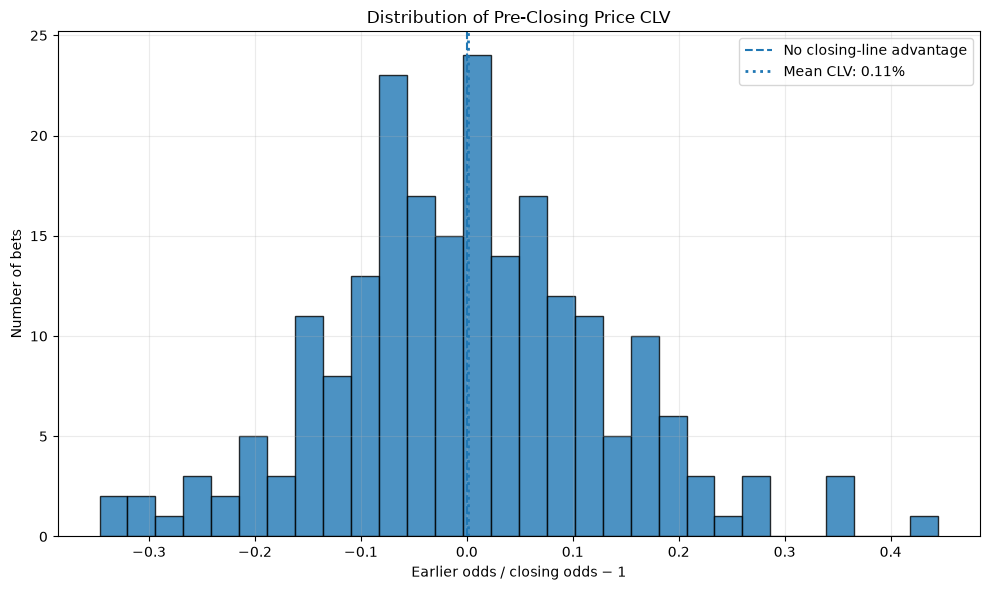

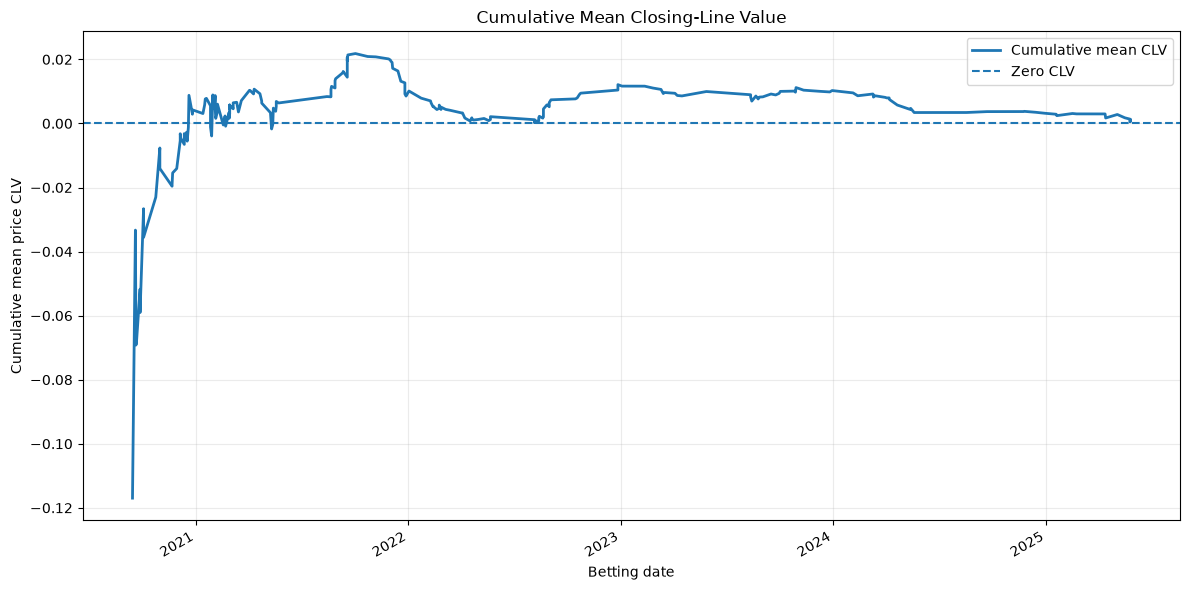

Pre-closing strategy and CLV analysis completed successfully.
Detected forecast source: model_market_edges
Earlier-price selected bets: 215
Mean price CLV: 0.11%
Bets beating closing price: 49.77%
Bootstrap 95% interval for mean price CLV: [-1.62%, 1.91%]

Overall CLV summary:


,ForecastSource,EarlierExpectedReturnThreshold,AvailableFixtures,SelectedBets,WinningBets,HitRate,MeanEarlierOdds,MeanClosingOdds,MeanOddsCLV,MedianOddsCLV,...,MeanProbabilityCLV,MedianProbabilityCLV,PositiveProbabilityCLVPercentage,ProbabilityCLVBootstrap95Lower,ProbabilityCLVBootstrap95Upper,EarlierPriceProfit,EarlierPriceROI,ClosingPriceProfitSameBets,ClosingPriceROISameBets,ProfitAdvantageFromEarlierPrices
0,model_market_edges,0.5,1900,215,43,0.2,7.330512,7.353674,0.00112,0.0,...,-0.00048,0.000475,0.506977,-0.003618,0.002685,3.48,0.016186,7.74,0.036,-4.26



CLV by season:


,Season,Bets,WinningBets,HitRate,MeanEarlierOdds,MeanClosingOdds,MeanOddsCLV,MedianOddsCLV,PositiveOddsCLVPercentage,MeanProbabilityCLV,EarlierPriceProfit,ClosingPriceProfitSameBets,EarlierPriceROI,ClosingPriceROISameBets
0,2020-21,75,18,0.240000,6.887067,6.839600,0.006391,0.008021,0.533333,-0.000849,9.78,12.59,0.130400,0.167867
1,2021-22,56,9,0.160714,7.811250,7.957143,-0.003620,-0.012873,0.446429,-0.000883,-10.75,-10.13,-0.191964,-0.180893
2,2022-23,31,3,0.096774,9.094194,8.468710,0.043154,0.046429,0.645161,0.002939,-9.35,-11.33,-0.301613,-0.365484
3,2023-24,36,8,0.222222,6.429444,6.744722,-0.026102,-0.036418,0.416667,-0.004230,2.96,3.67,0.082222,0.101944
4,2024-25,17,5,0.294118,6.395294,6.890000,-0.025523,-0.022388,0.411765,0.004176,10.84,12.94,0.637647,0.761176



CLV by selected outcome:


,Outcome,Bets,WinningBets,HitRate,MeanEarlierOdds,MeanClosingOdds,MeanOddsCLV,MedianOddsCLV,PositiveOddsCLVPercentage,MeanProbabilityCLV,EarlierPriceProfit,EarlierPriceROI
0,A,102,17,0.166667,8.890490,8.689118,0.012439,0.003401,0.519608,-0.000482,-6.20,-0.060784
1,H,113,26,0.230088,5.922389,6.148230,-0.009097,-0.013619,0.477876,-0.000479,9.68,0.085664



Largest positive CLV selections:


,Season,Date,HomeTeam,AwayTeam,ActualOutcome,Outcome,ModelProbability,EarlierOdds,ClosingOdds,EarlierModelExpectedReturn,OddsCLV,ProbabilityCLV,OutcomeOccurred,EarlierPriceUnitReturn
0,2020-21,2021-01-30,Man City,Sheffield United,H,A,0.060001,26.18,18.12,0.570829,0.444812,0.016327,0,-1.0
1,2020-21,2021-05-14,Newcastle,Man City,A,H,0.151726,11.02,8.12,0.672017,0.357143,0.031774,0,-1.0
2,2021-22,2021-09-18,Liverpool,Crystal Palace,H,A,0.104837,15.60,11.57,0.635459,0.348315,0.022067,0,-1.0
3,2022-23,2022-08-21,Newcastle,Man City,D,H,0.159254,9.43,7.00,0.501767,0.347143,0.036426,0,-1.0
4,2023-24,2023-08-21,Crystal Palace,Arsenal,A,H,0.271384,5.73,4.51,0.555029,0.270510,0.047396,0,-1.0
5,2022-23,2022-12-27,Man United,Nott'm Forest,H,A,0.131718,11.66,9.20,0.535827,0.267391,0.022254,0,-1.0
6,2023-24,2023-10-29,Aston Villa,Luton,H,A,0.243983,10.80,8.55,1.635017,0.263158,0.023578,0,-1.0
7,2020-21,2020-12-20,Brighton,Sheffield United,D,A,0.312184,5.79,4.64,0.807544,0.247845,0.041781,0,-1.0
8,2024-25,2025-05-03,Arsenal,Bournemouth,A,H,0.765985,2.07,1.68,0.585588,0.232143,0.109592,0,-1.0
9,2022-23,2023-05-28,Everton,Bournemouth,H,A,0.280848,6.54,5.31,0.836749,0.231638,0.035339,0,-1.0



Largest negative CLV selections:


,Season,Date,HomeTeam,AwayTeam,ActualOutcome,Outcome,ModelProbability,EarlierOdds,ClosingOdds,EarlierModelExpectedReturn,OddsCLV,ProbabilityCLV,OutcomeOccurred,EarlierPriceUnitReturn
0,2021-22,2021-12-26,Man City,Leicester,H,A,0.135443,13.72,21.00,0.858280,-0.346667,-0.023776,0,-1.0
1,2020-21,2021-05-11,Man United,Leicester,A,H,0.680087,2.59,3.94,0.761424,-0.342640,-0.130175,0,-1.0
2,2023-24,2024-04-20,Wolves,Arsenal,A,H,0.207755,8.02,11.75,0.666192,-0.317447,-0.037441,0,-1.0
3,2021-22,2021-12-19,Newcastle,Man City,A,H,0.101421,16.21,23.50,0.644029,-0.310213,-0.017681,0,-1.0
4,2020-21,2021-02-17,Everton,Man City,A,H,0.275126,8.77,12.07,1.412852,-0.273405,-0.030537,0,-1.0
5,2024-25,2025-04-13,Chelsea,Ipswich,D,A,0.153261,10.14,13.76,0.554070,-0.263081,-0.024085,0,-1.0
6,2023-24,2024-05-12,Man United,Arsenal,A,H,0.242839,7.20,9.75,0.748441,-0.261538,-0.034797,0,-1.0
7,2023-24,2024-05-19,Crystal Palace,Aston Villa,H,A,0.439262,3.74,4.99,0.642842,-0.250501,-0.061765,0,-1.0
8,2021-22,2022-01-23,Arsenal,Burnley,D,A,0.183215,9.18,11.90,0.681909,-0.228571,-0.022874,0,-1.0
9,2024-25,2025-05-16,Aston Villa,Tottenham,H,A,0.216265,8.61,11.00,0.862041,-0.217273,-0.023827,0,-1.0


In [15]:
# ============================================================
# 15. Pre-Closing Bet Selection and Closing-Line Value
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

EARLIER_EXPECTED_RETURN_THRESHOLD = 0.50
CLV_BOOTSTRAP_REPETITIONS = 10_000
CLV_RANDOM_SEED = 42

FIXTURE_KEYS = [
    "Season",
    "Date",
    "HomeTeam",
    "AwayTeam",
]

OUTCOME_ORDER = {
    "H": 0,
    "D": 1,
    "A": 2,
}


# ------------------------------------------------------------
# Helper for displaying DataFrames without attempting to
# round datetime columns
# ------------------------------------------------------------

def round_numeric_columns(
    dataframe,
    decimal_places=6,
):
    display_frame = dataframe.copy()

    numeric_columns = (
        display_frame
        .select_dtypes(
            include=[np.number]
        )
        .columns
    )

    display_frame[
        numeric_columns
    ] = display_frame[
        numeric_columns
    ].round(
        decimal_places
    )

    return display_frame

# ------------------------------------------------------------
# Locate the correct outcome-level walk-forward forecasts
# ------------------------------------------------------------

CLV_EVALUATION_SEASONS = [
    "2020-21",
    "2021-22",
    "2022-23",
    "2023-24",
    "2024-25",
]

EXPECTED_CLV_FIXTURES = (
    len(CLV_EVALUATION_SEASONS)
    *
    380
)

required_forecast_columns = set(
    FIXTURE_KEYS
    +
    [
        "Outcome",
        "ModelProbability",
    ]
)


# Objects created by this Part 15 cell must not be selected
# when the cell is rerun after a partial failure.
excluded_forecast_object_prefixes = (
    "clv_",
    "preclosing_",
    "selected_forecast_",
    "forecast_source_",
)


forecast_source_candidates = []


for object_name, object_value in list(
    globals().items()
):

    if object_name.startswith(
        excluded_forecast_object_prefixes
    ):
        continue

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    if not required_forecast_columns.issubset(
        object_value.columns
    ):
        continue

    candidate_data = object_value.copy()


    # --------------------------------------------------------
    # Retain Independent Poisson where the object contains
    # forecasts from multiple models
    # --------------------------------------------------------

    if "Model" in candidate_data.columns:

        normalised_model_names = (
            candidate_data[
                "Model"
            ]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        independent_poisson_rows = (
            normalised_model_names.eq(
                "independent poisson"
            )
        )

        if independent_poisson_rows.any():

            candidate_data = (
                candidate_data.loc[
                    independent_poisson_rows
                ]
                .copy()
            )

        else:

            # The object explicitly identifies another model,
            # so it cannot be the required Poisson source.
            continue


    # --------------------------------------------------------
    # Standardise the core columns
    # --------------------------------------------------------

    candidate_data[
        "Season"
    ] = (
        candidate_data[
            "Season"
        ]
        .astype(str)
        .str.strip()
    )


    candidate_data = (
        candidate_data.loc[
            candidate_data[
                "Season"
            ].isin(
                CLV_EVALUATION_SEASONS
            )
        ]
        .copy()
    )


    if candidate_data.empty:
        continue


    candidate_data[
        "Date"
    ] = pd.to_datetime(
        candidate_data[
            "Date"
        ],
        errors="coerce",
        dayfirst=True,
        format="mixed",
    ).dt.normalize()


    candidate_data[
        "Outcome"
    ] = (
        candidate_data[
            "Outcome"
        ]
        .astype(str)
        .str.strip()
        .str.upper()
    )


    candidate_data[
        "ModelProbability"
    ] = pd.to_numeric(
        candidate_data[
            "ModelProbability"
        ],
        errors="coerce",
    )


    candidate_data = (
        candidate_data.loc[
            candidate_data[
                "Outcome"
            ].isin(
                [
                    "H",
                    "D",
                    "A",
                ]
            )
        ]
        .dropna(
            subset=(
                FIXTURE_KEYS
                +
                [
                    "Outcome",
                    "ModelProbability",
                ]
            )
        )
        .copy()
    )


    if candidate_data.empty:
        continue


    # --------------------------------------------------------
    # Reconstruct or validate the actual outcome
    # --------------------------------------------------------

    if "ActualOutcome" in candidate_data.columns:

        candidate_data[
            "ActualOutcome"
        ] = (
            candidate_data[
                "ActualOutcome"
            ]
            .astype(str)
            .str.strip()
            .str.upper()
        )

    elif "OutcomeOccurred" in candidate_data.columns:

        candidate_data[
            "OutcomeOccurred"
        ] = pd.to_numeric(
            candidate_data[
                "OutcomeOccurred"
            ],
            errors="coerce",
        )


        candidate_actual_outcomes = (
            candidate_data.loc[
                candidate_data[
                    "OutcomeOccurred"
                ].eq(1)
            ]
            [
                FIXTURE_KEYS
                +
                [
                    "Outcome",
                ]
            ]
            .rename(
                columns={
                    "Outcome": "ActualOutcome",
                }
            )
            .drop_duplicates(
                subset=FIXTURE_KEYS,
                keep="last",
            )
        )


        candidate_data = (
            candidate_data
            .merge(
                candidate_actual_outcomes,
                on=FIXTURE_KEYS,
                how="left",
                validate="many_to_one",
            )
        )

    else:

        # Actual outcomes are required later to calculate
        # realised betting returns.
        continue


    candidate_data = (
        candidate_data
        .dropna(
            subset=[
                "ActualOutcome",
            ]
        )
        .sort_values(
            by=(
                FIXTURE_KEYS
                +
                [
                    "Outcome",
                ]
            ),
            kind="mergesort",
        )
        .drop_duplicates(
            subset=(
                FIXTURE_KEYS
                +
                [
                    "Outcome",
                ]
            ),
            keep="last",
        )
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # Assess fixture-level completeness
    # --------------------------------------------------------

    candidate_fixture_diagnostics = (
        candidate_data
        .groupby(
            FIXTURE_KEYS,
            sort=False,
        )
        .agg(
            OutcomeCount=(
                "Outcome",
                "nunique",
            ),
            ProbabilityTotal=(
                "ModelProbability",
                "sum",
            ),
            ActualOutcomeCount=(
                "ActualOutcome",
                "nunique",
            ),
        )
        .reset_index()
    )


    candidate_fixture_diagnostics[
        "CompleteOutcomeTriplet"
    ] = (
        candidate_fixture_diagnostics[
            "OutcomeCount"
        ].eq(3)
    )


    candidate_fixture_diagnostics[
        "ValidProbabilityTotal"
    ] = np.isclose(
        candidate_fixture_diagnostics[
            "ProbabilityTotal"
        ],
        1.0,
        atol=1e-6,
    )


    candidate_fixture_diagnostics[
        "ConsistentActualOutcome"
    ] = (
        candidate_fixture_diagnostics[
            "ActualOutcomeCount"
        ].eq(1)
    )


    candidate_fixture_diagnostics[
        "FullyValidFixture"
    ] = (
        candidate_fixture_diagnostics[
            "CompleteOutcomeTriplet"
        ]
        &
        candidate_fixture_diagnostics[
            "ValidProbabilityTotal"
        ]
        &
        candidate_fixture_diagnostics[
            "ConsistentActualOutcome"
        ]
    )


    complete_fixture_count = int(
        candidate_fixture_diagnostics[
            "CompleteOutcomeTriplet"
        ].sum()
    )


    valid_fixture_count = int(
        candidate_fixture_diagnostics[
            "FullyValidFixture"
        ].sum()
    )


    # --------------------------------------------------------
    # Prefer objects whose names indicate that they contain
    # walk-forward/model-market forecasts
    # --------------------------------------------------------

    object_name_lower = object_name.lower()

    name_preference_score = (
        10
        *
        int(
            "model_market" in object_name_lower
        )
        +
        8
        *
        int(
            "walk_forward" in object_name_lower
        )
        +
        6
        *
        int(
            "fixture_prob" in object_name_lower
        )
        +
        4
        *
        int(
            "poisson" in object_name_lower
        )
        +
        2
        *
        int(
            "outcome" in object_name_lower
        )
    )


    forecast_source_candidates.append(
        {
            "ObjectName": object_name,
            "RowsAfterFiltering": len(
                candidate_data
            ),
            "UniqueFixtures": len(
                candidate_fixture_diagnostics
            ),
            "CompleteFixtures": (
                complete_fixture_count
            ),
            "FullyValidFixtures": (
                valid_fixture_count
            ),
            "ExactExpectedCoverage": int(
                valid_fixture_count
                ==
                EXPECTED_CLV_FIXTURES
            ),
            "NamePreferenceScore": (
                name_preference_score
            ),
            "DataFrame": candidate_data,
        }
    )


assert forecast_source_candidates, (
    "No suitable outcome-level Independent Poisson "
    "forecast DataFrame was found."
)


# ------------------------------------------------------------
# Select the object with complete 1,900-fixture coverage
# ------------------------------------------------------------

forecast_source_candidates = sorted(
    forecast_source_candidates,
    key=lambda candidate: (
        candidate[
            "ExactExpectedCoverage"
        ],
        candidate[
            "FullyValidFixtures"
        ],
        candidate[
            "NamePreferenceScore"
        ],
        candidate[
            "RowsAfterFiltering"
        ],
    ),
    reverse=True,
)


selected_forecast_source = (
    forecast_source_candidates[0]
)


forecast_candidate_inventory = pd.DataFrame(
    [
        {
            key: value
            for key, value in candidate.items()
            if key != "DataFrame"
        }
        for candidate
        in forecast_source_candidates
    ]
)


display(
    forecast_candidate_inventory
    .sort_values(
        by=[
            "ExactExpectedCoverage",
            "FullyValidFixtures",
            "NamePreferenceScore",
        ],
        ascending=[
            False,
            False,
            False,
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


assert (
    selected_forecast_source[
        "FullyValidFixtures"
    ]
    ==
    EXPECTED_CLV_FIXTURES
), (
    "No candidate contains complete and valid forecasts "
    f"for all {EXPECTED_CLV_FIXTURES:,} out-of-sample "
    "fixtures from 2020-21 to 2024-25."
)


clv_forecast_source_name = (
    selected_forecast_source[
        "ObjectName"
    ]
)


clv_model_forecasts = (
    selected_forecast_source[
        "DataFrame"
    ]
    .copy()
)


# ------------------------------------------------------------
# Retain only fixtures that satisfy every validity condition
# ------------------------------------------------------------

final_fixture_diagnostics = (
    clv_model_forecasts
    .groupby(
        FIXTURE_KEYS,
        sort=False,
    )
    .agg(
        OutcomeCount=(
            "Outcome",
            "nunique",
        ),
        ProbabilityTotal=(
            "ModelProbability",
            "sum",
        ),
        ActualOutcomeCount=(
            "ActualOutcome",
            "nunique",
        ),
    )
    .reset_index()
)


final_fixture_diagnostics[
    "FullyValidFixture"
] = (
    final_fixture_diagnostics[
        "OutcomeCount"
    ].eq(3)
    &
    np.isclose(
        final_fixture_diagnostics[
            "ProbabilityTotal"
        ],
        1.0,
        atol=1e-6,
    )
    &
    final_fixture_diagnostics[
        "ActualOutcomeCount"
    ].eq(1)
)


valid_fixture_keys = (
    final_fixture_diagnostics.loc[
        final_fixture_diagnostics[
            "FullyValidFixture"
        ],
        FIXTURE_KEYS,
    ]
)


clv_model_forecasts = (
    clv_model_forecasts
    .merge(
        valid_fixture_keys,
        on=FIXTURE_KEYS,
        how="inner",
        validate="many_to_one",
    )
    .sort_values(
        by=(
            FIXTURE_KEYS
            +
            [
                "Outcome",
            ]
        ),
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Final strict assertions
# ------------------------------------------------------------

forecast_outcome_coverage = (
    clv_model_forecasts
    .groupby(
        FIXTURE_KEYS,
        sort=False,
    )[
        "Outcome"
    ]
    .nunique()
)


assert forecast_outcome_coverage.eq(3).all(), (
    "At least one retained fixture does not have exactly "
    "three outcome forecasts."
)


fixture_probability_totals = (
    clv_model_forecasts
    .groupby(
        FIXTURE_KEYS,
        sort=False,
    )[
        "ModelProbability"
    ]
    .sum()
)


assert np.allclose(
    fixture_probability_totals.to_numpy(),
    1.0,
    atol=1e-6,
), (
    "Model probabilities do not sum to one "
    "within every fixture."
)


assert (
    clv_model_forecasts[
        FIXTURE_KEYS
    ]
    .drop_duplicates()
    .shape[0]
    ==
    EXPECTED_CLV_FIXTURES
), (
    "The final CLV forecast source does not contain "
    f"exactly {EXPECTED_CLV_FIXTURES:,} fixtures."
)


assert len(
    clv_model_forecasts
) == (
    EXPECTED_CLV_FIXTURES
    *
    3
), (
    "The final outcome-level forecast source should contain "
    f"{EXPECTED_CLV_FIXTURES * 3:,} rows."
)


print(
    "Correct CLV forecast source selected successfully."
)

print(
    "Selected object:",
    clv_forecast_source_name,
)

print(
    "Fixtures:",
    f"{EXPECTED_CLV_FIXTURES:,}",
)

print(
    "Outcome-level forecasts:",
    f"{len(clv_model_forecasts):,}",
)


# ------------------------------------------------------------
# Convert the paired Pinnacle prices to outcome-level data
# ------------------------------------------------------------

outcome_price_frames = []


price_column_mapping = {
    "H": {
        "EarlierOdds": "PSH",
        "ClosingOdds": "PSCH",
        "EarlierNoVigProbability": (
            "EarlierNoVigProbability_H"
        ),
        "ClosingNoVigProbability": (
            "ClosingNoVigProbability_H"
        ),
    },
    "D": {
        "EarlierOdds": "PSD",
        "ClosingOdds": "PSCD",
        "EarlierNoVigProbability": (
            "EarlierNoVigProbability_D"
        ),
        "ClosingNoVigProbability": (
            "ClosingNoVigProbability_D"
        ),
    },
    "A": {
        "EarlierOdds": "PSA",
        "ClosingOdds": "PSCA",
        "EarlierNoVigProbability": (
            "EarlierNoVigProbability_A"
        ),
        "ClosingNoVigProbability": (
            "ClosingNoVigProbability_A"
        ),
    },
}


for outcome, column_mapping in (
    price_column_mapping.items()
):

    outcome_prices = (
        pinnacle_paired_prices[
            FIXTURE_KEYS
        ]
        .copy()
    )

    outcome_prices[
        "Outcome"
    ] = outcome

    for new_column, source_column in (
        column_mapping.items()
    ):

        outcome_prices[
            new_column
        ] = (
            pinnacle_paired_prices[
                source_column
            ]
            .to_numpy()
        )

    outcome_price_frames.append(
        outcome_prices
    )


pinnacle_outcome_prices = pd.concat(
    outcome_price_frames,
    ignore_index=True,
)


pinnacle_outcome_prices[
    "Date"
] = pd.to_datetime(
    pinnacle_outcome_prices[
        "Date"
    ],
    errors="coerce",
).dt.normalize()


# ------------------------------------------------------------
# Merge forecasts with earlier and closing prices
# ------------------------------------------------------------

preclosing_model_market_data = (
    clv_model_forecasts
    .merge(
        pinnacle_outcome_prices,
        on=(
            FIXTURE_KEYS
            +
            [
                "Outcome",
            ]
        ),
        how="inner",
        validate="one_to_one",
    )
)


assert len(
    preclosing_model_market_data
) > 0, (
    "No model forecasts matched the paired "
    "Pinnacle price data."
)


assert preclosing_model_market_data[
    [
        "EarlierOdds",
        "ClosingOdds",
        "EarlierNoVigProbability",
        "ClosingNoVigProbability",
    ]
].notna().all().all(), (
    "Missing values remain after merging model forecasts "
    "with Pinnacle price data."
)


# ------------------------------------------------------------
# Calculate expected returns using EARLIER prices only
# ------------------------------------------------------------

preclosing_model_market_data[
    "EarlierModelExpectedReturn"
] = (
    preclosing_model_market_data[
        "ModelProbability"
    ]
    *
    preclosing_model_market_data[
        "EarlierOdds"
    ]
    -
    1
)


preclosing_model_market_data[
    "ClosingModelExpectedReturn"
] = (
    preclosing_model_market_data[
        "ModelProbability"
    ]
    *
    preclosing_model_market_data[
        "ClosingOdds"
    ]
    -
    1
)


preclosing_model_market_data[
    "OutcomeOrder"
] = (
    preclosing_model_market_data[
        "Outcome"
    ]
    .map(
        OUTCOME_ORDER
    )
)


# ------------------------------------------------------------
# Select the highest earlier-price expected return
# in each fixture
# ------------------------------------------------------------

preclosing_highest_return_candidates = (
    preclosing_model_market_data
    .sort_values(
        by=(
            FIXTURE_KEYS
            +
            [
                "EarlierModelExpectedReturn",
                "OutcomeOrder",
            ]
        ),
        ascending=[
            True,
            True,
            True,
            True,
            False,
            True,
        ],
        kind="mergesort",
    )
    .groupby(
        FIXTURE_KEYS,
        as_index=False,
        sort=False,
    )
    .head(1)
    .reset_index(drop=True)
)


assert (
    preclosing_highest_return_candidates
    .duplicated(
        subset=FIXTURE_KEYS
    )
    .sum()
    ==
    0
), (
    "More than one highest-return candidate "
    "was retained for a fixture."
)


# ------------------------------------------------------------
# Apply the frozen 50% expected-return threshold
# ------------------------------------------------------------

preclosing_selected_bets = (
    preclosing_highest_return_candidates.loc[
        preclosing_highest_return_candidates[
            "EarlierModelExpectedReturn"
        ]
        >=
        EARLIER_EXPECTED_RETURN_THRESHOLD
    ]
    .sort_values(
        by=FIXTURE_KEYS,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


assert len(
    preclosing_selected_bets
) > 0, (
    "The earlier-price strategy selected no bets."
)


# ------------------------------------------------------------
# Calculate CLV and realised returns
# ------------------------------------------------------------

preclosing_selected_bets[
    "OddsCLV"
] = (
    preclosing_selected_bets[
        "EarlierOdds"
    ]
    /
    preclosing_selected_bets[
        "ClosingOdds"
    ]
    -
    1
)


preclosing_selected_bets[
    "ProbabilityCLV"
] = (
    preclosing_selected_bets[
        "ClosingNoVigProbability"
    ]
    -
    preclosing_selected_bets[
        "EarlierNoVigProbability"
    ]
)


preclosing_selected_bets[
    "BeatClosingPrice"
] = (
    preclosing_selected_bets[
        "OddsCLV"
    ]
    >
    0
)


preclosing_selected_bets[
    "PositiveProbabilityCLV"
] = (
    preclosing_selected_bets[
        "ProbabilityCLV"
    ]
    >
    0
)


preclosing_selected_bets[
    "OutcomeOccurred"
] = (
    preclosing_selected_bets[
        "Outcome"
    ]
    ==
    preclosing_selected_bets[
        "ActualOutcome"
    ]
).astype(int)


preclosing_selected_bets[
    "EarlierPriceUnitReturn"
] = np.where(
    preclosing_selected_bets[
        "OutcomeOccurred"
    ].eq(1),
    preclosing_selected_bets[
        "EarlierOdds"
    ]
    -
    1,
    -1.0,
)


preclosing_selected_bets[
    "ClosingPriceUnitReturn"
] = np.where(
    preclosing_selected_bets[
        "OutcomeOccurred"
    ].eq(1),
    preclosing_selected_bets[
        "ClosingOdds"
    ]
    -
    1,
    -1.0,
)


preclosing_selected_bets[
    "ProfitAdvantageFromEarlierPrice"
] = (
    preclosing_selected_bets[
        "EarlierPriceUnitReturn"
    ]
    -
    preclosing_selected_bets[
        "ClosingPriceUnitReturn"
    ]
)


# ------------------------------------------------------------
# Bootstrap mean price and probability CLV
# ------------------------------------------------------------

clv_random_generator = (
    np.random.default_rng(
        CLV_RANDOM_SEED
    )
)


number_of_clv_bets = len(
    preclosing_selected_bets
)


bootstrap_indices = (
    clv_random_generator.integers(
        low=0,
        high=number_of_clv_bets,
        size=(
            CLV_BOOTSTRAP_REPETITIONS,
            number_of_clv_bets,
        ),
    )
)


odds_clv_values = (
    preclosing_selected_bets[
        "OddsCLV"
    ]
    .to_numpy(
        dtype=float
    )
)


probability_clv_values = (
    preclosing_selected_bets[
        "ProbabilityCLV"
    ]
    .to_numpy(
        dtype=float
    )
)


bootstrap_mean_odds_clv = (
    odds_clv_values[
        bootstrap_indices
    ]
    .mean(
        axis=1
    )
)


bootstrap_mean_probability_clv = (
    probability_clv_values[
        bootstrap_indices
    ]
    .mean(
        axis=1
    )
)


odds_clv_bootstrap_lower = float(
    np.quantile(
        bootstrap_mean_odds_clv,
        0.025,
    )
)


odds_clv_bootstrap_upper = float(
    np.quantile(
        bootstrap_mean_odds_clv,
        0.975,
    )
)


probability_clv_bootstrap_lower = float(
    np.quantile(
        bootstrap_mean_probability_clv,
        0.025,
    )
)


probability_clv_bootstrap_upper = float(
    np.quantile(
        bootstrap_mean_probability_clv,
        0.975,
    )
)


bootstrap_probability_positive_odds_clv = float(
    (
        bootstrap_mean_odds_clv
        >
        0
    ).mean()
)


# ------------------------------------------------------------
# Overall summary
# ------------------------------------------------------------

earlier_price_profit = float(
    preclosing_selected_bets[
        "EarlierPriceUnitReturn"
    ].sum()
)


closing_price_profit = float(
    preclosing_selected_bets[
        "ClosingPriceUnitReturn"
    ].sum()
)


preclosing_clv_summary = pd.DataFrame(
    [
        {
            "ForecastSource": (
                clv_forecast_source_name
            ),
            "EarlierExpectedReturnThreshold": (
                EARLIER_EXPECTED_RETURN_THRESHOLD
            ),
            "AvailableFixtures": (
                preclosing_highest_return_candidates[
                    FIXTURE_KEYS
                ]
                .drop_duplicates()
                .shape[0]
            ),
            "SelectedBets": (
                number_of_clv_bets
            ),
            "WinningBets": int(
                preclosing_selected_bets[
                    "OutcomeOccurred"
                ].sum()
            ),
            "HitRate": float(
                preclosing_selected_bets[
                    "OutcomeOccurred"
                ].mean()
            ),
            "MeanEarlierOdds": float(
                preclosing_selected_bets[
                    "EarlierOdds"
                ].mean()
            ),
            "MeanClosingOdds": float(
                preclosing_selected_bets[
                    "ClosingOdds"
                ].mean()
            ),
            "MeanOddsCLV": float(
                preclosing_selected_bets[
                    "OddsCLV"
                ].mean()
            ),
            "MedianOddsCLV": float(
                preclosing_selected_bets[
                    "OddsCLV"
                ].median()
            ),
            "PositiveOddsCLVPercentage": float(
                preclosing_selected_bets[
                    "BeatClosingPrice"
                ].mean()
            ),
            "OddsCLVBootstrap95Lower": (
                odds_clv_bootstrap_lower
            ),
            "OddsCLVBootstrap95Upper": (
                odds_clv_bootstrap_upper
            ),
            "BootstrapProbabilityMeanOddsCLVPositive": (
                bootstrap_probability_positive_odds_clv
            ),
            "MeanProbabilityCLV": float(
                preclosing_selected_bets[
                    "ProbabilityCLV"
                ].mean()
            ),
            "MedianProbabilityCLV": float(
                preclosing_selected_bets[
                    "ProbabilityCLV"
                ].median()
            ),
            "PositiveProbabilityCLVPercentage": float(
                preclosing_selected_bets[
                    "PositiveProbabilityCLV"
                ].mean()
            ),
            "ProbabilityCLVBootstrap95Lower": (
                probability_clv_bootstrap_lower
            ),
            "ProbabilityCLVBootstrap95Upper": (
                probability_clv_bootstrap_upper
            ),
            "EarlierPriceProfit": (
                earlier_price_profit
            ),
            "EarlierPriceROI": (
                earlier_price_profit
                /
                number_of_clv_bets
            ),
            "ClosingPriceProfitSameBets": (
                closing_price_profit
            ),
            "ClosingPriceROISameBets": (
                closing_price_profit
                /
                number_of_clv_bets
            ),
            "ProfitAdvantageFromEarlierPrices": (
                earlier_price_profit
                -
                closing_price_profit
            ),
        }
    ]
)


# ------------------------------------------------------------
# CLV by evaluation season
# ------------------------------------------------------------

preclosing_clv_by_season = (
    preclosing_selected_bets
    .groupby(
        "Season",
        as_index=False,
        sort=True,
    )
    .agg(
        Bets=(
            "Outcome",
            "size",
        ),
        WinningBets=(
            "OutcomeOccurred",
            "sum",
        ),
        HitRate=(
            "OutcomeOccurred",
            "mean",
        ),
        MeanEarlierOdds=(
            "EarlierOdds",
            "mean",
        ),
        MeanClosingOdds=(
            "ClosingOdds",
            "mean",
        ),
        MeanOddsCLV=(
            "OddsCLV",
            "mean",
        ),
        MedianOddsCLV=(
            "OddsCLV",
            "median",
        ),
        PositiveOddsCLVPercentage=(
            "BeatClosingPrice",
            "mean",
        ),
        MeanProbabilityCLV=(
            "ProbabilityCLV",
            "mean",
        ),
        EarlierPriceProfit=(
            "EarlierPriceUnitReturn",
            "sum",
        ),
        ClosingPriceProfitSameBets=(
            "ClosingPriceUnitReturn",
            "sum",
        ),
    )
)


preclosing_clv_by_season[
    "EarlierPriceROI"
] = (
    preclosing_clv_by_season[
        "EarlierPriceProfit"
    ]
    /
    preclosing_clv_by_season[
        "Bets"
    ]
)


preclosing_clv_by_season[
    "ClosingPriceROISameBets"
] = (
    preclosing_clv_by_season[
        "ClosingPriceProfitSameBets"
    ]
    /
    preclosing_clv_by_season[
        "Bets"
    ]
)


# ------------------------------------------------------------
# CLV by selected outcome
# ------------------------------------------------------------

preclosing_clv_by_outcome = (
    preclosing_selected_bets
    .groupby(
        "Outcome",
        as_index=False,
        sort=True,
    )
    .agg(
        Bets=(
            "Outcome",
            "size",
        ),
        WinningBets=(
            "OutcomeOccurred",
            "sum",
        ),
        HitRate=(
            "OutcomeOccurred",
            "mean",
        ),
        MeanEarlierOdds=(
            "EarlierOdds",
            "mean",
        ),
        MeanClosingOdds=(
            "ClosingOdds",
            "mean",
        ),
        MeanOddsCLV=(
            "OddsCLV",
            "mean",
        ),
        MedianOddsCLV=(
            "OddsCLV",
            "median",
        ),
        PositiveOddsCLVPercentage=(
            "BeatClosingPrice",
            "mean",
        ),
        MeanProbabilityCLV=(
            "ProbabilityCLV",
            "mean",
        ),
        EarlierPriceProfit=(
            "EarlierPriceUnitReturn",
            "sum",
        ),
    )
)


preclosing_clv_by_outcome[
    "EarlierPriceROI"
] = (
    preclosing_clv_by_outcome[
        "EarlierPriceProfit"
    ]
    /
    preclosing_clv_by_outcome[
        "Bets"
    ]
)


# ------------------------------------------------------------
# Figure 1: distribution of price CLV
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.hist(
    preclosing_selected_bets[
        "OddsCLV"
    ],
    bins=30,
    edgecolor="black",
    alpha=0.8,
)


ax.axvline(
    x=0,
    linestyle="--",
    linewidth=1.5,
    label="No closing-line advantage",
)


ax.axvline(
    x=preclosing_selected_bets[
        "OddsCLV"
    ].mean(),
    linestyle=":",
    linewidth=2,
    label=(
        "Mean CLV: "
        f"{preclosing_selected_bets['OddsCLV'].mean():.2%}"
    ),
)


ax.set_title(
    "Distribution of Pre-Closing Price CLV"
)

ax.set_xlabel(
    "Earlier odds / closing odds − 1"
)

ax.set_ylabel(
    "Number of bets"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Figure 2: cumulative average CLV through time
# ------------------------------------------------------------

clv_chronological_path = (
    preclosing_selected_bets
    .sort_values(
        by=FIXTURE_KEYS,
        kind="mergesort",
    )
    .reset_index(drop=True)
    .copy()
)


clv_chronological_path[
    "CumulativeMeanOddsCLV"
] = (
    clv_chronological_path[
        "OddsCLV"
    ]
    .expanding()
    .mean()
)


fig, ax = plt.subplots(
    figsize=(12, 6)
)


ax.plot(
    clv_chronological_path[
        "Date"
    ],
    clv_chronological_path[
        "CumulativeMeanOddsCLV"
    ],
    linewidth=2,
    label="Cumulative mean CLV",
)


ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Zero CLV",
)


ax.set_title(
    "Cumulative Mean Closing-Line Value"
)

ax.set_xlabel(
    "Betting date"
)

ax.set_ylabel(
    "Cumulative mean price CLV"
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.autofmt_xdate()

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print(
    "Pre-closing strategy and CLV analysis "
    "completed successfully."
)

print(
    "Detected forecast source:",
    clv_forecast_source_name,
)

print(
    "Earlier-price selected bets:",
    f"{number_of_clv_bets:,}",
)

print(
    "Mean price CLV:",
    f"{preclosing_selected_bets['OddsCLV'].mean():.2%}",
)

print(
    "Bets beating closing price:",
    f"{preclosing_selected_bets['BeatClosingPrice'].mean():.2%}",
)

print(
    "Bootstrap 95% interval for mean price CLV:",
    (
        f"[{odds_clv_bootstrap_lower:.2%}, "
        f"{odds_clv_bootstrap_upper:.2%}]"
    ),
)


print(
    "\nOverall CLV summary:"
)

display(
    round_numeric_columns(
        preclosing_clv_summary
    )
)


print(
    "\nCLV by season:"
)

display(
    round_numeric_columns(
        preclosing_clv_by_season
    )
)


print(
    "\nCLV by selected outcome:"
)

display(
    round_numeric_columns(
        preclosing_clv_by_outcome
    )
)


print(
    "\nLargest positive CLV selections:"
)

display(
    round_numeric_columns(
        preclosing_selected_bets[
            FIXTURE_KEYS
            +
            [
                "ActualOutcome",
                "Outcome",
                "ModelProbability",
                "EarlierOdds",
                "ClosingOdds",
                "EarlierModelExpectedReturn",
                "OddsCLV",
                "ProbabilityCLV",
                "OutcomeOccurred",
                "EarlierPriceUnitReturn",
            ]
        ]
        .sort_values(
            by="OddsCLV",
            ascending=False,
            kind="mergesort",
        )
        .head(10)
        .reset_index(drop=True)
    )
)


print(
    "\nLargest negative CLV selections:"
)

display(
    round_numeric_columns(
        preclosing_selected_bets[
            FIXTURE_KEYS
            +
            [
                "ActualOutcome",
                "Outcome",
                "ModelProbability",
                "EarlierOdds",
                "ClosingOdds",
                "EarlierModelExpectedReturn",
                "OddsCLV",
                "ProbabilityCLV",
                "OutcomeOccurred",
                "EarlierPriceUnitReturn",
            ]
        ]
        .sort_values(
            by="OddsCLV",
            ascending=True,
            kind="mergesort",
        )
        .head(10)
        .reset_index(drop=True)
    )
)

### Results and Interpretation

The pre-closing strategy selected:

$$
215
$$

bets from the available 1,900 fixtures using only the earlier Pinnacle prices.

The selected bets had an average decimal price of approximately:

$$
7.33,
$$

illustrating that the strategy remained concentrated in relatively high-odds outcomes.

The average price-based closing-line value was:

$$
0.11\%.
$$

However, only:

$$
49.77\%
$$

of the selected bets obtained a better price than the subsequent Pinnacle closing price.

The bootstrap 95% confidence interval for mean price CLV was:

$$
[-1.62\%,\ 1.91\%].
$$

Because this interval contains zero, the observed average CLV is not statistically distinguishable from no closing-line advantage.

The cumulative mean CLV initially varied substantially because of the small number of observations. As the sample expanded, it converged toward approximately zero rather than displaying a persistent positive trend.

CLV also varied considerably by season. Some seasons produced positive average CLV, particularly 2022–23, while others produced negative values. This instability indicates that the overall result was not driven by a consistently repeatable price advantage.

Away selections produced mildly positive average CLV, while home selections were approximately neutral. These subgroup findings remain exploratory because their sample sizes are substantially smaller than the full sample.

The principal conclusion is:

> Bets selected from the model's earlier-price expected-return estimates did not systematically beat the Pinnacle closing line.

This suggests that the model's largest expected-return estimates were not equivalent to genuine informational market edges. They were likely influenced by probability-estimation error, model uncertainty and the high variance associated with long-priced outcomes.

The absence of statistically significant positive CLV is an important robustness result. It prevents historical betting profitability from being interpreted as proof of a persistent exploitable market inefficiency.

## 16. Consolidated Research Conclusion and Reproducible Export

This final section consolidates the evidence from the bookmaker-comparison research and exports the principal results for later modelling and reporting.

The notebook has evaluated:

- model probabilities against margin-adjusted bookmaker probabilities;
- model and market forecast quality;
- probability-edge and expected-return estimates;
- fixed-stake betting performance;
- chronological strategy selection;
- bootstrap uncertainty;
- strategy composition and concentration;
- flat and fractional-Kelly staking;
- earlier Pinnacle prices against closing prices;
- closing-line value.

No further model or strategy selection is performed in this section. The objective is to preserve the completed out-of-sample results and state the final conclusion without introducing hindsight-based changes.

In [ ]:
# ============================================================
# 16. Consolidated Research Conclusion and Reproducible Export
# ============================================================

from pathlib import Path
import json
import re

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Resolve the project root safely
# ------------------------------------------------------------

try:
    project_root
except NameError:
    current_directory = Path.cwd().resolve()

    if current_directory.name.lower() == "notebooks":
        project_root = current_directory.parent
    else:
        project_root = current_directory


bookmaker_output_directory = (
    project_root
    / "outputs"
    / "bookmaker_comparison"
)

supporting_output_directory = (
    bookmaker_output_directory
    / "supporting_tables"
)

bookmaker_output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

supporting_output_directory.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Store the locked headline results
# ------------------------------------------------------------

headline_results = pd.DataFrame(
    [
        {
            "ResearchArea": "Model versus market",
            "Metric": "Model log loss",
            "Value": 0.985002,
            "Unit": "log loss",
        },
        {
            "ResearchArea": "Model versus market",
            "Metric": "Pinnacle closing log loss",
            "Value": 0.952379,
            "Unit": "log loss",
        },
        {
            "ResearchArea": "Model versus market",
            "Metric": "Model relative log-loss disadvantage",
            "Value": 3.42534,
            "Unit": "percent",
        },
        {
            "ResearchArea": "Chronological strategy",
            "Metric": "Selected bets",
            "Value": 180,
            "Unit": "bets",
        },
        {
            "ResearchArea": "Chronological strategy",
            "Metric": "Net profit",
            "Value": 11.60,
            "Unit": "units",
        },
        {
            "ResearchArea": "Chronological strategy",
            "Metric": "Observed ROI",
            "Value": 6.44444,
            "Unit": "percent",
        },
        {
            "ResearchArea": "Chronological strategy",
            "Metric": "Maximum drawdown",
            "Value": 26.38,
            "Unit": "units",
        },
        {
            "ResearchArea": "Chronological strategy",
            "Metric": "Bootstrap ROI lower bound",
            "Value": -25.27,
            "Unit": "percent",
        },
        {
            "ResearchArea": "Chronological strategy",
            "Metric": "Bootstrap ROI upper bound",
            "Value": 40.25,
            "Unit": "percent",
        },
        {
            "ResearchArea": "Closing-line value",
            "Metric": "Pre-closing selected bets",
            "Value": 215,
            "Unit": "bets",
        },
        {
            "ResearchArea": "Closing-line value",
            "Metric": "Mean price CLV",
            "Value": 0.11,
            "Unit": "percent",
        },
        {
            "ResearchArea": "Closing-line value",
            "Metric": "Bets beating closing price",
            "Value": 49.77,
            "Unit": "percent",
        },
        {
            "ResearchArea": "Closing-line value",
            "Metric": "Bootstrap CLV lower bound",
            "Value": -1.62,
            "Unit": "percent",
        },
        {
            "ResearchArea": "Closing-line value",
            "Metric": "Bootstrap CLV upper bound",
            "Value": 1.91,
            "Unit": "percent",
        },
        {
            "ResearchArea": "Staking experiment",
            "Metric": "Flat-stake final bankroll",
            "Value": 111.60,
            "Unit": "units",
        },
        {
            "ResearchArea": "Staking experiment",
            "Metric": "Quarter-Kelly final bankroll",
            "Value": 114.044232,
            "Unit": "units",
        },
        {
            "ResearchArea": "Staking experiment",
            "Metric": "Half-Kelly final bankroll",
            "Value": 96.719852,
            "Unit": "units",
        },
        {
            "ResearchArea": "Staking experiment",
            "Metric": "Quarter-Kelly maximum drawdown",
            "Value": 40.2239,
            "Unit": "percent",
        },
        {
            "ResearchArea": "Staking experiment",
            "Metric": "Half-Kelly maximum drawdown",
            "Value": 66.2880,
            "Unit": "percent",
        },
    ]
)


# ------------------------------------------------------------
# Validate the headline arithmetic
# ------------------------------------------------------------

calculated_chronological_roi = (
    11.60
    / 180
    * 100
)

calculated_relative_log_loss_difference = (
    (0.985002 - 0.952379)
    / 0.952379
    * 100
)

assert np.isclose(
    calculated_chronological_roi,
    6.44444,
    atol=1e-4,
), "The chronological ROI summary is inconsistent."

assert np.isclose(
    calculated_relative_log_loss_difference,
    3.42534,
    atol=1e-3,
), "The model-market log-loss comparison is inconsistent."

assert -25.27 < 0 < 40.25, (
    "The chronological bootstrap interval should include zero."
)

assert -1.62 < 0 < 1.91, (
    "The CLV bootstrap interval should include zero."
)


# ------------------------------------------------------------
# Export the locked headline summary
# ------------------------------------------------------------

headline_results_path = (
    bookmaker_output_directory
    / "bookmaker_comparison_headline_results.csv"
)

headline_results.to_csv(
    headline_results_path,
    index=False,
)


# ------------------------------------------------------------
# Preferentially export important named notebook objects
# ------------------------------------------------------------

preferred_export_aliases = {
    "model_market_comparison.csv": [
        "model_market_comparison",
        "overall_model_market_comparison",
        "model_market_summary",
        "model_market_metrics",
    ],
    "model_market_season_comparison.csv": [
        "model_market_season_comparison",
        "seasonal_model_market_comparison",
        "model_market_by_season",
    ],
    "model_market_edge_analysis.csv": [
        "model_market_edge_analysis",
        "market_edge_analysis",
        "edge_analysis",
        "fixture_outcome_edge_analysis",
    ],
    "strategy_performance.csv": [
        "strategy_performance",
        "strategy_summary",
        "strategy_results",
        "strategy_comparison",
    ],
    "chronological_strategy_results.csv": [
        "chronological_strategy_results",
        "chronological_selection_results",
        "strategy_selection_results",
    ],
    "chronological_selected_bets.csv": [
        "chronological_selected_bets",
        "chronological_strategy_bets",
        "selected_chronological_bets",
    ],
    "chronological_strategy_uncertainty.csv": [
        "chronological_strategy_uncertainty",
        "strategy_uncertainty",
        "bootstrap_strategy_summary",
    ],
    "strategy_composition.csv": [
        "strategy_composition",
        "strategy_composition_summary",
        "outcome_composition",
        "odds_band_performance",
    ],
    "fractional_kelly_summary.csv": [
        "fractional_kelly_summary",
        "kelly_staking_summary",
        "staking_summary",
        "bankroll_summary",
    ],
    "pre_closing_selected_bets.csv": [
        "pre_closing_selected_bets",
        "earlier_price_selected_bets",
        "clv_selected_bets",
    ],
    "closing_line_value_summary.csv": [
        "closing_line_value_summary",
        "clv_summary",
        "pre_closing_clv_summary",
    ],
    "closing_line_value_by_season.csv": [
        "clv_by_season",
        "season_clv_summary",
        "closing_line_value_by_season",
    ],
    "closing_line_value_by_outcome.csv": [
        "clv_by_outcome",
        "outcome_clv_summary",
        "closing_line_value_by_outcome",
    ],
    "closing_line_value_uncertainty.csv": [
        "clv_uncertainty",
        "clv_bootstrap_summary",
        "closing_line_value_uncertainty",
    ],
}


global_objects = dict(globals())
export_manifest_rows = []
exported_object_ids = set()


def export_tabular_object(
    object_name,
    object_value,
    output_path,
    export_type,
):
    """
    Export a DataFrame or Series and record it in the manifest.
    """

    if isinstance(object_value, pd.Series):
        export_table = object_value.to_frame()
    elif isinstance(object_value, pd.DataFrame):
        export_table = object_value.copy()
    else:
        return False

    if export_table.empty:
        return False

    export_table.to_csv(
        output_path,
        index=False,
    )

    export_manifest_rows.append(
        {
            "ObjectName": object_name,
            "Rows": len(export_table),
            "Columns": export_table.shape[1],
            "ExportType": export_type,
            "File": str(
                output_path.relative_to(project_root)
            ),
        }
    )

    exported_object_ids.add(
        id(object_value)
    )

    return True


for export_filename, candidate_names in preferred_export_aliases.items():
    for candidate_name in candidate_names:
        candidate_object = global_objects.get(candidate_name)

        if isinstance(
            candidate_object,
            (pd.DataFrame, pd.Series),
        ):
            export_tabular_object(
                object_name=candidate_name,
                object_value=candidate_object,
                output_path=(
                    bookmaker_output_directory
                    / export_filename
                ),
                export_type="Preferred",
            )
            break


# ------------------------------------------------------------
# Export other relevant supporting notebook tables
# ------------------------------------------------------------

relevant_name_keywords = (
    "market",
    "bookmaker",
    "pinnacle",
    "edge",
    "strategy",
    "bet",
    "return",
    "profit",
    "roi",
    "bootstrap",
    "uncertainty",
    "drawdown",
    "bankroll",
    "kelly",
    "stake",
    "closing",
    "clv",
)

excluded_object_names = {
    "headline_results",
    "export_manifest",
}

for object_name, object_value in global_objects.items():
    if object_name.startswith("_"):
        continue

    if object_name in excluded_object_names:
        continue

    if id(object_value) in exported_object_ids:
        continue

    if not isinstance(
        object_value,
        (pd.DataFrame, pd.Series),
    ):
        continue

    if not any(
        keyword in object_name.lower()
        for keyword in relevant_name_keywords
    ):
        continue

    if isinstance(object_value, pd.DataFrame):
        if object_value.empty:
            continue

        if len(object_value) > 250_000:
            continue

    safe_object_name = re.sub(
        pattern=r"[^A-Za-z0-9_]+",
        repl="_",
        string=object_name,
    ).strip("_").lower()

    supporting_path = (
        supporting_output_directory
        / f"{safe_object_name}.csv"
    )

    export_tabular_object(
        object_name=object_name,
        object_value=object_value,
        output_path=supporting_path,
        export_type="Supporting",
    )


# ------------------------------------------------------------
# Save the final research conclusion
# ------------------------------------------------------------

final_research_summary = {
    "notebook": "08_bookmaker_comparison.ipynb",
    "status": "Complete",
    "forecast_quality": {
        "model_log_loss": 0.985002,
        "pinnacle_closing_log_loss": 0.952379,
        "relative_model_disadvantage_percent": 3.42534,
        "conclusion": (
            "The Pinnacle closing market produced lower "
            "out-of-sample log loss than the model."
        ),
    },
    "chronological_strategy": {
        "bets": 180,
        "profit_units": 11.60,
        "roi_percent": 6.44444,
        "maximum_drawdown_units": 26.38,
        "bootstrap_roi_interval_percent": [
            -25.27,
            40.25,
        ],
        "conclusion": (
            "Observed profitability was positive, but the "
            "uncertainty interval included zero."
        ),
    },
    "fractional_kelly": {
        "flat_stake_final_bankroll": 111.60,
        "quarter_kelly_final_bankroll": 114.044232,
        "half_kelly_final_bankroll": 96.719852,
        "conclusion": (
            "Increasing Kelly exposure amplified estimation "
            "error and drawdown risk. Half Kelly lost money."
        ),
    },
    "closing_line_value": {
        "selected_bets": 215,
        "mean_price_clv_percent": 0.11,
        "bets_beating_close_percent": 49.77,
        "bootstrap_interval_percent": [
            -1.62,
            1.91,
        ],
        "conclusion": (
            "There was no statistically reliable evidence "
            "of persistent positive closing-line value."
        ),
    },
    "overall_conclusion": (
        "The model captured useful football structure and "
        "occasionally produced profitable historical betting "
        "sequences, but it did not outperform the Pinnacle "
        "closing market on probability quality and did not "
        "demonstrate a stable informational pricing edge."
    ),
}

summary_json_path = (
    bookmaker_output_directory
    / "bookmaker_comparison_research_summary.json"
)

with open(
    summary_json_path,
    mode="w",
    encoding="utf-8",
) as summary_file:
    json.dump(
        final_research_summary,
        summary_file,
        indent=4,
    )


conclusion_markdown = """# Bookmaker Comparison: Final Research Conclusion

The Pinnacle closing market remained the strongest probability
benchmark. Its aggregate log loss was 0.952379, compared with
0.985002 for the Independent Poisson model.

The chronologically selected betting strategy produced 11.60 units
of profit from 180 bets, equivalent to an observed ROI of 6.44%.
However, its bootstrap 95% ROI interval extended from -25.27% to
40.25%, so the historical profit was not statistically reliable.

Fractional Kelly sizing increased sensitivity to probability error.
Quarter Kelly finished marginally above flat staking but experienced
substantially greater drawdown, while half Kelly finished below its
initial bankroll.

The pre-closing strategy selected 215 bets and achieved mean
price-based CLV of only 0.11%. Approximately 49.77% of bets beat the
closing price, and the bootstrap 95% CLV interval was -1.62% to
1.91%.

The completed evidence therefore does not establish a persistent
exploitable betting edge. The model remains useful as a probabilistic
forecasting and research system, but market comparison demonstrates
the importance of calibration, uncertainty control and conservative
interpretation.
"""

conclusion_markdown_path = (
    bookmaker_output_directory
    / "bookmaker_comparison_conclusion.md"
)

conclusion_markdown_path.write_text(
    conclusion_markdown,
    encoding="utf-8",
)


# ------------------------------------------------------------
# Create and export the file manifest
# ------------------------------------------------------------

export_manifest = pd.DataFrame(
    export_manifest_rows
)

if not export_manifest.empty:
    export_manifest = (
        export_manifest
        .sort_values(
            by=[
                "ExportType",
                "ObjectName",
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

manifest_path = (
    bookmaker_output_directory
    / "bookmaker_comparison_export_manifest.csv"
)

export_manifest.to_csv(
    manifest_path,
    index=False,
)


# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

required_output_paths = [
    headline_results_path,
    summary_json_path,
    conclusion_markdown_path,
    manifest_path,
]

for required_path in required_output_paths:
    assert required_path.exists(), (
        f"Required output was not created: {required_path}"
    )

assert len(headline_results) == 19
assert not headline_results.isna().any().any()


# ------------------------------------------------------------
# Report the completed export
# ------------------------------------------------------------

print(
    "Bookmaker-comparison research finalised successfully."
)

print(
    "Output directory:",
    bookmaker_output_directory.relative_to(project_root),
)

print(
    "Preferred and supporting notebook tables exported:",
    len(export_manifest),
)

print(
    "Headline research findings exported:",
    len(headline_results),
)

display(
    headline_results.round(6)
)

display(
    export_manifest
)

Bookmaker-comparison research finalised successfully.
Output directory: outputs\bookmaker_comparison
Preferred and supporting notebook tables exported: 73
Headline research findings exported: 19


,ResearchArea,Metric,Value,Unit
0,Model versus market,Model log loss,0.985002,log loss
1,Model versus market,Pinnacle closing log loss,0.952379,log loss
2,Model versus market,Model relative log-loss disadvantage,3.425340,percent
3,Chronological strategy,Selected bets,180.000000,bets
4,Chronological strategy,Net profit,11.600000,units
5,Chronological strategy,Observed ROI,6.444440,percent
6,Chronological strategy,Maximum drawdown,26.380000,units
7,Chronological strategy,Bootstrap ROI lower bound,-25.270000,percent
8,Chronological strategy,Bootstrap ROI upper bound,40.250000,percent
9,Closing-line value,Pre-closing selected bets,215.000000,bets


,ObjectName,Rows,Columns,ExportType,File
0,chronological_strategy_uncertainty,1,15,Preferred,outputs\bookmaker_comparison\chronological_str...
1,kelly_staking_summary,3,21,Preferred,outputs\bookmaker_comparison\fractional_kelly_...
2,overall_model_market_comparison,2,8,Preferred,outputs\bookmaker_comparison\model_market_comp...
3,seasonal_model_market_comparison,10,8,Preferred,outputs\bookmaker_comparison\model_market_seas...
4,all_fixture_strategy,18,1,Supporting,outputs\bookmaker_comparison\supporting_tables...
...,...,...,...,...,...
68,strategy_group,264,21,Supporting,outputs\bookmaker_comparison\supporting_tables...
69,strategy_selection_rankings,28,16,Supporting,outputs\bookmaker_comparison\supporting_tables...
70,strategy_specification,5,1,Supporting,outputs\bookmaker_comparison\supporting_tables...
71,strategy_visual_data,180,25,Supporting,outputs\bookmaker_comparison\supporting_tables...


### Final Results and Interpretation

The completed bookmaker comparison does not support the claim that the model consistently beats the betting market.

Across 1,900 out-of-sample fixtures, the Independent Poisson model recorded an aggregate log loss of:

$$
0.985002,
$$

while the margin-adjusted Pinnacle closing probabilities recorded:

$$
0.952379.
$$

The model's log loss was therefore approximately:

$$
3.43\%
$$

higher than the market benchmark. Because lower log loss is preferable, the closing market produced the stronger overall probability forecast.

The chronologically selected betting strategy generated:

$$
11.60
$$

units of profit from 180 bets, corresponding to an observed ROI of:

$$
6.44\%.
$$

However, its bootstrap 95% ROI interval was:

$$
[-25.27\%,\ 40.25\%].
$$

The interval includes zero and a substantial negative region. The realised historical profit therefore cannot be treated as reliable evidence of a persistent profitable strategy.

The staking experiment further demonstrated the consequences of probability-estimation error. Quarter Kelly produced a slightly larger final bankroll than flat staking, but at the cost of materially greater drawdown. Half Kelly finished below its starting bankroll and experienced a drawdown of approximately:

$$
66.29\%.
$$

This shows that mathematically optimal staking formulas remain dangerous when the underlying probability estimates are uncertain or overstated.

The pre-closing strategy selected 215 bets and produced average price-based closing-line value of only:

$$
0.11\%.
$$

Approximately:

$$
49.77\%
$$

of the bets beat the subsequent Pinnacle closing price. Its bootstrap 95% interval was:

$$
[-1.62\%,\ 1.91\%].
$$

There is consequently no statistically reliable evidence that the selections consistently obtained superior prices before the market closed.

The overall research conclusion is:

> The probability engine captures meaningful football structure and can produce profitable historical sequences, but the completed evidence does not establish a stable informational advantage over the Pinnacle market.

The most important result is not that every experimental strategy succeeded. It is that the project applied chronological testing, probability scoring, bookmaker benchmarking, bootstrap uncertainty, staking analysis and closing-line validation without converting an uncertain historical result into an exaggerated claim.

Notebook 08 is now complete. The next notebook will move from historical evaluation to the reproducible final-model and forward-prediction pipeline.